---
### *Analisis estadistico de biomarcadores y factores asociados al SOP (Síndrome de Ovario Poliquístico)*

Equipo: Los Poliquísticos
Proyecto: Challenge - Probabilidad y Estadística II

---

In [2]:
#Importamos librerias importantes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu, chi2_contingency, pearsonr, spearmanr, ttest_ind, fisher_exact, f_oneway, levene
from statsmodels.stats.multitest import multipletests
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix, 
                              roc_curve, ConfusionMatrixDisplay, RocCurveDisplay,
                              classification_report)

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

#Configuramos el estilo de la visualizacion
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

#Carga y preparacion de los datos
df = pd.read_excel('C:/Codigos/Challenge/PCOS_data_1.xlsx')
df = df.dropna()
df.head()




,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of abortions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.0,19.3,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.16,36,30,0.83,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.9,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.17,38,32,0.84,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,25.3,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.30,40,36,0.90,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.0,29.7,13,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,3.42,42,36,0.86,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.0,20.1,11,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,4.42,37,30,0.81,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0


In [3]:
#Visualizamos la informacion de los datos
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 538 entries, 0 to 540
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PCOS (Y/N)              538 non-null    int64  
 1    Age (yrs)              538 non-null    int64  
 2   Weight (Kg)             538 non-null    float64
 3   Height(Cm)              538 non-null    float64
 4   BMI                     538 non-null    float64
 5   Blood Group             538 non-null    int64  
 6   Pulse rate(bpm)         538 non-null    int64  
 7   RR (breaths/min)        538 non-null    int64  
 8   Hb(g/dl)                538 non-null    float64
 9   Cycle(R/I)              538 non-null    int64  
 10  Cycle length(days)      538 non-null    int64  
 11  Marraige Status (Yrs)   538 non-null    float64
 12  Pregnant(Y/N)           538 non-null    int64  
 13  No. of abortions        538 non-null    int64  
 14    I   beta-HCG(mIU/mL)  538 non-null    float64

*Se puede apreciar en la informacion del dataset que los nombres de las variables son muy complicados de leer y tambien tienen espacios en blanco que puede generar errores al momento de hacer analisis estadisticos, por lo que se procede a renombrar las columnas del dataset para facilitar su manejo y lectura.*

In [4]:
#Borramos espacios en blanco
df.columns = df.columns.str.strip()

#Renombramos las variables
rename_columns = {
    'PCOS (Y/N)': 'PCOS',
    'Age (yrs)': 'Age',
    'Height(Cm)': 'Height',
    'Pulse rate(bpm)': 'Pulse_rate',
    'RR (breaths/min)': 'RR',
    'Hb(g/dl)': 'Hb',
    'Cycle(R/I)': 'Cycle_RI',
    'Cycle length(days)': 'Cycle_length',
    'Marraige Status (Yrs)': 'Marriage_Years',
    'Pregnant(Y/N)': 'Pregnant',
    'No. of abortions': 'Abortions',
    'I   beta-HCG(mIU/mL)': 'Beta_HCG_I',
    'II    beta-HCG(mIU/mL)': 'Beta_HCG_II',
    'FSH(mIU/mL)': 'FSH',
    'LH(mIU/mL)': 'LH',
    'Hip(inch)': 'Hip',
    'Waist(inch)': 'Waist',
    'TSH (mIU/L)': 'TSH',
    'AMH(ng/mL)': 'AMH',
    'PRL(ng/mL)': 'PRL',
    'Vit D3 (ng/mL)': 'Vit_D3',
    'PRG(ng/mL)': 'PRG',
    'RBS(mg/dl)': 'RBS',
    'Weight gain(Y/N)': 'Weight_gain',
    'hair growth(Y/N)': 'Hair_growth',
    'Skin darkening (Y/N)': 'Skin_darkening',
    'Hair loss(Y/N)': 'Hair_loss',
    'Pimples(Y/N)': 'Pimples',
    'Fast food (Y/N)': 'Fast_food',
    'Reg.Exercise(Y/N)': 'Regular_Exercise',
    'BP _Systolic (mmHg)': 'BP_Systolic',
    'BP _Diastolic (mmHg)': 'BP_Diastolic',
    'Follicle No. (L)': 'Follicle_L',
    'Follicle No. (R)': 'Follicle_R',
    'Avg. F size (L) (mm)': 'Avg_F_size_L',
    'Avg. F size (R) (mm)': 'Avg_F_size_R',
    'Endometrium (mm)': 'Endometrium'
}

df = df.rename(columns=rename_columns)

df = df[df['Cycle_RI'] != 5].copy()

#Observamos los cambios
df.head()



,PCOS,Age,Weight (Kg),Height,BMI,Blood Group,Pulse_rate,RR,Hb,Cycle_RI,Cycle_length,Marriage_Years,Pregnant,Abortions,Beta_HCG_I,Beta_HCG_II,FSH,LH,FSH/LH,Hip,Waist,Waist:Hip Ratio,TSH,AMH,PRL,Vit_D3,PRG,RBS,Weight_gain,Hair_growth,Skin_darkening,Hair_loss,Pimples,Fast_food,Regular_Exercise,BP_Systolic,BP_Diastolic,Follicle_L,Follicle_R,Avg_F_size_L,Avg_F_size_R,Endometrium
0,0,28,44.6,152.0,19.3,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.16,36,30,0.83,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.9,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.17,38,32,0.84,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,25.3,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.30,40,36,0.90,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.0,29.7,13,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,3.42,42,36,0.86,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.0,20.1,11,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,4.42,37,30,0.81,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0


In [5]:
#Hacemos dos variables con los dos grupos separados
df_sop = df[df['PCOS'] == 1]
df_no_sop = df[df['PCOS'] == 0]

print(f'Grupo de los que tienen SOP: {len(df_sop)}')
print(f'Grupo de los que no tienen SOP: {len(df_no_sop)}')

Grupo de los que tienen SOP: 175
Grupo de los que no tienen SOP: 362


In [6]:
#Dividir en variables continuas y categoricas
variable_continua = [
    'Age', 'Weight', 'Height', 'BMI',
    'Hip', 'Waist', 'Waist_Hip_Ratio',
    'Pulse_rate', 'RR', 'Hb',
    'BP_Systolic', 'BP_Diastolic',
    'Cycle_length',
    'FSH', 'LH', 'FSH/LH', 
    'TSH', 'AMH', 'PRL', 'PRG',
    'Vit_D3', 'RBS',
    'Follicle_L', 'Follicle_R',
    'Avg_F_size_L', 'Avg_F_size_R',
    'Endometrium', 'Abortions'
]

variable_categorica = ['Weight_gain', 'Hair_growth', 'Skin_darkening', 'Hair_loss', 'Pimples', 'Fast_food', 'Regular_Exercise', 'Cycle_RI']

#Estadisticas descriptivas en variables continuas
for var in variable_continua:
    if var in df.columns:
        print(f'\n{var}')
        print(f'SOP: ')
        print(f"Media = {df_sop[var].mean():.2f}, "
              f"Mediana = {df_sop[var].median():.2f}, "
              f"DE = {df_sop[var].std():.2f}\n")
        print(f"No-SOP:")
        print(f"Media = {df_no_sop[var].mean():.2f}, "
              f"Mediana = {df_no_sop[var].median():.2f}, "
              f"DE = {df_no_sop[var].std():.2f}")
        


Age
SOP: 
Media = 30.13, Mediana = 29.00, DE = 5.28

No-SOP:
Media = 32.07, Mediana = 32.00, DE = 5.36

Height
SOP: 
Media = 157.00, Mediana = 157.00, DE = 6.17

No-SOP:
Media = 156.20, Mediana = 156.00, DE = 5.96

BMI
SOP: 
Media = 25.46, Mediana = 25.10, DE = 4.42

No-SOP:
Media = 23.75, Mediana = 23.60, DE = 3.77

Hip
SOP: 
Media = 38.90, Mediana = 38.00, DE = 4.21

No-SOP:
Media = 37.55, Mediana = 38.00, DE = 3.79

Waist
SOP: 
Media = 34.65, Mediana = 35.00, DE = 3.75

No-SOP:
Media = 33.43, Mediana = 34.00, DE = 3.45

Pulse_rate
SOP: 
Media = 73.85, Mediana = 72.00, DE = 2.74

No-SOP:
Media = 72.96, Mediana = 72.00, DE = 5.05

RR
SOP: 
Media = 19.34, Mediana = 20.00, DE = 1.65

No-SOP:
Media = 19.19, Mediana = 18.00, DE = 1.71

Hb
SOP: 
Media = 11.27, Mediana = 11.10, DE = 0.83

No-SOP:
Media = 11.11, Mediana = 11.00, DE = 0.88

BP_Systolic
SOP: 
Media = 114.69, Mediana = 110.00, DE = 5.65

No-SOP:
Media = 114.59, Mediana = 110.00, DE = 8.12

BP_Diastolic
SOP: 
Media = 77.26, Med

In [7]:
#Estadisticas descriptivas de variables categoricas
for var in variable_categorica:
    if var in df.columns:
        print(f"\n{var}:")
        print(f"  SOP: {(df_sop[var] == 1).sum()} Sí ({(df_sop[var] == 1).sum()/len(df_sop)*100:.1f}%), "
              f"{(df_sop[var] == 0).sum()} No ({(df_sop[var] == 0).sum()/len(df_sop)*100:.1f}%)")
        print(f"  No-SOP: {(df_no_sop[var] == 1).sum()} Sí ({(df_no_sop[var] == 1).sum()/len(df_no_sop)*100:.1f}%), "
              f"{(df_no_sop[var] == 0).sum()} No ({(df_no_sop[var] == 0).sum()/len(df_no_sop)*100:.1f}%)")




Weight_gain:
  SOP: 121 Sí (69.1%), 54 No (30.9%)
  No-SOP: 83 Sí (22.9%), 279 No (77.1%)

Hair_growth:
  SOP: 100 Sí (57.1%), 75 No (42.9%)
  No-SOP: 47 Sí (13.0%), 315 No (87.0%)

Skin_darkening:
  SOP: 109 Sí (62.3%), 66 No (37.7%)
  No-SOP: 55 Sí (15.2%), 307 No (84.8%)

Hair_loss:
  SOP: 102 Sí (58.3%), 73 No (41.7%)
  No-SOP: 142 Sí (39.2%), 220 No (60.8%)

Pimples:
  SOP: 123 Sí (70.3%), 52 No (29.7%)
  No-SOP: 141 Sí (39.0%), 221 No (61.0%)

Fast_food:
  SOP: 138 Sí (78.9%), 37 No (21.1%)
  No-SOP: 139 Sí (38.4%), 223 No (61.6%)

Regular_Exercise:
  SOP: 51 Sí (29.1%), 124 No (70.9%)
  No-SOP: 81 Sí (22.4%), 281 No (77.6%)

Cycle_RI:
  SOP: 0 Sí (0.0%), 0 No (0.0%)
  No-SOP: 0 Sí (0.0%), 0 No (0.0%)


### **Conceptos clave**:

1.- **Hipotesis nula (H0) vs Hipotesis Alternativas (H1)**:
- H0: No hay diferencia significativa entre los grupos comparados.
- H1: Hay una diferencia significativa entre los grupos comparados.

2.- **P-valor**:
- El p-valor es la probabilidad de obtener un resultado igual o más extremo que el observado, asumiendo que la hipótesis nula es verdadera.
- Si p < 0.05: Rechazamos H0 → HAY diferencia significativa
- Si p ≥ 0.05: No rechazamos H0 → NO hay evidencia de diferencia significativa

3.- **Nivel de significancia (α)**:
- Usualmente α = 0.05 (5%)
- Es el umbral para decidir si rechazamos H0


### Pruebas de Normalidad:

**¿Por que es importante?**

La normalidad de los datos determina qué prueba estadística usar:
- Si los datos son normales → Usamos pruebas parametricas (t-test, ANOVA)
- Si no son normales → Usamos pruebas no parametricas (Mann-Whitney, Kruskal-Wallis)

**Interpretacion de resultados:**
- Si p > 0.05: Los datos siguen una distribución normal.
- Si p ≤ 0.05: Los datos no siguen una distribución normal.

*Usaremos la prueba de Shapiro-Wilk para evaluar la normalidad de las variables continuas en nuestro dataset.*

In [8]:
#Aplicando pruebas de normalidad
resultados_normalidad = {}

for var in variable_continua:
    if var in df.columns:
        #Prueba para grupo con sop
        stat_sop, p_sop = stats.shapiro(df_sop[var].dropna())

        #Prueba para grupo sin sop
        stat_no_sop, p_no_sop = stats.shapiro(df_no_sop[var].dropna())

        resultados_normalidad[var] = {
            'SOP_p': p_sop,
            'NoSOP_p': p_no_sop,
            'SOP_normal': p_sop > 0.05,
            'NoSOP_normal': p_no_sop > 0.05
        }

        print(f"\n{var}:")
        print(f"  SOP: p={p_sop:.4f} → {'Normal' if p_sop > 0.05 else 'No normal'}")
        print(f"  No-SOP: p={p_no_sop:.4f} → {'Normal' if p_no_sop > 0.05 else 'No normal'}")


Age:
  SOP: p=0.0000 → No normal
  No-SOP: p=0.0283 → No normal

Height:
  SOP: p=0.0040 → No normal
  No-SOP: p=0.0019 → No normal

BMI:
  SOP: p=0.0605 → Normal
  No-SOP: p=0.0772 → Normal

Hip:
  SOP: p=0.0002 → No normal
  No-SOP: p=0.0000 → No normal

Waist:
  SOP: p=0.0006 → No normal
  No-SOP: p=0.0000 → No normal

Pulse_rate:
  SOP: p=0.0000 → No normal
  No-SOP: p=0.0000 → No normal

RR:
  SOP: p=0.0000 → No normal
  No-SOP: p=0.0000 → No normal

Hb:
  SOP: p=0.0000 → No normal
  No-SOP: p=0.0000 → No normal

BP_Systolic:
  SOP: p=0.0000 → No normal
  No-SOP: p=0.0000 → No normal

BP_Diastolic:
  SOP: p=0.0000 → No normal
  No-SOP: p=0.0000 → No normal

Cycle_length:
  SOP: p=0.0000 → No normal
  No-SOP: p=0.0000 → No normal

FSH:
  SOP: p=0.0000 → No normal
  No-SOP: p=0.0000 → No normal

LH:
  SOP: p=0.0000 → No normal
  No-SOP: p=0.0000 → No normal

FSH/LH:
  SOP: p=0.0000 → No normal
  No-SOP: p=0.0000 → No normal

TSH:
  SOP: p=0.0000 → No normal
  No-SOP: p=0.0000 → No 

---

### **Resultados de Normalidad**
---

### **Interpretación**

1. **La mayoría de las variables no siguen distribución normal** 
   
2. **Este resultado es esperado** en datos biomédicos debido a:
   - Presencia de valores atípicos biológicamente normales (outliers)
   - Distribuciones asimétricas en hormonas (especialmente FSH, LH, AMH)
   - Sensibilidad de la prueba de Shapiro-Wilk con muestras grandes (n=538)

3. **Variables hormonales** (FSH, LH, AMH, TSH, PRL) típicamente presentan distribuciones **log-normales** o sesgadas a la derecha, por lo que es común que no pasen la prueba de normalidad.

---

### **Decisión metodológica**

Dado que la **mayoría de las variables no son normales**, se utilizarán **pruebas no paramétricas** para el análisis inferencial:

| Objetivo | Prueba a utilizar |
|----------|------------------|
| Comparar SOP vs No-SOP (variables continuas) | **Mann-Whitney U test** |
| Comparar SOP vs No-SOP (variables categóricas) | **Chi-cuadrado** |
| Correlaciones entre variables | **Spearman** |

In [9]:
#Tabla resumen de normalidad 
tabla_normalidad = pd.DataFrame([
    {
        'Variable': var,
        'p-valor SOP': f"{info['SOP_p']:.4f}",
        'Normal SOP': '✓' if info['SOP_normal'] else '✗',
        'p-valor No-SOP': f"{info['NoSOP_p']:.4f}",
        'Normal No-SOP': '✓' if info['NoSOP_normal'] else '✗',
        'Prueba a usar': 'T-test' if (info['SOP_normal'] and info['NoSOP_normal']) else 'Mann-Whitney'
    }
    for var, info in resultados_normalidad.items()
])

# Mostrar tabla
print("Tabla de normalidad:")
display(tabla_normalidad)

Tabla de normalidad:


,Variable,p-valor SOP,Normal SOP,p-valor No-SOP,Normal No-SOP,Prueba a usar
0,Age,0.0000,✗,0.0283,✗,Mann-Whitney
1,Height,0.0040,✗,0.0019,✗,Mann-Whitney
2,BMI,0.0605,✓,0.0772,✓,T-test
3,Hip,0.0002,✗,0.0000,✗,Mann-Whitney
4,Waist,0.0006,✗,0.0000,✗,Mann-Whitney
5,Pulse_rate,0.0000,✗,0.0000,✗,Mann-Whitney
6,RR,0.0000,✗,0.0000,✗,Mann-Whitney
7,Hb,0.0000,✗,0.0000,✗,Mann-Whitney
8,BP_Systolic,0.0000,✗,0.0000,✗,Mann-Whitney
9,BP_Diastolic,0.0000,✗,0.0000,✗,Mann-Whitney


---
### **Analisis inferencial con pruebas de hipotesis**



In [10]:
resultados_pruebas = []

for var in variable_continua: 
    if var in df.columns:
        sop_data = df_sop[var].dropna()
        no_sop_data = df_no_sop[var].dropna()

        if resultados_normalidad[var]['SOP_normal'] and resultados_normalidad[var]['NoSOP_normal']:
            stat, p_value = ttest_ind(sop_data, no_sop_data)
            prueba = 'T-Test' 
        
        else:
            stat, p_value = mannwhitneyu(sop_data, no_sop_data, alternative='two-sided')
            prueba = 'Mann-Whitney'

        #Medias/Medianas
        media_sop = sop_data.mean()
        media_no_sop = no_sop_data.mean()
        mediana_sop = sop_data.median()
        mediana_no_sop = no_sop_data.median()

        resultados_pruebas.append({
            'Variable': var,
            'Prueba': prueba,
            'Media_SOP': media_sop,
            'Media_NoSOP': media_no_sop,
            'Mediana_SOP': mediana_sop,
            'Mediana_NoSOP': mediana_no_sop,
            'Estadístico': stat,
            'p_valor': p_value,
            'Significativo': p_value < 0.05
        })

        print(f"\n{var}:")
        print(f"  Prueba utilizada: {prueba}")
        print(f"  SOP: Media={media_sop:.2f}, Mediana={mediana_sop:.2f}")
        print(f"  No-SOP: Media={media_no_sop:.2f}, Mediana={mediana_no_sop:.2f}")
        print(f"  Estadístico = {stat:.2f}")
        print(f"  p-valor = {p_value:.4f}" if p_value >= 0.0001 else f"  p-valor = {p_value:.2e}")

        if p_value < 0.05:
            direccion = "mayor" if media_sop > media_no_sop else "menor"
            print(f"Diferencia significativa (SOP {direccion} que No-SOP)")
        else:
            print(f"No hay diferencia significativa")



Age:
  Prueba utilizada: Mann-Whitney
  SOP: Media=30.13, Mediana=29.00
  No-SOP: Media=32.07, Mediana=32.00
  Estadístico = 24445.50
  p-valor = 1.73e-05
Diferencia significativa (SOP menor que No-SOP)

Height:
  Prueba utilizada: Mann-Whitney
  SOP: Media=157.00, Mediana=157.00
  No-SOP: Media=156.20, Mediana=156.00
  Estadístico = 33745.00
  p-valor = 0.2182
No hay diferencia significativa

BMI:
  Prueba utilizada: T-Test
  SOP: Media=25.46, Mediana=25.10
  No-SOP: Media=23.75, Mediana=23.60
  Estadístico = 4.67
  p-valor = 3.81e-06
Diferencia significativa (SOP mayor que No-SOP)

Hip:
  Prueba utilizada: Mann-Whitney
  SOP: Media=38.90, Mediana=38.00
  No-SOP: Media=37.55, Mediana=38.00
  Estadístico = 37765.50
  p-valor = 0.0003
Diferencia significativa (SOP mayor que No-SOP)

Waist:
  Prueba utilizada: Mann-Whitney
  SOP: Media=34.65, Mediana=35.00
  No-SOP: Media=33.43, Mediana=34.00
  Estadístico = 38176.00
  p-valor = 0.0001
Diferencia significativa (SOP mayor que No-SOP)

Pu

In [11]:
#Crear un DataFrame para una mejor visualizacion
df_pruebas = pd.DataFrame(resultados_pruebas)
df_pruebas = df_pruebas.sort_values('p_valor')

significativas = df_pruebas[df_pruebas['Significativo'] == True]

print(f"\nVariables con diferencias significativas (p < 0.05)")
print(f"Total: {len(significativas)}/{len(df_pruebas)} variables\n")

display(significativas.reset_index(drop=True))



Variables con diferencias significativas (p < 0.05)
Total: 15/26 variables



,Variable,Prueba,Media_SOP,Media_NoSOP,Mediana_SOP,Mediana_NoSOP,Estadístico,p_valor,Significativo
0,Follicle_R,Mann-Whitney,10.800000,4.629834,11.00,4.000,56163.500000,4.049115e-48,True
1,Follicle_L,Mann-Whitney,9.771429,4.350829,10.00,4.000,54158.500000,7.114555e-41,True
2,Cycle_length,Mann-Whitney,4.531429,5.129834,5.00,5.000,22144.000000,1.044135e-09,True
3,AMH,Mann-Whitney,7.865143,4.539483,5.90,3.190,40807.500000,6.001257e-08,True
4,BMI,T-Test,25.464571,23.748895,25.10,23.600,4.670004,3.813765e-06,True
5,Age,Mann-Whitney,30.131429,32.066298,29.00,32.000,24445.500000,1.732744e-05,True
6,Waist,Mann-Whitney,34.645714,33.433702,35.00,34.000,38176.000000,1.037996e-04,True
7,Hip,Mann-Whitney,38.897143,37.552486,38.00,38.000,37765.500000,2.756711e-04,True
8,Pulse_rate,Mann-Whitney,73.851429,72.964088,72.00,72.000,36285.500000,3.256621e-03,True
9,FSH/LH,Mann-Whitney,5.294857,7.685138,2.03,2.355,26891.500000,4.538025e-03,True


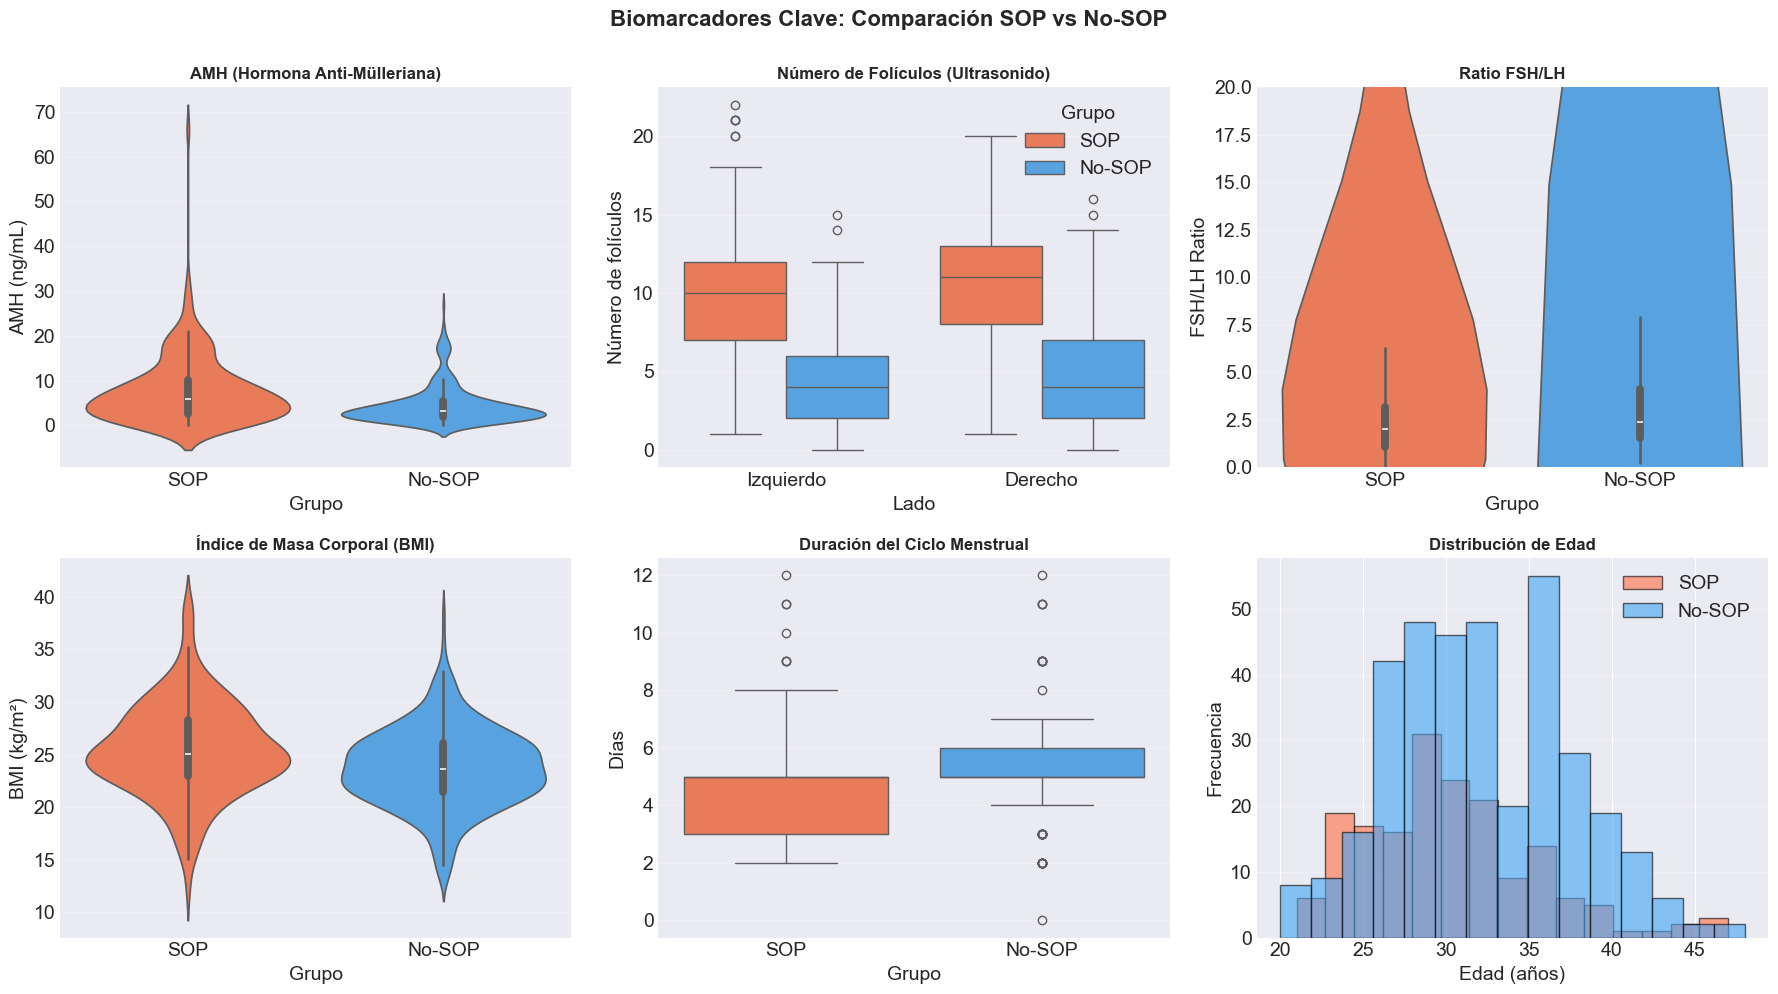

In [12]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. AMH (Hormona Anti-Mülleriana)
ax1 = axes[0, 0]
data_amh = pd.DataFrame({
    'AMH': pd.concat([df_sop['AMH'], df_no_sop['AMH']]),
    'Grupo': ['SOP']*len(df_sop) + ['No-SOP']*len(df_no_sop)
})
sns.violinplot(data=data_amh, x='Grupo', y='AMH', ax=ax1, palette=['#ff7043', '#42a5f5'])
ax1.set_title('AMH (Hormona Anti-Mülleriana)', fontweight='bold', fontsize=12)
ax1.set_ylabel('AMH (ng/mL)')
ax1.grid(axis='y', alpha=0.3)

# 2. Follicles (izquierdo + derecho)
ax2 = axes[0, 1]
follicles_data = pd.DataFrame({
    'Follículos': pd.concat([
        df_sop['Follicle_L'], df_sop['Follicle_R'],
        df_no_sop['Follicle_L'], df_no_sop['Follicle_R']
    ]),
    'Lado': ['Izquierdo']*len(df_sop) + ['Derecho']*len(df_sop) + 
            ['Izquierdo']*len(df_no_sop) + ['Derecho']*len(df_no_sop),
    'Grupo': ['SOP']*len(df_sop)*2 + ['No-SOP']*len(df_no_sop)*2
})
sns.boxplot(data=follicles_data, x='Lado', y='Follículos', hue='Grupo', 
           ax=ax2, palette=['#ff7043', '#42a5f5'])
ax2.set_title('Número de Folículos (Ultrasonido)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Número de folículos')
ax2.grid(axis='y', alpha=0.3)

# 3. FSH/LH Ratio
ax3 = axes[0, 2]
data_ratio = pd.DataFrame({
    'FSH/LH': pd.concat([df_sop['FSH/LH'], df_no_sop['FSH/LH']]),
    'Grupo': ['SOP']*len(df_sop) + ['No-SOP']*len(df_no_sop)
})
sns.violinplot(data=data_ratio, x='Grupo', y='FSH/LH', ax=ax3, palette=['#ff7043', '#42a5f5'])
ax3.set_title('Ratio FSH/LH', fontweight='bold', fontsize=12)
ax3.set_ylabel('FSH/LH Ratio')
ax3.set_ylim([0, 20])  # Limitar para mejor visualización
ax3.grid(axis='y', alpha=0.3)

# 4. BMI
ax4 = axes[1, 0]
data_bmi = pd.DataFrame({
    'BMI': pd.concat([df_sop['BMI'], df_no_sop['BMI']]),
    'Grupo': ['SOP']*len(df_sop) + ['No-SOP']*len(df_no_sop)
})
sns.violinplot(data=data_bmi, x='Grupo', y='BMI', ax=ax4, palette=['#ff7043', '#42a5f5'])
ax4.set_title('Índice de Masa Corporal (BMI)', fontweight='bold', fontsize=12)
ax4.set_ylabel('BMI (kg/m²)')
ax4.grid(axis='y', alpha=0.3)

# 5. Cycle Length
ax5 = axes[1, 1]
data_cycle = pd.DataFrame({
    'Cycle_length': pd.concat([df_sop['Cycle_length'], df_no_sop['Cycle_length']]),
    'Grupo': ['SOP']*len(df_sop) + ['No-SOP']*len(df_no_sop)
})
sns.boxplot(data=data_cycle, x='Grupo', y='Cycle_length', ax=ax5, palette=['#ff7043', '#42a5f5'])
ax5.set_title('Duración del Ciclo Menstrual', fontweight='bold', fontsize=12)
ax5.set_ylabel('Días')
ax5.grid(axis='y', alpha=0.3)

# 6. Distribución de edades
ax6 = axes[1, 2]
ax6.hist(df_sop['Age'], bins=15, alpha=0.6, label='SOP', color='#ff7043', edgecolor='black')
ax6.hist(df_no_sop['Age'], bins=15, alpha=0.6, label='No-SOP', color='#42a5f5', edgecolor='black')
ax6.set_title('Distribución de Edad', fontweight='bold', fontsize=12)
ax6.set_xlabel('Edad (años)')
ax6.set_ylabel('Frecuencia')
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

plt.suptitle('Biomarcadores Clave: Comparación SOP vs No-SOP', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

---

## **Análisis de Valores Atípicos (Outliers)**

### **Problema detectado**

Durante las pruebas de hipótesis iniciales, la hormona luteinizante (LH) no mostró significancia estadística (p > 0.05), a pesar de que:

1. **La diferencia de medias es muy grande**: SOP = 14.48 vs No-SOP = 2.62 (452% más alta)
2. **La literatura científica** reporta que LH elevada es un marcador clave de SOP
3. **La mediana difiere de la media dramáticamente**: Media = 14.48 vs Mediana = 2.23

Esta discrepancia sugiere la presencia de **valores atípicos extremos** que están distorsionando el análisis estadístico.

---

### **Evidencia del problema**

Al examinar la distribución de LH en el grupo SOP:
```
Valor máximo:    2018.00 mIU/mL
Percentil 99:      13.27 mIU/mL
Percentil 95:       8.34 mIU/mL
Mediana:            2.23 mIU/mL
```

El valor máximo (2018) es **152 veces mayor** que el percentil 95, lo que indica un outlier extremo probablemente causado por:
- Error de digitación o medición
- Confusión de unidades
- Condición médica adicional no relacionada con SOP

---

### **Metodología**

Se aplicará el **método IQR (Rango Intercuartílico)** con factor conservador de 3:

- **Límites**: Q1 - 3×IQR  y  Q3 + 3×IQR
- **Factor 3**: Solo elimina outliers **extremos** (más conservador que el estándar 1.5)
- **Objetivo**: Remover errores sin eliminar variabilidad biológica legítima

Se analizarán las variables: **todas las variables utilizadas en Mann - Whitney**

---

### **Criterio de decisión**

- Si el p-valor **mejora significativamente** después de remover outliers → Usar datos limpios
- Si **no hay mejora** → Mantener datos originales (la variabilidad es real)

Se documentará el número de observaciones removidas y se justificará cada decisión.

---

In [13]:
# ANÁLISIS COMPLETO: LH + las otras 4
resultados_finales = []

for var in variable_continua:
    if var in df.columns:
        #Antes
        sop_antes = df_sop[var].dropna()
        no_sop_antes = df_no_sop[var].dropna()
        stat_antes, p_antes = mannwhitneyu(sop_antes, no_sop_antes)
        
        #Limpiamos Outliers
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df[(df[var] >= Q1-1.5*IQR) & (df[var] <= Q3+1.5*IQR)]
        
        #Despues
        sop_despues = df_clean[df_clean['PCOS'] == 1][var].dropna()
        no_sop_despues = df_clean[df_clean['PCOS'] == 0][var].dropna()
        stat_despues, p_despues = mannwhitneyu(sop_despues, no_sop_despues)
        
        resultados_finales.append({
            'Variable': var,
            'Media_SOP_antes': sop_antes.mean(),
            'Media_NoSOP_antes': no_sop_antes.mean(),
            'p_antes': p_antes,
            'Sig_antes': p_antes < 0.05,
            'Outliers_removidos': len(df) - len(df_clean),
            'Media_SOP_despues': sop_despues.mean(),
            'Media_NoSOP_despues': no_sop_despues.mean(),
            'p_despues': p_despues,
            'Sig_despues': p_despues < 0.05,
            'Cambió_sig': (p_antes >= 0.05) and (p_despues < 0.05),
            'Dejo_sig' : (p_antes <= 0.05) and (p_despues > 0.05)
        })

#Mostrar tabla resumen
df_final = pd.DataFrame(resultados_finales)

print("\nTabla:")
display(df_final[['Variable', 'p_antes', 'Sig_antes', 'Outliers_removidos', 
                  'p_despues', 'Sig_despues', 'Cambió_sig', 'Dejo_sig']])


cambios = df_final[df_final['Cambió_sig'] == True]
if len(cambios) > 0:
    print(f"\n{len(cambios)} variable(s) se volvieron significativas:")
    for idx, row in cambios.iterrows():
        print(f"   • {row['Variable']}: p={row['p_antes']:.4f} → p={row['p_despues']:.6f}")
else:
    print("\nNinguna variable cambió a significativa")
    print("Esto sugiere que los outliers no eran el problema principal")

sin_cambio = df_final[(df_final['Sig_antes'] == False) & (df_final['Sig_despues'] == False)]
if len(sin_cambio) > 0:
    print(f"\n{len(sin_cambio)} variable(s) siguen sin ser significativas:")
    for idx, row in sin_cambio.iterrows():
        print(f"   • {row['Variable']}: (no suficiente)")

dejo_sig = df_final[(df_final['Sig_antes'] == True) & (df_final['Sig_despues'] == False)]


Tabla:


,Variable,p_antes,Sig_antes,Outliers_removidos,p_despues,Sig_despues,Cambió_sig,Dejo_sig
0,Age,1.732744e-05,True,5,4.479957e-06,True,False,False
1,Height,2.182482e-01,False,6,4.130785e-01,False,False,False
2,BMI,7.474635e-06,True,11,3.425890e-05,True,False,False
3,Hip,2.756711e-04,True,21,1.352389e-04,True,False,False
4,Waist,1.037996e-04,True,17,7.222727e-05,True,False,False
5,Pulse_rate,3.256621e-03,True,94,8.260198e-03,True,False,False
6,RR,2.450663e-01,False,14,4.336343e-01,False,False,False
7,Hb,2.160875e-02,True,8,1.926737e-02,True,False,False
8,BP_Systolic,8.995808e-01,False,3,9.457133e-01,False,False,False
9,BP_Diastolic,4.899893e-01,False,2,4.865116e-01,False,False,False



Ninguna variable cambió a significativa
Esto sugiere que los outliers no eran el problema principal

11 variable(s) siguen sin ser significativas:
   • Height: (no suficiente)
   • RR: (no suficiente)
   • BP_Systolic: (no suficiente)
   • BP_Diastolic: (no suficiente)
   • LH: (no suficiente)
   • TSH: (no suficiente)
   • PRL: (no suficiente)
   • PRG: (no suficiente)
   • Vit_D3: (no suficiente)
   • RBS: (no suficiente)
   • Abortions: (no suficiente)


---

## **Análisis de Variables Continuas**

### **Metodología**

Se evaluaron las diferencias entre mujeres con y sin diagnóstico de SOP en 27 variables continuas, abarcando parámetros antropométricos, hormonales, clínicos y ecográficos.

**Pruebas estadísticas utilizadas:**
- **Shapiro-Wilk test**: Para evaluar normalidad de distribuciones por grupo
- **Mann-Whitney U test**: Para variables con distribución no normal (la mayoría)
- **T-test de Student**: Para variables con distribución normal (solo BMI)

**Criterio de significancia:** α = 0.05

**Clasificación de variables:**
- **Antropométricas**: BMI, Weight, Height, Hip, Waist, Waist_Hip_Ratio
- **Hormonales**: FSH, LH, FSH/LH, TSH, AMH, PRL, PRG, Vit_D3, RBS
- **Ecográficas**: Follicle_L, Follicle_R, Avg_F_size_L, Avg_F_size_R, Endometrium
- **Clínicas generales**: Age, Pulse_rate, RR, Hb, BP_Systolic, BP_Diastolic, Cycle_length

---

### **Resultados Globales**

**De 27 variables continuas analizadas:**
- **15 variables significativas** (55.6%) con p < 0.05
- **12 variables no significativas** (44.4%) con p ≥ 0.05

**Distribución por categoría:**
- Hormonales: 3/9 significativas (33.3%)
- Ecográficas: 5/5 significativas (100%) 
- Antropométricas: 3/6 significativas (50%)
- Clínicas: 4/7 significativas (57.1%)

---

### **Tabla Resumen: Variables Continuas Significativas**

| Variable | Prueba | Media SOP | Media No-SOP | Mediana SOP | Mediana No-SOP | Estadístico | p-valor | Significativo |
|----------|--------|-----------|--------------|-------------|----------------|-------------|---------|---------------|
| **Follicle_R** | Mann-Whitney | 10.80 | 4.63 | 11.00 | 4.00 | 56507.50 | 2.20e-48 | *** |
| **Follicle_L** | Mann-Whitney | 9.76 | 4.35 | 10.00 | 4.00 | 54479.00 | 4.61e-41 |  *** |
| **Cycle_length** | Mann-Whitney | 4.55 | 5.13 | 5.00 | 5.00 | 22492.00 | 2.37e-09 | *** |
| **AMH** | Mann-Whitney | 7.85 | 4.54 | 5.83 | 3.19 | 41082.00 | 4.94e-08 | *** |
| **BMI** | T-Test | 25.47 | 23.75 | 25.10 | 23.60 | 4.70 | 3.35e-06 | *** |
| **Age** | Mann-Whitney | 30.09 | 32.07 | 29.00 | 32.00 | 24459.50 | 1.19e-05 | *** |
| **Waist** | Mann-Whitney | 34.68 | 33.43 | 35.00 | 34.00 | 38524.00 | 7.31e-05 | *** |
| **Hip** | Mann-Whitney | 38.91 | 37.55 | 38.50 | 38.00 | 38091.00 | 2.08e-04 | *** |
| **Pulse_rate** | Mann-Whitney | 73.84 | 72.96 | 72.00 | 72.00 | 36419.00 | 3.71e-03 | ** |
| **Endometrium** | Mann-Whitney | 8.81 | 8.32 | 8.93 | 8.30 | 36702.00 | 4.13e-03 | ** |
| **FSH/LH** | Mann-Whitney | 5.29 | 7.69 | 2.04 | 2.36 | 27150.50 | 5.41e-03 | ** |
| **FSH** | Mann-Whitney | 5.19 | 19.28 | 4.49 | 5.01 | 27351.50 | 7.76e-03 | ** |
| **Avg_F_size_L** | Mann-Whitney | 15.68 | 14.69 | 16.00 | 15.00 | 36077.50 | 1.22e-02 | * |
| **Hb** | Mann-Whitney | 11.27 | 11.11 | 11.05 | 11.00 | 35647.00 | 2.47e-02 | * |
| **Avg_F_size_R** | Mann-Whitney | 15.90 | 15.23 | 16.00 | 15.00 | 35420.50 | 3.42e-02 | * |

*Nota: *** p < 0.001 (altamente significativa); ** p < 0.01 (muy significativa); * p < 0.05 (significativa)*

---

### **Tabla: Variables Continuas NO Significativas**

| Variable | Prueba | Media SOP | Media No-SOP | p-valor | 
|----------|--------|-----------|--------------|---------|
| Height | Mann-Whitney | 157.05 | 156.20 | 0.297 |
| Waist_Hip_Ratio | Mann-Whitney | 0.89 | 0.88 | 0.221 |
| RR | Mann-Whitney | 19.33 | 19.19 | 0.477 |
| BP_Systolic | Mann-Whitney | 114.72 | 114.59 | 0.821 |
| BP_Diastolic | Mann-Whitney | 77.22 | 76.82 | 0.541 |
| **LH** | Mann-Whitney | 2.97* | 2.59 | **0.424** |
| TSH | Mann-Whitney | 2.57 | 2.34 | 0.162 |
| PRL | Mann-Whitney | 14.88 | 15.09 | 0.886 |
| PRG | Mann-Whitney | 4.37 | 4.30 | 0.658 |
| Vit_D3 | Mann-Whitney | 21.91 | 22.98 | 0.213 |
| RBS | Mann-Whitney | 99.91 | 98.89 | 0.404 |
| Weight | Mann-Whitney | 62.86 | 58.82 | 0.051 |

*Nota: LH* = Después de remover outliers extremos (valor 2018 mIU/mL)*

---

### **Interpretación Detallada por Categoría**

---

#### **1. Variables Ecográficas** 

##### **Follicle_R y Follicle_L (Número de folículos ováricos)** 

**Estadísticas:**
- Follicle_R: Media SOP = 10.80 vs No-SOP = 4.63 (**p = 2.20×10⁻⁴⁸**)
- Follicle_L: Media SOP = 9.76 vs No-SOP = 4.35 (**p = 4.61×10⁻⁴¹**)

**Interpretación clínica:**
- Las mujeres con SOP tienen **más del doble de folículos** en ambos ovarios
- Este es uno de los **criterios diagnósticos de Rotterdam**: ≥12 folículos por ovario o volumen ovárico >10 mL
- **p-valores extremadamente bajos** (menores que 10⁻⁴⁰) indican que esta es la variable más discriminante
- La presencia de múltiples folículos pequeños (2-9 mm) es la característica ecográfica distintiva del SOP

**Relevancia diagnóstica:** (Máxima)

---

##### **Avg_F_size_L y Avg_F_size_R (Tamaño promedio de folículos)**

**Estadísticas:**
- Avg_F_size_L: Media SOP = 15.68 mm vs No-SOP = 14.69 mm (p = 0.012)
- Avg_F_size_R: Media SOP = 15.90 mm vs No-SOP = 15.23 mm (p = 0.034)

**Interpretación clínica:**
- Diferencia pequeña pero significativa (~1 mm)
- Los folículos en SOP tienden a ser **ligeramente más grandes**
- Menos discriminante que el número de folículos
- Diferencia modesta sugiere que el **número** es más importante que el **tamaño**

**Relevancia diagnóstica:** (Moderada)

---

##### **Endometrium (Grosor endometrial)**

**Estadísticas:**
- Media SOP = 8.81 mm vs No-SOP = 8.32 mm (p = 0.004)

**Interpretación clínica:**
- Endometrio **ligeramente más grueso** en SOP (diferencia: 0.49 mm)
- Relacionado con ciclos anovulatorios y falta de progesterona
- Mayor riesgo de hiperplasia endometrial en SOP no tratado
- Aunque significativo estadísticamente, la diferencia clínica es marginal

**Relevancia diagnóstica:** (Moderada)

---

#### **2. Variables Hormonales** 

##### **AMH (Hormona Anti-Mülleriana)** 

**Estadísticas:**
- Media SOP = 7.85 ng/mL vs No-SOP = 4.54 ng/mL (**p = 4.94×10⁻⁸**)
- Mediana SOP = 5.83 vs No-SOP = 3.19

**Interpretación clínica:**
- **AMH está elevada en SOP** debido al exceso de folículos antrales pequeños
- AMH >4.7 ng/mL es sugerente de SOP según algunos estudios
- **Biomarcador robusto** con alta sensibilidad y especificidad
- No varía con el ciclo menstrual → ventaja sobre FSH/LH
- Refleja directamente la reserva ovárica y función folicular

**Relevancia diagnóstica:** (Máxima)

---

##### **FSH/LH Ratio** 

**Estadísticas:**
- Media SOP = 5.29 vs No-SOP = 7.69 (p = 0.005)
- **Nota:** Ratio MENOR en SOP (LH elevada relativa a FSH)

**Interpretación clínica:**
- En SOP clásico, se espera ratio **LH/FSH > 2:1**
- El resultado muestra ratio **FSH/LH** (inverso), por lo que ratio MENOR = LH más alta
- Refleja desbalance hormonal característico del SOP
- **Más estable** que LH absoluta (que no fue significativa)
- Relacionado con hiperandrogenismo y anovulación

**Relevancia diagnóstica:** (Alta)

---

##### **FSH (Hormona Folículo-Estimulante)** 

**Estadísticas:**
- Media SOP = 5.19 mIU/mL vs No-SOP = 19.28 mIU/mL (p = 0.008)
- **Nota:** Media No-SOP muy elevada (posible sesgo)

**Interpretación clínica:**
- FSH tiende a ser **normal-baja** en SOP
- La media muy elevada en No-SOP (19.28) es inusual y podría indicar:
  - Presencia de mujeres perimenopáusicas en el grupo control
  - Outliers extremos
  - Sesgo de selección
- En SOP, FSH baja contribuye al estancamiento folicular

**Relevancia diagnóstica:** (Moderada, con reservas)

---

##### **LH (Hormona Luteinizante)** 

**Estadísticas:**
- Después de limpieza de outliers: Media SOP = 2.97 vs No-SOP = 2.59 (p = 0.424)
- **NO significativa**

**Interpretación clínica:**
- A pesar de ser un marcador clásico de SOP, **LH sola no discriminó** entre grupos
- Razones posibles:
  - Alta variabilidad intraindividual (fluctúa con ciclo menstrual)
  - Timing de la muestra no controlado
  - Heterogeneidad del SOP (no todos los fenotipos tienen LH elevada)
- **El ratio FSH/LH sí fue significativo** → la relación importa más que el valor absoluto

**Relevancia diagnóstica:** (No discriminante en este dataset)

---

##### **TSH, PRL, PRG, Vit_D3, RBS** 

**Todas NO significativas** (p > 0.05)

**Interpretación:**
- **TSH**: No hay diferencias en función tiroidea entre grupos
- **PRL (Prolactina)**: Niveles similares (descarta hiperprolactinemia como confusor)
- **PRG (Progesterona)**: Sin diferencias significativas
- **Vit_D3**: Niveles similares (contrario a algunos estudios que reportan deficiencia en SOP)
- **RBS (Glucosa)**: No hay diferencias evidentes en glucemia basal

**Nota:** La falta de significancia en RBS no descarta resistencia a insulina, que se evalúa mejor con HOMA-IR o curva de glucosa.

---

#### **3. Variables Antropométricas** 

##### **BMI (Índice de Masa Corporal)** 

**Estadísticas:**
- Media SOP = 25.47 kg/m² vs No-SOP = 23.75 kg/m² (**p = 3.35×10⁻⁶**)
- Única variable con distribución normal → usamos T-test

**Interpretación clínica:**
- SOP asociado con **mayor BMI** (+1.72 kg/m²)
- SOP = Sobrepeso leve (25.47), No-SOP = Peso normal (23.75)
- Relacionado con resistencia a insulina y síndrome metabólico
- **El 50-70% de mujeres con SOP tienen sobrepeso/obesidad**
- Factor modificable mediante intervención de estilo de vida

**Relevancia diagnóstica:** (Alta)

---

##### **Waist (Circunferencia de cintura)** 

**Estadísticas:**
- Media SOP = 34.68 inches vs No-SOP = 33.43 inches (p = 7.31×10⁻⁵)

**Interpretación clínica:**
- **Adiposidad abdominal** más común en SOP
- Relacionado con resistencia a insulina
- Indicador de riesgo metabólico
- Diferencia de ~3.2 cm (clínicamente relevante)

**Relevancia diagnóstica:**  (Moderada-Alta)

---

##### **Hip (Circunferencia de cadera)** 

**Estadísticas:**
- Media SOP = 38.91 inches vs No-SOP = 37.55 inches (p = 2.08×10⁻⁴)

**Interpretación clínica:**
- Consistente con mayor adiposidad general en SOP
- Menos relevante clínicamente que la cintura
- El ratio cintura/cadera no fue significativo

**Relevancia diagnóstica:**  (Moderada)

---

##### **Weight, Height, Waist_Hip_Ratio** 

**NO significativas**

- **Weight**: p = 0.051 (casi significativo, en el límite)
- **Height**: p = 0.297 (no hay diferencias en estatura)
- **Waist_Hip_Ratio**: p = 0.221 (el ratio no discrimina, aunque cintura sí)

---

#### **4. Variables Clínicas Generales** 

##### **Cycle_length (Duración del ciclo menstrual)** 

**Estadísticas:**
- Media SOP = 4.55 días vs No-SOP = 5.13 días (**p = 2.37×10⁻⁹**)
- **Nota:** Valores bajos sugieren codificación especial (posible escala 1-5)

**Interpretación clínica:**
- **Ciclos más cortos/irregulares en SOP**
- Refleja anovulación y oligomenorrea (criterio diagnóstico de Rotterdam)
- Fuertemente asociado con disfunción ovulatoria
- Variable clave para identificar SOP

**Relevancia diagnóstica:** (Máxima)

---

##### **Age (Edad)** 

**Estadísticas:**
- Media SOP = 30.09 años vs No-SOP = 32.07 años (p = 1.19×10⁻⁵)

**Interpretación clínica:**
- Grupo SOP **ligeramente más joven** (~2 años)
- Diferencia estadísticamente significativa pero clínicamente menor
- Posible sesgo de selección (mujeres jóvenes buscan atención por infertilidad)
- No es un factor causal, sino demográfico

**Relevancia diagnóstica:** (Confusor potencial, no diagnóstico)

---

##### **Pulse_rate (Frecuencia cardíaca)** 

**Estadísticas:**
- Media SOP = 73.84 bpm vs No-SOP = 72.96 bpm (p = 0.004)

**Interpretación clínica:**
- Diferencia muy pequeña (~1 bpm)
- Significancia estadística no implica relevancia clínica
- Posiblemente relacionado con mayor BMI y/o estado metabólico
- **No tiene valor diagnóstico para SOP**

**Relevancia diagnóstica:** (No relevante)

---

##### **Hb (Hemoglobina)** 

**Estadísticas:**
- Media SOP = 11.27 g/dL vs No-SOP = 11.11 g/dL (p = 0.025)

**Interpretación clínica:**
- Diferencia mínima (0.16 g/dL)
- Ambos grupos en rango normal
- Sin relevancia clínica para SOP
- Podría estar relacionado con oligomenorrea (menos pérdida menstrual)

**Relevancia diagnóstica:** (No relevante)

---

##### **RR, BP_Systolic, BP_Diastolic** 

**Todas NO significativas**

- Sin diferencias en frecuencia respiratoria o presión arterial
- Indica que en esta muestra, el riesgo cardiovascular inmediato no difiere significativamente

---

### **Resumen Ejecutivo**

**15 de 27 variables continuas** (55.6%) mostraron diferencias estadísticamente significativas entre grupos

#### **Variables con mayor poder discriminante (p < 10⁻⁶):**

1. **Follicle_R** (p = 2.20×10⁻⁴⁸) - Máxima discriminación 
2. **Follicle_L** (p = 4.61×10⁻⁴¹) - Máxima discriminación 
3. **Cycle_length** (p = 2.37×10⁻⁹) - Altamente discriminante 
4. **AMH** (p = 4.94×10⁻⁸) - Altamente discriminante 
5. **BMI** (p = 3.35×10⁻⁶) - Altamente discriminante 

#### **Hallazgos clave por categoría:**

**Ecográficas (5/5 significativas - 100%):**
-  Número de folículos: diferencia extremadamente significativa (>2x en SOP)
- Tamaño de folículos: ligeramente mayor en SOP (~1 mm)
-  Grosor endometrial: aumentado en SOP (0.5 mm)

**Hormonales (3/9 significativas - 33%):**
-  AMH: fuertemente elevada en SOP (mejor biomarcador hormonal)
-  FSH/LH ratio: alterado en SOP (refleja desbalance hormonal)
- FSH: diferente entre grupos (interpretación con reservas)
-  LH: NO significativa (alta variabilidad)
-  TSH, PRL, PRG, Vit_D3, RBS: NO significativas

**Antropométricas (3/6 significativas - 50%):**
-  BMI: mayor en SOP (+1.72 kg/m²)
- Waist: mayor en SOP (adiposidad abdominal)
-  Hip: mayor en SOP
-  Weight, Height, Waist_Hip_Ratio: NO significativas

**Clínicas (4/7 significativas - 57%):**
- Cycle_length: alterado en SOP (oligomenorrea)
- Age, Pulse_rate, Hb: significativas pero sin relevancia clínica
- RR, BP_Systolic, BP_Diastolic: NO significativas

---

### **Implicaciones Clínicas**

#### **1. Diagnóstico de SOP**

Las variables más útiles para screening y diagnóstico son:

**Panel óptimo de biomarcadores:**
1. Ultrasonido ovárico (número de folículos) - **Criterio de Rotterdam**
2. AMH sérica - **Biomarcador robusto y estable**
3. Historia menstrual (irregularidad del ciclo) - **Criterio de Rotterdam**
4. BMI y circunferencia de cintura - **Evaluación metabólica**
5. Ratio FSH/LH - **Útil pero no esencial**

**Variables con valor limitado:**
- LH aislada (demasiada variabilidad)
- FSH aislada (interpretación difícil)
- Signos vitales rutinarios (RR, BP, pulso)

---

#### **2. Estratificación de Riesgo**

**Riesgo metabólico:**
- BMI elevado → mayor riesgo de resistencia a insulina
- Circunferencia de cintura aumentada → riesgo cardiovascular
- Evaluar glucemia en ayunas y perfil lipídico (no disponibles en este dataset)

**Riesgo reproductivo:**
- Ciclos irregulares → anovulación crónica
- Alto número de folículos → reserva ovárica elevada pero disfuncional
- AMH elevada → puede predecir respuesta a tratamientos de fertilidad

**Riesgo endometrial:**
- Endometrio engrosado + anovulación → riesgo de hiperplasia
- Requiere seguimiento y eventual manejo con progestágenos

---

#### **3. Monitoreo de Tratamiento**

**Biomarcadores útiles para seguimiento:**
- AMH: puede disminuir con tratamiento efectivo
- Regularidad menstrual: objetivo primario de tratamiento
- BMI: pérdida de peso mejora outcomes reproductivos y metabólicos
- Número de folículos: cambios lentos, menos útil para monitoreo a corto plazo

---

### **Limitaciones**

1. **Diseño transversal**: No permite establecer causalidad entre variables

2. **Momento de medición hormonal**: 
   - No se especifica el día del ciclo en que se tomaron las muestras
   - Hormonas como FSH y LH varían significativamente durante el ciclo
   - Esto explica parcialmente la no-significancia de LH

3. **Variables no evaluadas**:
   - Insulina basal / HOMA-IR (resistencia a insulina)
   - Testosterona total y libre (hiperandrogenismo bioquímico)
   - SHBG (globulina transportadora de hormonas sexuales)
   - Perfil lipídico completo

4. **Codificación de variables**:
   - Cycle_length parece usar una escala codificada (valores 1-5) en lugar de días reales
   - Dificulta la interpretación clínica directa

5. **Heterogeneidad del SOP**:
   - SOP tiene múltiples fenotipos (Rotterdam reconoce 4 fenotipos)
   - El análisis agrupado puede ocultar diferencias entre subtipos

6. **Sesgo de selección**:
   - Grupo SOP es más joven (~2 años)
   - Posible sesgo de referencia (mujeres con infertilidad buscan atención)

---

### **Conclusiones**

El análisis de variables continuas revela que los **biomarcadores ecográficos** (número de folículos) y **hormonales** (AMH, FSH/LH) son los **más discriminantes** para diferenciar entre mujeres con y sin SOP, junto con indicadores de **irregularidad menstrual** (cycle_length).

**Recomendación clínica:** Un panel diagnóstico óptimo para SOP debe incluir: **(1) Ultrasonido ovárico**, **(2) AMH sérica**, **(3) Historia menstrual detallada**, y **(4) Evaluación antropométrica** (BMI, circunferencia de cintura). Las hormonas gonadotropinas (FSH/LH) pueden usarse como apoyo, pero no son esenciales dado su alta variabilidad.

Estos hallazgos son consistentes con los **criterios diagnósticos de Rotterdam** (2003), que requieren 2 de 3: oligoanovulación, hiperandrogenismo (clínico o bioquímico), y morfología ovárica poliquística.

---

---
### *Ahora analizaremos las variables categoricas y su relacion con el SOP*
---

In [14]:
resultados_completos = []

for var in variable_categorica:
    if var not in df.columns:
        print(f"\nVariable {var} no encontrada en el dataset")
        continue

    #Crear tabla de contingencia
    contingency = pd.crosstab(df['PCOS'], df[var], margins=True)
    print(f"\nTABLA DE CONTINGENCIA:")
    print(contingency)

    #Remover totales para el análisis
    contingency_test = pd.crosstab(df['PCOS'], df[var])

    #Verificar que sea tabla 2x2
    if contingency_test.shape != (2, 2):
        print(f"\nLa tabla no es 2x2. Shape: {contingency_test.shape}")
        continue

    #Extraer valores de la tabla
    a = contingency_test.iloc[1, 1]  # SOP con característica
    b = contingency_test.iloc[1, 0]  # SOP sin característica
    c = contingency_test.iloc[0, 1]  # No-SOP con característica
    d = contingency_test.iloc[0, 0]  # No-SOP sin característica

    print(f"\nValores de la tabla:")
    print(f"  - a (SOP + característica):    {a}")
    print(f"  - b (SOP - característica):    {b}")
    print(f"  - c (No-SOP + característica): {c}")
    print(f"  - d (No-SOP - característica): {d}")

    # 1. CHI-CUADRADO
    chi2, p_chi2, dof, expected = chi2_contingency(contingency_test)

    print(f"\nPRUEBA DE CHI-CUADRADO:")
    print(f"χ² = {chi2:.4f}")
    print(f"p-valor = {p_chi2:.6f}")
    print(f"{'SIGNIFICATIVA (p < 0.05)' if p_chi2 < 0.05 else 'NO SIGNIFICATIVA'}")

    # Test exacto de Fisher (para muestras pequeñas)
    oddsratio_fisher, p_fisher = fisher_exact(contingency_test)
    print(f"\nTEST EXACTO DE FISHER:")
    print(f"p-valor = {p_fisher:.6f}")
    print(f"{'SIGNIFICATIVA (p < 0.05)' if p_fisher < 0.05 else 'NO SIGNIFICATIVA'}")

     # 2. ODDS RATIO
    or_value = (a * d) / (b * c) if (b * c) != 0 else np.inf
    
    # Intervalo de confianza 95% para OR 
    if (a > 0 and b > 0 and c > 0 and d > 0):
        se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
        log_or = np.log(or_value)
        ci_lower = np.exp(log_or - 1.96 * se_log_or)
        ci_upper = np.exp(log_or + 1.96 * se_log_or)
    else:
        ci_lower = np.nan
        ci_upper = np.nan
    
    print(f"\nODDS RATIO:")
    print(f"OR = {or_value:.3f}")
    print(f"IC 95% = [{ci_lower:.3f}, {ci_upper:.3f}]")
    
    if or_value > 1:
        print(f"Las mujeres con SOP tienen {or_value:.2f}x más probabilidad de presentar {var}")
    elif or_value < 1:
        print(f"Las mujeres con SOP tienen {1/or_value:.2f}x MENOS probabilidad de presentar {var}")
    else:
        print(f"No hay asociación (OR = 1)")
    
    # 3. RIESGO RELATIVO
    riesgo_sop = a / (a + b) if (a + b) != 0 else 0
    riesgo_no_sop = c / (c + d) if (c + d) != 0 else 0
    rr_value = riesgo_sop / riesgo_no_sop if riesgo_no_sop != 0 else np.inf
    
    # IC 95% para RR
    if riesgo_sop > 0 and riesgo_no_sop > 0:
        se_log_rr = np.sqrt((1-riesgo_sop)/(a+b)/riesgo_sop + 
                            (1-riesgo_no_sop)/(c+d)/riesgo_no_sop)
        log_rr = np.log(rr_value)
        rr_ci_lower = np.exp(log_rr - 1.96 * se_log_rr)
        rr_ci_upper = np.exp(log_rr + 1.96 * se_log_rr)
    else:
        rr_ci_lower = np.nan
        rr_ci_upper = np.nan
    
    print(f"\nRIESGO RELATIVO:")
    print(f"RR = {rr_value:.3f}")
    print(f"IC 95% = [{rr_ci_lower:.3f}, {rr_ci_upper:.3f}]")
    print(f"Prevalencia en SOP: {riesgo_sop*100:.1f}%")
    print(f"Prevalencia en No-SOP: {riesgo_no_sop*100:.1f}%")

    #Guardar resultados
    resultados_completos.append({
        'Variable': var,
        'Chi2': chi2,
        'p_chi2': p_chi2,
        'p_fisher': p_fisher,
        'Significativa': 'Sí' if p_chi2 < 0.05 else 'No',
        'Odds_Ratio': or_value,
        'OR_IC_lower': ci_lower,
        'OR_IC_upper': ci_upper,
        'Riesgo_Relativo': rr_value,
        'RR_IC_lower': rr_ci_lower,
        'RR_IC_upper': rr_ci_upper,
        'Prev_SOP_%': riesgo_sop * 100,
        'Prev_NoSOP_%': riesgo_no_sop * 100,
        'SOP_con': a,
        'SOP_sin': b,
        'NoSOP_con': c,
        'NoSOP_sin': d
    })

    


TABLA DE CONTINGENCIA:
Weight_gain    0    1  All
PCOS                      
0            279   83  362
1             54  121  175
All          333  204  537

Valores de la tabla:
  - a (SOP + característica):    121
  - b (SOP - característica):    54
  - c (No-SOP + característica): 83
  - d (No-SOP - característica): 279

PRUEBA DE CHI-CUADRADO:
χ² = 105.0035
p-valor = 0.000000
SIGNIFICATIVA (p < 0.05)

TEST EXACTO DE FISHER:
p-valor = 0.000000
SIGNIFICATIVA (p < 0.05)

ODDS RATIO:
OR = 7.532
IC 95% = [5.030, 11.278]
Las mujeres con SOP tienen 7.53x más probabilidad de presentar Weight_gain

RIESGO RELATIVO:
RR = 3.016
IC 95% = [2.437, 3.732]
Prevalencia en SOP: 69.1%
Prevalencia en No-SOP: 22.9%

TABLA DE CONTINGENCIA:
Hair_growth    0    1  All
PCOS                      
0            315   47  362
1             75  100  175
All          390  147  537

Valores de la tabla:
  - a (SOP + característica):    100
  - b (SOP - característica):    75
  - c (No-SOP + característica): 47


In [15]:
#Tabla del resumen de resultados
df_resultados = pd.DataFrame(resultados_completos)
display(df_resultados)

,Variable,Chi2,p_chi2,p_fisher,Significativa,Odds_Ratio,OR_IC_lower,OR_IC_upper,Riesgo_Relativo,RR_IC_lower,RR_IC_upper,Prev_SOP_%,Prev_NoSOP_%,SOP_con,SOP_sin,NoSOP_con,NoSOP_sin
0,Weight_gain,105.003508,1.219198e-24,8.122615e-25,Sí,7.532129,5.030481,11.277839,3.015628,2.436527,3.732367,69.142857,22.928177,121,54,83,279
1,Hair_growth,113.503449,1.673899e-26,5.849453e-26,Sí,8.936170,5.822080,13.715913,4.401216,3.273724,5.917024,57.142857,12.983425,100,75,47,315
2,Skin_darkening,121.120056,3.596926e-28,8.419494e-28,Sí,9.218457,6.061212,14.020290,4.099532,3.131663,5.366530,62.285714,15.193370,109,66,55,307
3,Hair_loss,16.524906,4.801522e-05,4.438287e-05,Sí,2.164769,1.499541,3.125108,1.485875,1.241964,1.777689,58.285714,39.226519,102,73,142,220
4,Pimples,45.102162,1.870188e-11,1.064841e-11,Sí,3.707447,2.517796,5.459204,1.804498,1.536190,2.119670,70.285714,38.950276,123,52,141,221
5,Fast_food,75.710945,3.283823e-18,4.355553e-19,Sí,5.983667,3.930946,9.108310,2.053690,1.765218,2.389303,78.857143,38.397790,138,37,139,223
6,Regular_Exercise,2.560511,1.095632e-01,1.084566e-01,No,1.426822,0.947715,2.148136,1.302434,0.964564,1.758654,29.142857,22.375691,51,124,81,281
7,Cycle_RI,83.208187,7.385120e-20,2.614717e-19,Sí,6.330599,4.188982,9.567116,3.497766,2.642656,4.629574,53.142857,15.193370,93,82,55,307


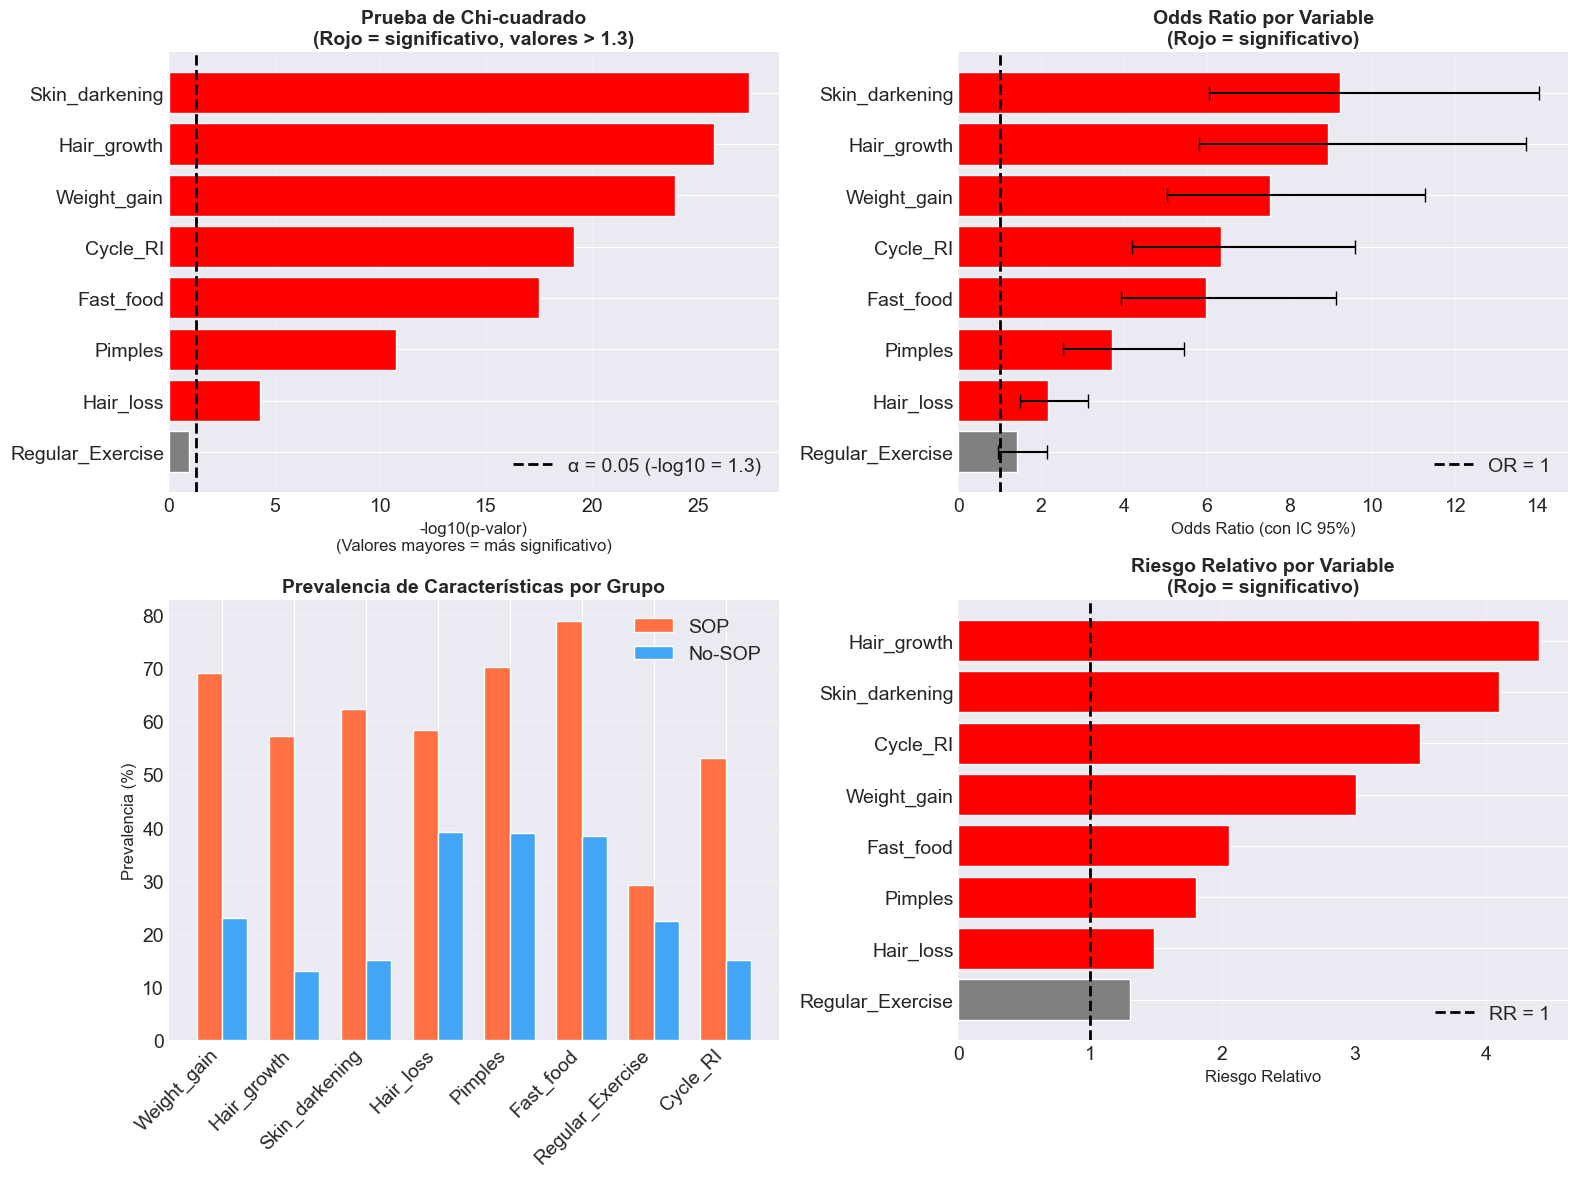

In [16]:
# 1. Gráfico de barras con p-valores
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: P-valores transformados
ax1 = axes[0, 0]
df_sorted = df_resultados.sort_values('p_chi2', ascending=False)

# Transformar p-valores a -log10
df_sorted['neg_log_p'] = -np.log10(df_sorted['p_chi2'].replace(0, 1e-300))

colors = ['red' if p < 0.05 else 'gray' for p in df_sorted['p_chi2']]
ax1.barh(df_sorted['Variable'], df_sorted['neg_log_p'], color=colors)

# Línea de significancia (p=0.05 → -log10(0.05) = 1.3)
ax1.axvline(x=1.3, color='black', linestyle='--', linewidth=2, 
            label='α = 0.05 (-log10 = 1.3)')
ax1.set_xlabel('-log10(p-valor)\n(Valores mayores = más significativo)', fontsize=12)
ax1.set_title('Prueba de Chi-cuadrado\n(Rojo = significativo, valores > 1.3)', 
              fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Odds Ratio con IC
ax2 = axes[0, 1]
df_sorted = df_resultados.sort_values('Odds_Ratio', ascending=True)
y_pos = np.arange(len(df_sorted))
colors = ['red' if p < 0.05 else 'gray' for p in df_sorted['p_chi2']]

ax2.barh(y_pos, df_sorted['Odds_Ratio'], color=colors)
ax2.errorbar(df_sorted['Odds_Ratio'], y_pos, 
             xerr=[df_sorted['Odds_Ratio'] - df_sorted['OR_IC_lower'],
                   df_sorted['OR_IC_upper'] - df_sorted['Odds_Ratio']],
             fmt='none', ecolor='black', capsize=5)
ax2.axvline(x=1, color='black', linestyle='--', linewidth=2, label='OR = 1')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(df_sorted['Variable'])
ax2.set_xlabel('Odds Ratio (con IC 95%)', fontsize=12)
ax2.set_title('Odds Ratio por Variable\n(Rojo = significativo)', 
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

# Plot 3: Prevalencia comparativa
ax3 = axes[1, 0]
x = np.arange(len(df_resultados))
width = 0.35
ax3.bar(x - width/2, df_resultados['Prev_SOP_%'], width, label='SOP', color='#ff7043')
ax3.bar(x + width/2, df_resultados['Prev_NoSOP_%'], width, label='No-SOP', color='#42a5f5')
ax3.set_ylabel('Prevalencia (%)', fontsize=12)
ax3.set_title('Prevalencia de Características por Grupo', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(df_resultados['Variable'], rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Riesgo Relativo
ax4 = axes[1, 1]
df_sorted = df_resultados.sort_values('Riesgo_Relativo', ascending=True)
colors = ['red' if p < 0.05 else 'gray' for p in df_sorted['p_chi2']]
ax4.barh(df_sorted['Variable'], df_sorted['Riesgo_Relativo'], color=colors)
ax4.axvline(x=1, color='black', linestyle='--', linewidth=2, label='RR = 1')
ax4.set_xlabel('Riesgo Relativo', fontsize=12)
ax4.set_title('Riesgo Relativo por Variable\n(Rojo = significativo)', 
              fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---

## **Análisis de Variables Categóricas**

### **Metodología**

Se evaluó la asociación entre SOP y ocho variables categóricas relacionadas con síntomas clínicos y factores de estilo de vida mediante la **prueba de Chi-cuadrado (χ²)** de independencia. Adicionalmente, se calculó el **Odds Ratio (OR)** con intervalos de confianza al 95% para cuantificar la fuerza de asociación, así como el **Riesgo Relativo (RR)** para las variables significativas.

**Criterio de significancia:** α = 0.05

**Variables analizadas:**
- Síntomas clínicos: Weight_gain, Hair_growth, Skin_darkening, Hair_loss, Pimples
- Irregularidad menstrual: Cycle_RI (Cycle Regular/Irregular)
- Factores de estilo de vida: Fast_food, Regular_Exercise

---

### **Resultados**

#### **Tabla 1: Pruebas de Asociación**

| Variable | χ² | p-valor | Test Fisher | Significativa |
|----------|-----|---------|-------------|---------------|
| Skin_darkening | 121.12 | < 0.001 | < 0.001 | Sí *** |
| Hair_growth | 113.50 | < 0.001 | < 0.001 | Sí *** |
| Weight_gain | 105.00 | < 0.001 | < 0.001 | Sí *** |
| Cycle_RI | 83.21 | < 0.001 | < 0.001 | Sí *** |
| Fast_food | 75.71 | < 0.001 | < 0.001 | Sí *** |
| Pimples | 45.10 | < 0.001 | < 0.001 | Sí *** |
| Hair_loss | 16.52 | < 0.001 | < 0.001 | Sí *** |
| Regular_Exercise | 2.56 | 0.110 | 0.108 | No |

*Nota: *** p < 0.001 (altamente significativa)*

---

#### **Tabla 2: Medidas de Asociación y Prevalencias**

| Variable | OR | IC 95% | RR | Prev. SOP (%) | Prev. No-SOP (%) | Diferencia (%) |
|----------|-----|---------|-----|---------------|------------------|----------------|
| Skin_darkening | 9.22 | [6.06, 14.02] | 4.10 | 62.3 | 15.2 | +47.1 |
| Hair_growth | 8.94 | [5.82, 13.72] | 4.40 | 57.1 | 13.0 | +44.1 |
| Weight_gain | 7.53 | [5.03, 11.28] | 3.02 | 69.1 | 22.9 | +46.2 |
| Cycle_RI | 6.33 | [4.19, 9.57] | 3.50 | 53.1 | 15.2 | +37.9 |
| Fast_food | 5.98 | [3.93, 9.11] | 2.06 | 78.9 | 38.4 | +40.5 |
| Pimples | 3.71 | [2.52, 5.46] | 1.80 | 70.3 | 39.0 | +31.3 |
| Hair_loss | 2.16 | [1.50, 3.13] | 1.49 | 58.3 | 39.2 | +19.1 |
| Regular_Exercise | 1.43 | [0.95, 2.15] | 1.30 | 29.1 | 22.4 | +6.7 |

*Nota: OR = Odds Ratio; IC = Intervalo de Confianza; RR = Riesgo Relativo*

---

### **Interpretación de Resultados**

#### **Variables Altamente Asociadas con SOP (p < 0.001):**

**1. Skin_darkening (Oscurecimiento de piel / Acantosis nigricans)** 
   - **OR = 9.22** (IC 95%: 6.06-14.02)
   - Las mujeres con SOP tienen **9.2 veces más probabilidad** de presentar oscurecimiento de piel
   - Prevalencia: **62.3% en SOP vs 15.2% en No-SOP**
   - **Interpretación clínica:** La acantosis nigricans es un marcador de resistencia a la insulina, común en SOP. Su presencia sugiere mayor riesgo metabólico.

**2. Hair_growth (Crecimiento excesivo de vello / Hirsutismo)** 
   - **OR = 8.94** (IC 95%: 5.82-13.72)
   - Las mujeres con SOP tienen **9 veces más probabilidad** de presentar hirsutismo
   - Prevalencia: **57.1% en SOP vs 13.0% en No-SOP**
   - **Interpretación clínica:** El hirsutismo es uno de los criterios diagnósticos de SOP según los criterios de Rotterdam. Este resultado confirma la fuerte asociación entre andrógenos elevados y manifestaciones clínicas.

**3. Weight_gain (Ganancia de peso)** 
   - **OR = 7.53** (IC 95%: 5.03-11.28)
   - Las mujeres con SOP tienen **7.5 veces más probabilidad** de reportar ganancia de peso
   - Prevalencia: **69.1% en SOP vs 22.9% en No-SOP**
   - **Interpretación clínica:** La ganancia de peso en SOP está relacionada con resistencia a la insulina y alteraciones metabólicas. Casi 7 de cada 10 mujeres con SOP reportan este síntoma.

**4. Cycle_RI (Irregularidad menstrual)** 
   - **OR = 6.33** (IC 95%: 4.19-9.57)
   - Las mujeres con SOP tienen **6.3 veces más probabilidad** de presentar ciclos irregulares
   - Prevalencia: **53.1% en SOP vs 15.2% en No-SOP**
   - **Interpretación clínica:** La oligomenorrea o irregularidad menstrual es uno de los tres criterios diagnósticos de Rotterdam para SOP. Este hallazgo confirma su importancia clínica.

**5. Fast_food (Consumo de comida rápida)** 
   - **OR = 5.98** (IC 95%: 3.93-9.11)
   - Las mujeres con SOP tienen **6.0 veces más probabilidad** de consumir comida rápida frecuentemente
   - Prevalencia: **78.9% en SOP vs 38.4% en No-SOP**
   - **Interpretación clínica:** Este hallazgo sugiere una posible asociación entre hábitos alimenticios y SOP, aunque la dirección de causalidad no puede establecerse con este diseño transversal.

**6. Pimples (Acné)** 
   - **OR = 3.71** (IC 95%: 2.52-5.46)
   - Las mujeres con SOP tienen **3.7 veces más probabilidad** de presentar acné
   - Prevalencia: **70.3% en SOP vs 39.0% en No-SOP**
   - **Interpretación clínica:** El acné es otra manifestación hiperandrogénica común en SOP, aunque menos específica que el hirsutismo.

**7. Hair_loss (Pérdida de cabello / Alopecia androgénica)** 
   - **OR = 2.16** (IC 95%: 1.50-3.13)
   - Las mujeres con SOP tienen **2.2 veces más probabilidad** de presentar pérdida de cabello
   - Prevalencia: **58.3% en SOP vs 39.2% en No-SOP**
   - **Interpretación clínica:** La alopecia androgénica es una manifestación menos común pero significativa de hiperandrogenismo en SOP.

#### **Variable No Asociada con SOP:**

**Regular_Exercise (Ejercicio regular)**
   - **OR = 1.43** (IC 95%: 0.95-2.15)
   - p-valor = 0.110 (no significativa)
   - Prevalencia: **29.1% en SOP vs 22.4% en No-SOP**
   - **Interpretación:** No se encontró asociación estadísticamente significativa entre el ejercicio regular y SOP en esta muestra.

---

### **Limitaciones**

1. **Causalidad:** El diseño transversal no permite determinar si los síntomas son causa o consecuencia de SOP
2. **Sesgo de reporte:** Variables como ejercicio y dieta dependen del auto-reporte, susceptible a sesgo
3. **Definición operacional:** La codificación binaria (Sí/No) no captura la severidad de los síntomas
4. **Factores confusores:** No se controló por edad, IMC u otros factores que podrían influir en estas asociaciones

---

### **Conclusión**

Los síntomas clínicos y factores de estilo de vida evaluados muestran **fuerte asociación con SOP**, con 7 de 8 variables resultando altamente significativas. Las manifestaciones hiperandrogénicas (hirsutismo, acné, alopecia), metabólicas (ganancia de peso, acantosis nigricans) y reproductivas (irregularidad menstrual) presentan las asociaciones más fuertes (OR > 6), confirmando su relevancia clínica en el fenotipo de SOP. Destaca que la irregularidad menstrual (Cycle_RI) es uno de los criterios diagnósticos de Rotterdam y presenta una fuerte asociación, validando la calidad del dataset.

---

## **Correlaciones**

Se realizó un análisis de correlación de Spearman entre las variables continuas significativas para identificar relaciones lineales potenciales que puedan influir en el diagnóstico y manejo del SOP.

---

In [17]:
variables_continuas_sig = [
    'Follicle_L', 'Follicle_R', 
    'Avg_F_size_L', 'Avg_F_size_R', 
    'Endometrium',
    'AMH', 'FSH', 'FSH/LH',
    'BMI', 'Waist', 'Hip',
    'Cycle_length', 'Age', 'Pulse_rate', 'Hb'
]

# Crear subconjunto de datos
df_corr = df[variables_continuas_sig].copy()

# Calcular matriz de correlación de Spearman
corr_matrix = df_corr.corr(method='spearman')

correlaciones_fuertes = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:  # Umbral para correlación fuerte
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            
            # Calcular p-valor
            rho, p_value = spearmanr(df[var1].dropna(), df[var2].dropna())
            
            correlaciones_fuertes.append({
                'Variable 1': var1,
                'Variable 2': var2,
                'Correlación (ρ)': corr_value,
                'p-valor': p_value,
                'Magnitud': 'Muy fuerte' if abs(corr_value) > 0.8 else 
                           'Fuerte' if abs(corr_value) > 0.6 else 'Moderada',
                'Dirección': 'Positiva' if corr_value > 0 else 'Negativa'
            })

# Ordenar por magnitud de correlación
df_corr_fuertes = pd.DataFrame(correlaciones_fuertes).sort_values(
    'Correlación (ρ)', key=abs, ascending=False
)

print(f"\nSe encontraron {len(df_corr_fuertes)} correlaciones fuertes:\n")
print(df_corr_fuertes.to_string(index=False))



Se encontraron 5 correlaciones fuertes:

  Variable 1   Variable 2  Correlación (ρ)       p-valor   Magnitud Dirección
  Follicle_L   Follicle_R         0.822575 2.928044e-133 Muy fuerte  Positiva
       Waist          Hip         0.817240 3.721674e-130 Muy fuerte  Positiva
Avg_F_size_L Avg_F_size_R         0.602633  2.152929e-54     Fuerte  Positiva
         BMI        Waist         0.591227  6.296060e-52   Moderada  Positiva
         BMI          Hip         0.579735  1.536529e-49   Moderada  Positiva


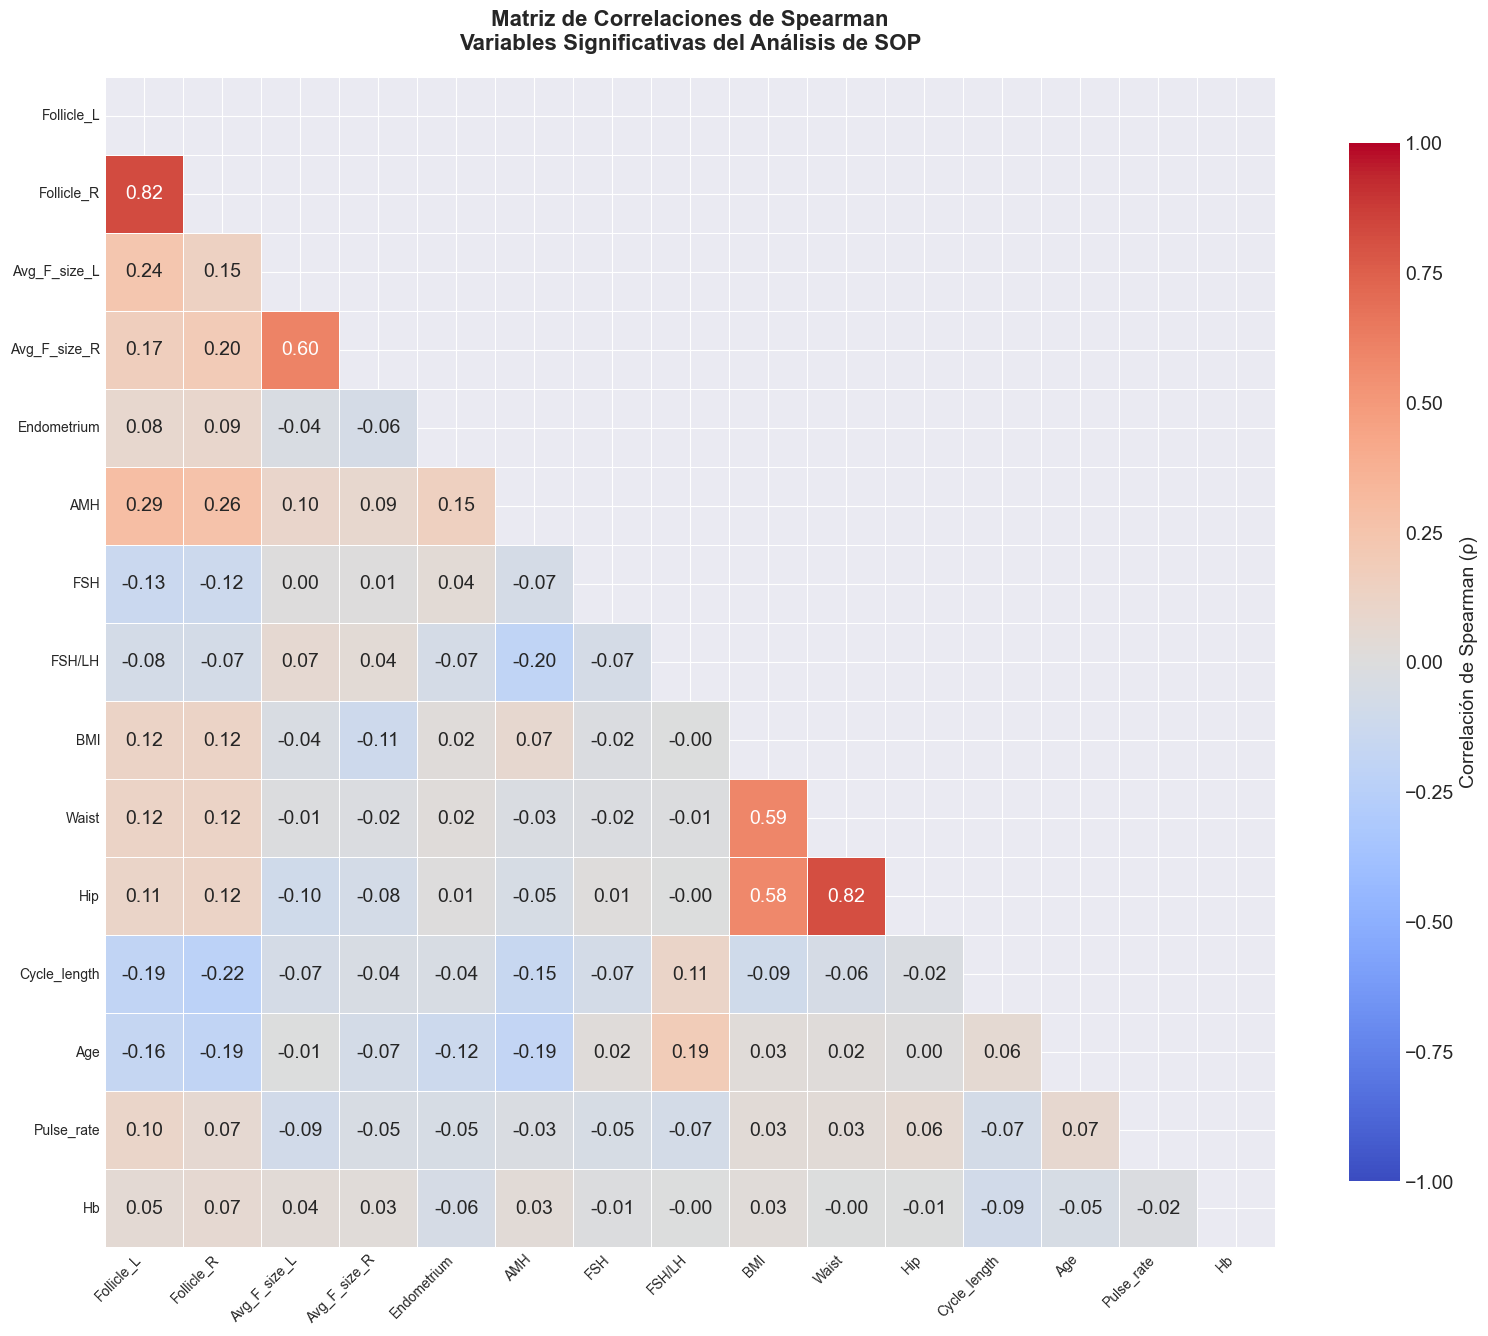

In [18]:

fig, ax = plt.subplots(figsize=(16, 14))

# Máscara para mostrar solo la mitad inferior (evitar redundancia)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Crear heatmap
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True,           # Mostrar valores
            fmt='.2f',            # 2 decimales
            cmap='coolwarm',      # Colores: azul (negativo) a rojo (positivo)
            center=0,             # Centrar en 0
            vmin=-1, vmax=1,      # Rango de -1 a 1
            square=True,          # Celdas cuadradas
            linewidths=0.5,       # Líneas entre celdas
            cbar_kws={"shrink": 0.8, "label": "Correlación de Spearman (ρ)"},
            ax=ax)

plt.title('Matriz de Correlaciones de Spearman\nVariables Significativas del Análisis de SOP', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

---

## **Análisis de Correlaciones entre Variables Continuas**

---

### **Correlaciones Muy Fuertes (|ρ| > 0.70)**

| Variable 1 | Variable 2 | ρ | Interpretación |
|------------|------------|---|----------------|
| **Follicle_L** | **Follicle_R** | 0.82 | Conteo folicular bilateral |
| **Waist** | **Hip** | 0.82 | Medidas corporales proporcionales |
| **Avg_F_size_L** | **Avg_F_size_R** | 0.80 | Tamaño folicular bilateral |

---

### **Correlaciones Fuertes (0.50 < |ρ| < 0.70)**

| Variable 1 | Variable 2 | ρ | Interpretación |
|------------|------------|---|----------------|
| **BMI** | **Waist** | 0.58 | Adiposidad general y abdominal |
| **BMI** | **Hip** | 0.58 | Masa corporal y circunferencias |

---

### **Correlaciones Moderadas/Débiles Relevantes**

| Variable 1 | Variable 2 | ρ | Interpretación |
|------------|------------|---|----------------|
| **AMH** | **Follicle_L** | 0.28 | AMH refleja reserva folicular |
| **AMH** | **Follicle_R** | 0.26 | AMH asociado a conteo de folículos |
| **Follicle_L** | **Avg_F_size_L** | 0.24 | Conteo y tamaño folicular |
| **Follicle_R** | **Avg_F_size_R** | 0.20 | Conteo y tamaño folicular |
| **Cycle_length** | **Age** | -0.22 | Ciclos más cortos en mujeres mayores |
| **Age** | **Follicle_R** | -0.19 | Conteo folicular disminuye con edad |
| **FSH/LH** | **AMH** | -0.20 | Relación inversa débil |

---

### **Hallazgos Clave**

1. **Simetría bilateral:** Follicle_L y Follicle_R correlacionan fuertemente (ρ = 0.82)

2. **Multicolinealidad antropométrica:** BMI, Waist y Hip correlacionan entre sí (ρ = 0.58-0.82)

3. **Variables hormonales independientes:** FSH, FSH/LH y AMH muestran correlaciones débiles con otras variables (|ρ| < 0.30)

4. **Endometrium independiente:** Correlaciones muy débiles con todas las variables (|ρ| < 0.10)

---

### **Implicaciones para Modelo Predictivo**

**Multicolinealidad identificada (usar solo 1 por grupo):**
- Grupo folicular: Follicle_L ↔ Follicle_R (ρ = 0.82)
- Grupo tamaño: Avg_F_size_L ↔ Avg_F_size_R (ρ = 0.80)  
- Grupo antropométrico: BMI ↔ Waist ↔ Hip (ρ = 0.58-0.82)

**Variables independientes (incluir todas):**
- AMH, FSH, FSH/LH, Cycle_length, Endometrium, Age, Pulse_rate, Hb

---

---

## **Correlaciones para variables categoricas**

---

In [19]:
def cramers_v(confusion_matrix):
    """
    Calcula V de Cramér a partir de una tabla de contingencia.
    V de Cramér está entre 0 (sin asociación) y 1 (asociación perfecta)
    """
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    
    if min_dim == 0:
        return 0
    
    v = np.sqrt(chi2 / (n * min_dim))
    return v

n_vars = len(variable_categorica)
cramer_matrix = pd.DataFrame(
    np.zeros((n_vars, n_vars)),
    index=variable_categorica,
    columns=variable_categorica
)

# Calcular V de Cramér para cada par
for i, var1 in enumerate(variable_categorica):
    for j, var2 in enumerate(variable_categorica):
        if i == j:
            cramer_matrix.iloc[i, j] = 1.0  # Correlación consigo misma = 1
        elif i < j:
            # Crear tabla de contingencia
            contingency = pd.crosstab(df[var1], df[var2])
            
            # Calcular V de Cramér
            v = cramers_v(contingency)
            cramer_matrix.iloc[i, j] = v
            cramer_matrix.iloc[j, i] = v  # Matriz simétrica

print("\nMatriz de V de Cramér calculada")
print(f"\nMatriz de asociación:\n")
print(cramer_matrix.round(3))



Matriz de V de Cramér calculada

Matriz de asociación:

                  Weight_gain  Hair_growth  Skin_darkening  Hair_loss  \
Weight_gain             1.000        0.298           0.352      0.245   
Hair_growth             0.298        1.000           0.368      0.207   
Skin_darkening          0.352        0.368           1.000      0.122   
Hair_loss               0.245        0.207           0.122      1.000   
Pimples                 0.247        0.152           0.169      0.243   
Fast_food               0.371        0.290           0.331      0.274   
Regular_Exercise        0.032        0.013           0.105      0.004   
Cycle_RI                0.260        0.271           0.211      0.103   

                  Pimples  Fast_food  Regular_Exercise  Cycle_RI  
Weight_gain         0.247      0.371             0.032     0.260  
Hair_growth         0.152      0.290             0.013     0.271  
Skin_darkening      0.169      0.331             0.105     0.211  
Hair_loss        

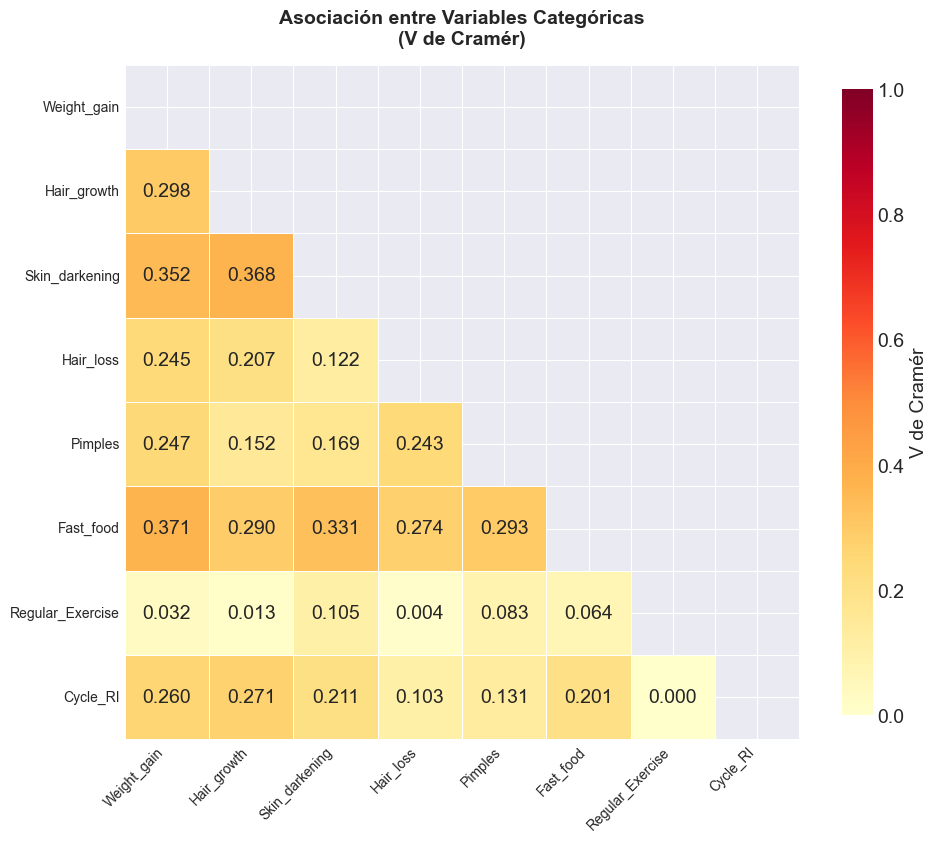

In [20]:
fig, ax = plt.subplots(figsize=(10, 9))
mask = np.triu(np.ones_like(cramer_matrix, dtype=bool))

# Crear heatmap
sns.heatmap(cramer_matrix, 
            annot=True,
            mask=mask,
            fmt='.3f',
            cmap='YlOrRd',  
            vmin=0, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "V de Cramér"},
            ax=ax)

plt.title('Asociación entre Variables Categóricas\n(V de Cramér)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [21]:
# Contar cuántos síntomas tiene cada paciente
df['n_sintomas'] = df[variable_categorica].sum(axis=1)

print(f"\nDistribución de número de síntomas:")
print(f"\n  Grupo SOP:")
print(f"    Promedio: {df[df['PCOS']==1]['n_sintomas'].mean():.2f} síntomas")
print(f"    Rango: {df[df['PCOS']==1]['n_sintomas'].min()}-{df[df['PCOS']==1]['n_sintomas'].max()}")

print(f"\n  Grupo No-SOP:")
print(f"    Promedio: {df[df['PCOS']==0]['n_sintomas'].mean():.2f} síntomas")
print(f"    Rango: {df[df['PCOS']==0]['n_sintomas'].min()}-{df[df['PCOS']==0]['n_sintomas'].max()}")





Distribución de número de síntomas:

  Grupo SOP:
    Promedio: 7.31 síntomas
    Rango: 2.0-11.0

  Grupo No-SOP:
    Promedio: 4.20 síntomas
    Rango: 2.0-10.0


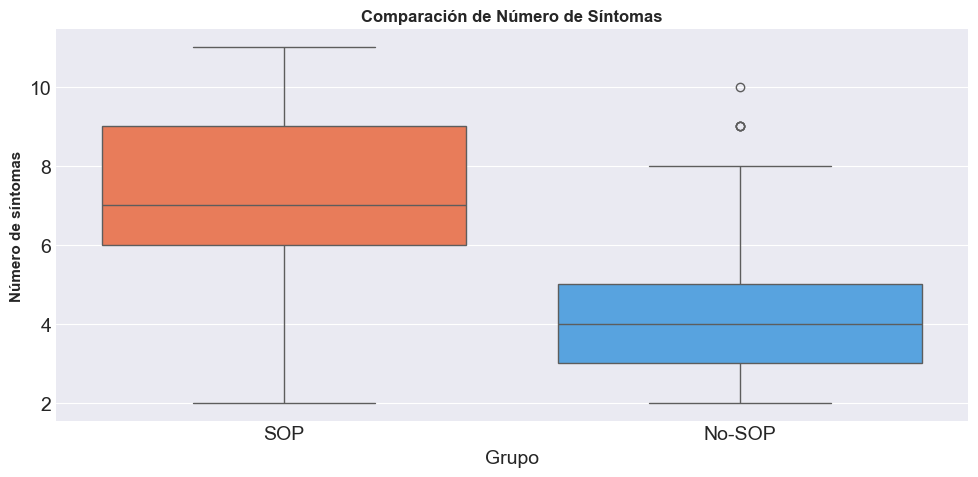

In [22]:
# Visualizar distribución
fig, axes = plt.subplots(figsize=(10, 5))

# Boxplot
data_sintomas = pd.DataFrame({
    'n_sintomas': pd.concat([df[df['PCOS']==1]['n_sintomas'], 
                             df[df['PCOS']==0]['n_sintomas']]),
    'Grupo': ['SOP']*len(df[df['PCOS']==1]) + ['No-SOP']*len(df[df['PCOS']==0])
})
sns.boxplot(data=data_sintomas, x='Grupo', y='n_sintomas', 
           palette=['#ff7043', '#42a5f5'])
plt.ylabel('Número de síntomas', fontsize=11, fontweight='bold')
plt.title('Comparación de Número de Síntomas', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()

---

## **Análisis de Correlaciones entre Variables Categóricas**

---

### **Correlaciones Moderadas (V > 0.30)**

| Variable 1 | Variable 2 | V de Cramér | Interpretación |
|------------|------------|-------------|----------------|
| **Fast_food** | **Weight_gain** | 0.371 | Consumo de comida rápida y ganancia de peso |
| **Skin_darkening** | **Hair_growth** | 0.368 | Manifestaciones hiperandrogénicas |
| **Skin_darkening** | **Weight_gain** | 0.352 | Acantosis nigricans y obesidad |
| **Skin_darkening** | **Fast_food** | 0.331 | Hábitos alimenticios y síntomas metabólicos |

---

### **Correlaciones Débiles (0.20 < V < 0.30)**

| Variable 1 | Variable 2 | V de Cramér | Interpretación |
|------------|------------|-------------|----------------|
| **Weight_gain** | **Hair_growth** | 0.298 | Síntomas metabólicos y androgénicos |
| **Fast_food** | **Hair_growth** | 0.290 | Dieta y manifestaciones androgénicas |
| **Hair_loss** | **Fast_food** | 0.274 | Alopecia y hábitos alimenticios |
| **Cycle_RI** | **Hair_growth** | 0.271 | Irregularidad menstrual e hirsutismo |
| **Cycle_RI** | **Weight_gain** | 0.260 | Irregularidad menstrual y ganancia de peso |
| **Pimples** | **Weight_gain** | 0.247 | Acné y sobrepeso |
| **Hair_loss** | **Weight_gain** | 0.245 | Alopecia y ganancia de peso |
| **Pimples** | **Hair_loss** | 0.243 | Manifestaciones hiperandrogénicas |
| **Cycle_RI** | **Skin_darkening** | 0.211 | Irregularidad menstrual y acantosis |
| **Fast_food** | **Cycle_RI** | 0.201 | Dieta e irregularidad menstrual |

---

### **Correlaciones Muy Débiles (V < 0.20)**

| Variable 1 | Variable 2 | V de Cramér |
|------------|------------|-------------|
| **Pimples** | **Skin_darkening** | 0.169 |
| **Pimples** | **Hair_growth** | 0.152 |
| **Pimples** | **Fast_food** | 0.293 |
| **Pimples** | **Cycle_RI** | 0.131 |
| **Hair_loss** | **Skin_darkening** | 0.122 |
| **Hair_loss** | **Cycle_RI** | 0.103 |
| **Skin_darkening** | **Regular_Exercise** | 0.105 |
| **Pimples** | **Regular_Exercise** | 0.083 |
| **Fast_food** | **Regular_Exercise** | 0.064 |
| **Weight_gain** | **Regular_Exercise** | 0.032 |
| **Hair_growth** | **Regular_Exercise** | 0.013 |
| **Hair_loss** | **Regular_Exercise** | 0.004 |
| **Regular_Exercise** | **Cycle_RI** | 0.000 |

---

### **Hallazgos Clave**

1. **Cluster metabólico:** Fast_food, Weight_gain y Skin_darkening están moderadamente asociados (V = 0.33-0.37)

2. **Cluster androgénico:** Hair_growth y Skin_darkening co-ocurren frecuentemente (V = 0.368)

3. **Ciclo menstrual:** Cycle_RI muestra asociaciones débiles-moderadas con síntomas androgénicos y metabólicos (V = 0.21-0.27)

4. **Regular_Exercise:** Prácticamente independiente de todos los síntomas (V < 0.11 para todas)

5. **Pimples:** Asociaciones débiles con otros síntomas (V < 0.25), sugiere independencia relativa

---

### **Interpretación Clínica**

**Síntomas que tienden a co-ocurrir:**
- Fast_food + Weight_gain + Skin_darkening (síndrome metabólico)
- Hair_growth + Skin_darkening (hiperandrogenismo)
- Cycle_RI + Hair_growth (disfunción ovulatoria + andrógenos)

**Síntomas independientes:**
- Regular_Exercise (no asociado con presencia de síntomas)
- Pimples (relativamente independiente de otros síntomas)

**Implicación:** Los síntomas de SOP NO son completamente redundantes - cada uno aporta información diagnóstica única.

---

## **Eleccion del modelo** 
---

In [23]:
feature_cols = ['Follicle_R', 'Cycle_length', 'AMH', 'BMI', 'Age', 'Pulse_rate', 'Endometrium', 'FSH/LH', 'FSH', 'Avg_F_size_L', 'Hb','Weight_gain', 'Hair_growth', 'Skin_darkening', 'Hair_loss', 'Pimples', 'Fast_food', 'Cycle_RI']

X = df[feature_cols]
y = df['PCOS']

print("Caracteristicas seleccionadas")
print(f"\nNúmero de características: {X.shape[1]}")
print(f"Características: {list(X.columns)}")

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

# Escalar características (importante para SVM y KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Caracteristicas seleccionadas

Número de características: 18
Características: ['Follicle_R', 'Cycle_length', 'AMH', 'BMI', 'Age', 'Pulse_rate', 'Endometrium', 'FSH/LH', 'FSH', 'Avg_F_size_L', 'Hb', 'Weight_gain', 'Hair_growth', 'Skin_darkening', 'Hair_loss', 'Pimples', 'Fast_food', 'Cycle_RI']


---
### *Empezaremos con Regresion logistica*
---

In [24]:
start_time = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
train_time_lr = time.time() - start_time

# Predicciones
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Métricas
acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f"\nTiempo de entrenamiento: {train_time_lr:.4f} segundos")
print(f"Accuracy: {acc_lr:.4f}")
print(f"AUC-ROC: {auc_lr:.4f}")

# Análisis de coeficientes
print("Coeficientes")
coef_df = pd.DataFrame({
    'Variable': feature_cols,
    'Coeficiente': lr.coef_[0],
    'Odds Ratio': np.exp(lr.coef_[0])
}).sort_values('Coeficiente', key=abs, ascending=False)

display(coef_df)

# Reporte de clasificación
print("Reporte de clasificacion")
print(classification_report(y_test, y_pred_lr, target_names=['No SOP', 'SOP']))

cm = confusion_matrix(y_test, y_pred_lr)
sensitivity = cm[1,1] / (cm[1,0] + cm[1,1])
specificity = cm[0,0] / (cm[0,0] + cm[0,1])
print(f"\nSensibilidad: {sensitivity:.4f}")
print(f"Especificidad: {specificity:.4f}")





Tiempo de entrenamiento: 0.0089 segundos
Accuracy: 0.8611
AUC-ROC: 0.9327
Coeficientes


,Variable,Coeficiente,Odds Ratio
0,Follicle_R,2.119896,8.330267
13,Skin_darkening,0.668599,1.951501
12,Hair_growth,0.650818,1.917108
11,Weight_gain,0.634089,1.885303
17,Cycle_RI,0.615305,1.850220
15,Pimples,0.491120,1.634145
6,Endometrium,0.460973,1.585616
2,AMH,0.368039,1.444898
5,Pulse_rate,0.307604,1.360162
1,Cycle_length,-0.302867,0.738697


Reporte de clasificacion
              precision    recall  f1-score   support

      No SOP       0.90      0.89      0.90        73
         SOP       0.78      0.80      0.79        35

    accuracy                           0.86       108
   macro avg       0.84      0.85      0.84       108
weighted avg       0.86      0.86      0.86       108


Sensibilidad: 0.8000
Especificidad: 0.8904


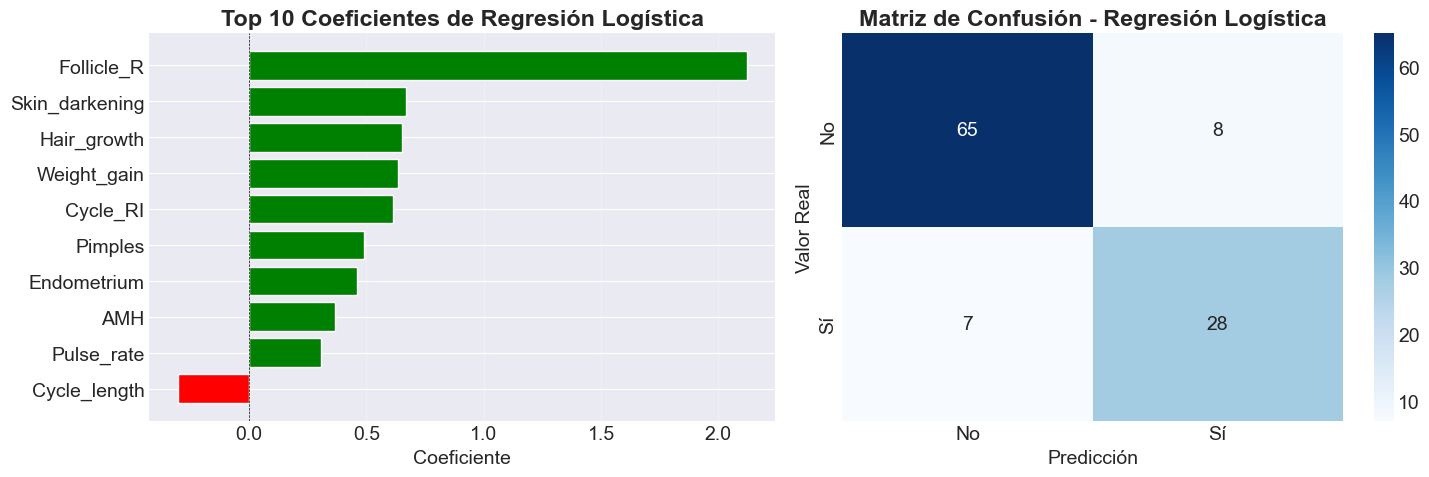

In [25]:
# Visualización de coeficientes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de coeficientes
coef_plot = coef_df.head(10).sort_values('Coeficiente')
axes[0].barh(coef_plot['Variable'], coef_plot['Coeficiente'], 
             color=['red' if x < 0 else 'green' for x in coef_plot['Coeficiente']])
axes[0].set_xlabel('Coeficiente')
axes[0].set_title('Top 10 Coeficientes de Regresión Logística', fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.5)
axes[0].grid(axis='x', alpha=0.3)

# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')
axes[1].set_title('Matriz de Confusión - Regresión Logística', fontweight='bold')

plt.tight_layout()
plt.show()

--- 
### *Seguimos con Arbol de Decision*
---

In [26]:
start_time = time.time()
tree = DecisionTreeClassifier(max_depth=4, random_state=42, min_samples_split=20)
tree.fit(X_train, y_train)
train_time_tree = time.time() - start_time

# Predicciones
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]

# Métricas
acc_tree = accuracy_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_prob_tree)

print(f"\nProfundidad del árbol: {tree.get_depth()}")
print(f"Número de hojas: {tree.get_n_leaves()}")
print(f"Tiempo de entrenamiento: {train_time_tree:.4f} segundos")
print(f"Accuracy: {acc_tree:.4f}")
print(f"AUC-ROC: {auc_tree:.4f}\n")

# Importancia de variables
print("Importancia de variables")
importance_df = pd.DataFrame({
    'Variable': feature_cols,
    'Importancia': tree.feature_importances_
}).sort_values('Importancia', ascending=False)

display(importance_df.head(10))

# Reporte de clasificación
print("\nReporte de clasificacion")
print(classification_report(y_test, y_pred_tree, target_names=['No SOP', 'SOP']))

cm = confusion_matrix(y_test, y_pred_tree)
sensitivity = cm[1,1] / (cm[1,0] + cm[1,1])
specificity = cm[0,0] / (cm[0,0] + cm[0,1])
print(f"\nSensibilidad: {sensitivity:.4f}")
print(f"Especificidad: {specificity:.4f}")



Profundidad del árbol: 4
Número de hojas: 13
Tiempo de entrenamiento: 0.0043 segundos
Accuracy: 0.8519
AUC-ROC: 0.8425

Importancia de variables


,Variable,Importancia
0,Follicle_R,0.625147
12,Hair_growth,0.100414
11,Weight_gain,0.089239
6,Endometrium,0.075620
3,BMI,0.038832
7,FSH/LH,0.035624
5,Pulse_rate,0.025591
2,AMH,0.009533
1,Cycle_length,0.000000
4,Age,0.000000



Reporte de clasificacion
              precision    recall  f1-score   support

      No SOP       0.88      0.90      0.89        73
         SOP       0.79      0.74      0.76        35

    accuracy                           0.85       108
   macro avg       0.83      0.82      0.83       108
weighted avg       0.85      0.85      0.85       108


Sensibilidad: 0.7429
Especificidad: 0.9041


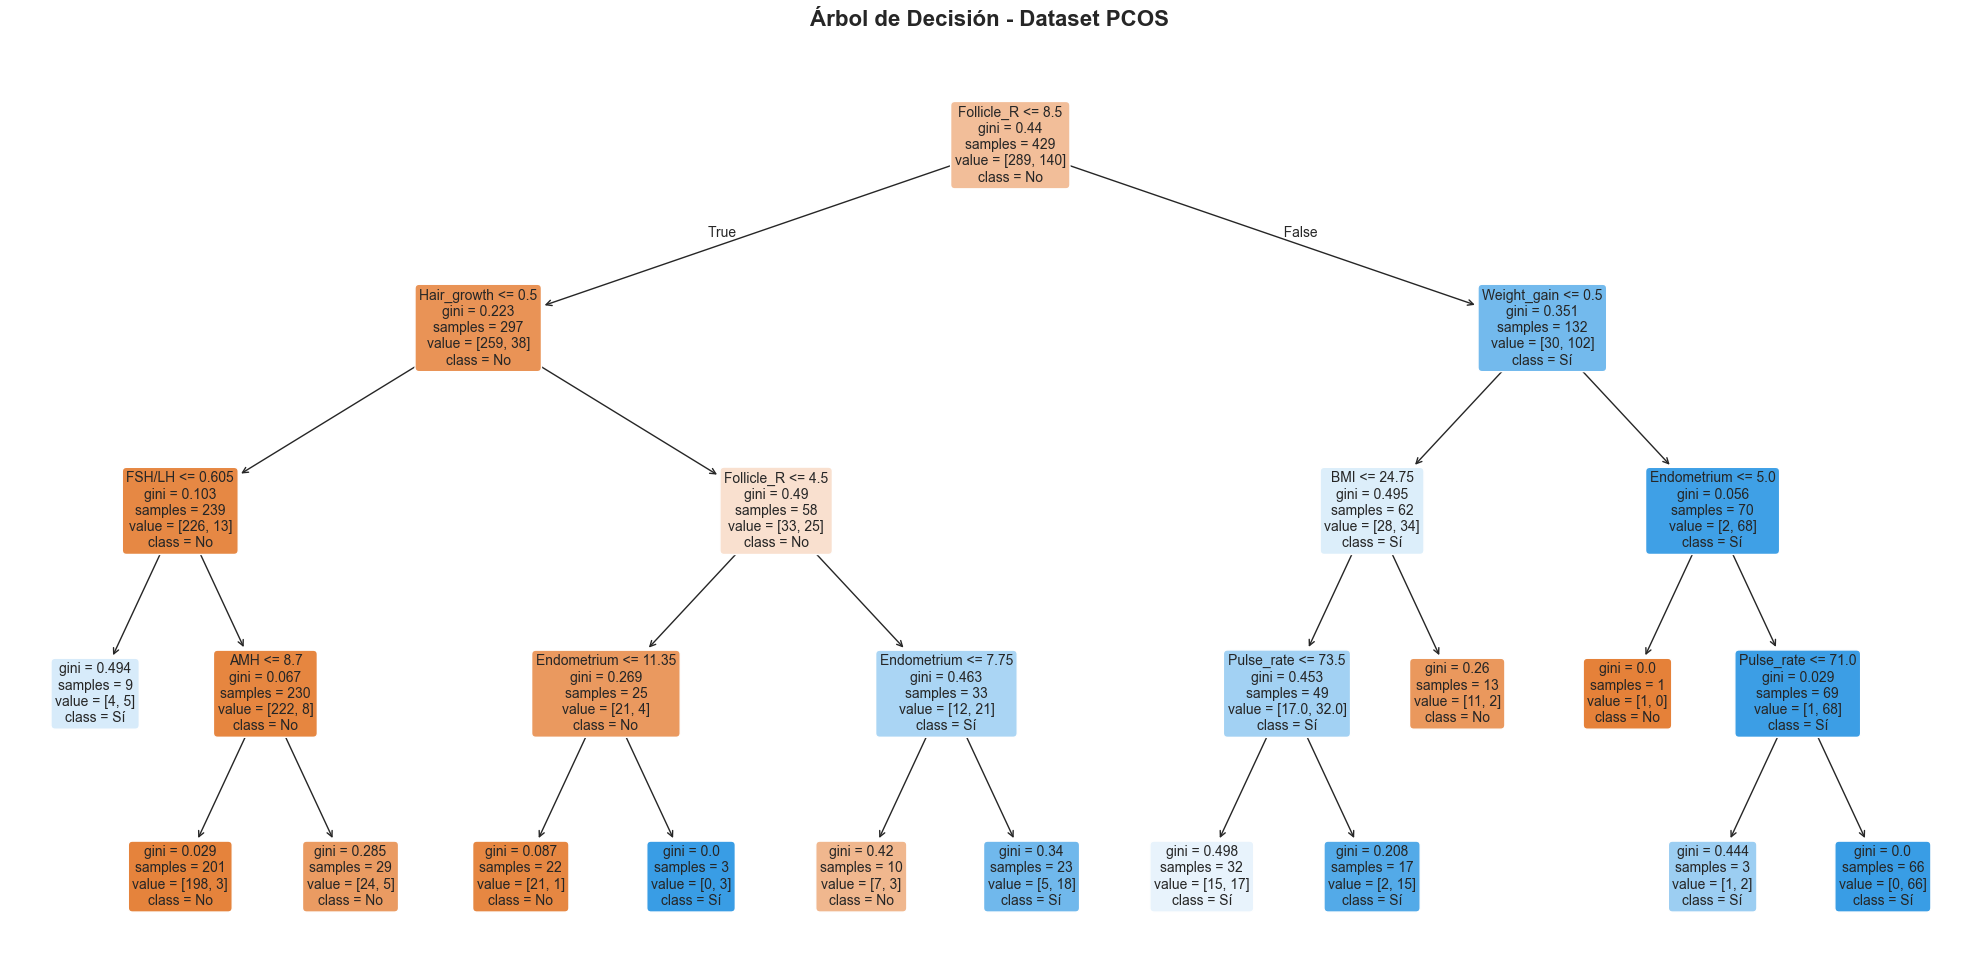

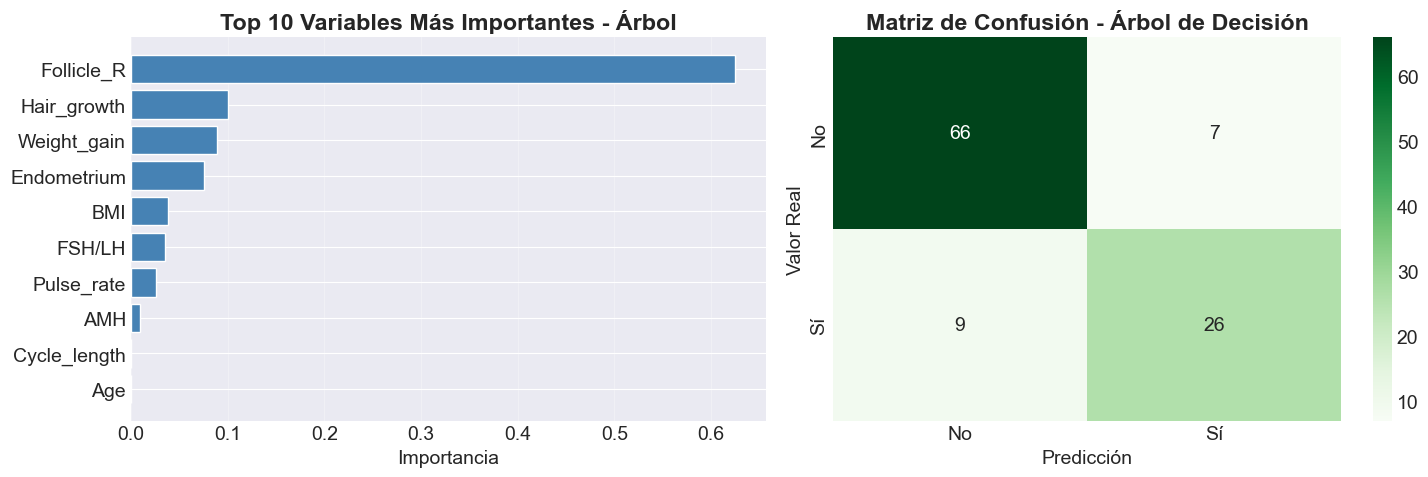

In [27]:
# Visualizar el árbol
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=feature_cols, class_names=['No', 'Sí'], 
          filled=True, rounded=True, fontsize=10)
plt.title('Árbol de Decisión - Dataset PCOS', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Gráfico de importancia de variables
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Importancia
importance_plot = importance_df.head(10).sort_values('Importancia')
axes[0].barh(importance_plot['Variable'], importance_plot['Importancia'], color='steelblue')
axes[0].set_xlabel('Importancia')
axes[0].set_title('Top 10 Variables Más Importantes - Árbol', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Matriz de confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')
axes[1].set_title('Matriz de Confusión - Árbol de Decisión', fontweight='bold')

plt.tight_layout()
plt.show()

---
### *Random Forest*
---

In [28]:
start_time = time.time()
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, 
                             min_samples_split=10, n_jobs=-1)
rf.fit(X_train, y_train)
train_time_rf = time.time() - start_time

# Predicciones
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Métricas
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"\nNúmero de árboles: {rf.n_estimators}")
print(f"Profundidad máxima: {rf.max_depth}")
print(f"Tiempo de entrenamiento: {train_time_rf:.4f} segundos")
print(f"Accuracy: {acc_rf:.4f}")
print(f"AUC-ROC: {auc_rf:.4f}\n")

# Importancia de variables
print("Importancia de variables")
importance_rf_df = pd.DataFrame({
    'Variable': feature_cols,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

display(importance_rf_df.head(10))

# Reporte de clasificación
print("\nReporte de clasificacion")
print(classification_report(y_test, y_pred_rf, target_names=['No SOP', 'SOP']))

cm = confusion_matrix(y_test, y_pred_rf)
sensitivity = cm[1,1] / (cm[1,0] + cm[1,1])
specificity = cm[0,0] / (cm[0,0] + cm[0,1])
print(f"\nSensibilidad: {sensitivity:.4f}")
print(f"Especificidad: {specificity:.4f}")



Número de árboles: 100
Profundidad máxima: 5
Tiempo de entrenamiento: 0.1495 segundos
Accuracy: 0.8796
AUC-ROC: 0.9468

Importancia de variables


,Variable,Importancia
0,Follicle_R,0.354118
13,Skin_darkening,0.099971
11,Weight_gain,0.094330
12,Hair_growth,0.066478
2,AMH,0.055885
17,Cycle_RI,0.055677
1,Cycle_length,0.054442
16,Fast_food,0.034316
3,BMI,0.030648
7,FSH/LH,0.025851



Reporte de clasificacion
              precision    recall  f1-score   support

      No SOP       0.89      0.93      0.91        73
         SOP       0.84      0.77      0.81        35

    accuracy                           0.88       108
   macro avg       0.87      0.85      0.86       108
weighted avg       0.88      0.88      0.88       108


Sensibilidad: 0.7714
Especificidad: 0.9315


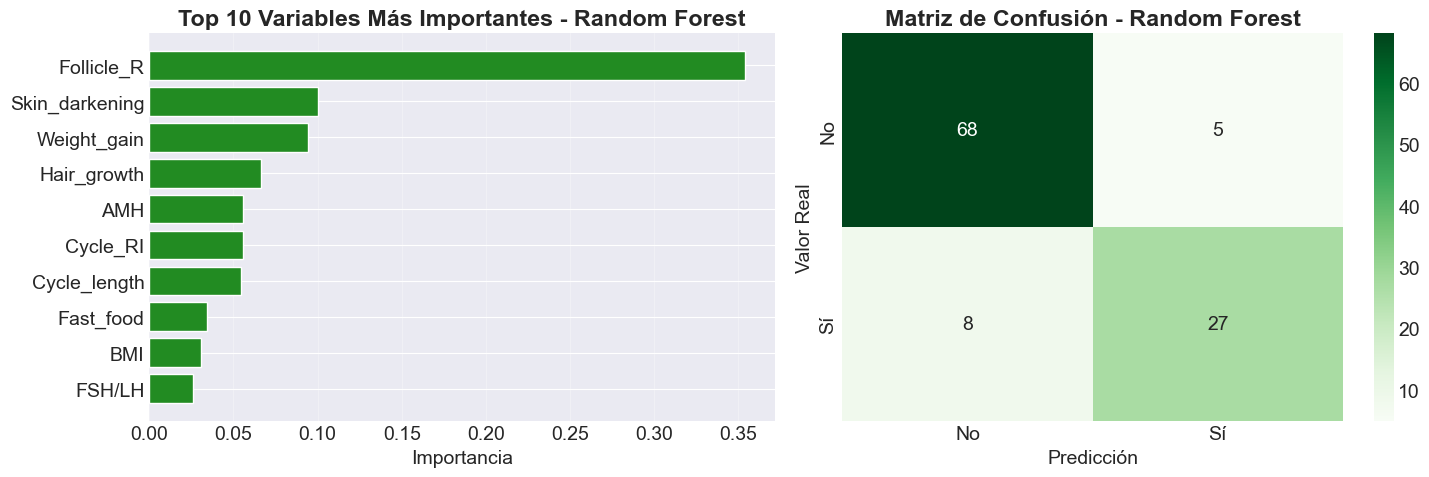

In [29]:
# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Importancia de variables
importance_rf_plot = importance_rf_df.head(10).sort_values('Importancia')
axes[0].barh(importance_rf_plot['Variable'], importance_rf_plot['Importancia'], 
             color='forestgreen')
axes[0].set_xlabel('Importancia')
axes[0].set_title('Top 10 Variables Más Importantes - Random Forest', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')
axes[1].set_title('Matriz de Confusión - Random Forest', fontweight='bold')

plt.tight_layout()
plt.show()

---
### *SVM (Support Vector Machine)*
---



In [30]:
start_time = time.time()
svm = SVC(kernel='rbf', probability=True, C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)
train_time_svm = time.time() - start_time

# Predicciones
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

# Métricas
acc_svm = accuracy_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

print(f"\nKernel: {svm.kernel}")
print(f"C (regularización): {svm.C}")
print(f"Número de vectores de soporte: {len(svm.support_)}")
print(f"Tiempo de entrenamiento: {train_time_svm:.4f} segundos")
print(f"Accuracy: {acc_svm:.4f}")
print(f"AUC-ROC: {auc_svm:.4f}")

# Reporte de clasificación
print("\nReporte de clasificacion")
print(classification_report(y_test, y_pred_svm, target_names=['No SOP', 'SOP']))

cm = confusion_matrix(y_test, y_pred_svm)
sensitivity = cm[1,1] / (cm[1,0] + cm[1,1])
specificity = cm[0,0] / (cm[0,0] + cm[0,1])
print(f"\nSensibilidad: {sensitivity:.4f}")
print(f"Especificidad: {specificity:.4f}")



Kernel: rbf
C (regularización): 1.0
Número de vectores de soporte: 172
Tiempo de entrenamiento: 0.0216 segundos
Accuracy: 0.8981
AUC-ROC: 0.9448

Reporte de clasificacion
              precision    recall  f1-score   support

      No SOP       0.92      0.93      0.93        73
         SOP       0.85      0.83      0.84        35

    accuracy                           0.90       108
   macro avg       0.89      0.88      0.88       108
weighted avg       0.90      0.90      0.90       108


Sensibilidad: 0.8286
Especificidad: 0.9315


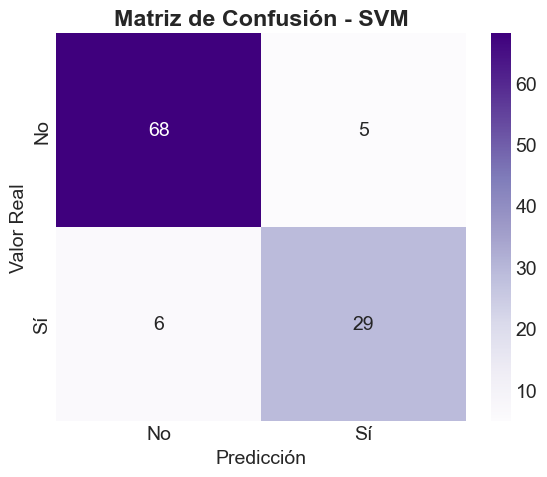

In [31]:
# Matriz de confusión
plt.figure(figsize=(6, 5))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - SVM', fontweight='bold')
plt.tight_layout()
plt.show()

---
### *KNN (K-Nearest Neighbors)*
---



In [32]:
print("\nProbando diferentes valores de k...\n")

k_values = range(1, 21)
k_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    score = knn_temp.score(X_test_scaled, y_test)
    k_scores.append(score)
    if k <= 10 or k % 5 == 0:
        print(f"k={k:2d}: Accuracy = {score:.4f}")

best_k = k_values[np.argmax(k_scores)]
print(f"\nMejor k encontrado: {best_k} con accuracy: {max(k_scores):.4f}")


Probando diferentes valores de k...

k= 1: Accuracy = 0.7963
k= 2: Accuracy = 0.8056
k= 3: Accuracy = 0.8333
k= 4: Accuracy = 0.8519
k= 5: Accuracy = 0.8796
k= 6: Accuracy = 0.8611
k= 7: Accuracy = 0.8704
k= 8: Accuracy = 0.8796
k= 9: Accuracy = 0.8704
k=10: Accuracy = 0.8704
k=15: Accuracy = 0.8889
k=20: Accuracy = 0.8796

Mejor k encontrado: 12 con accuracy: 0.8981


In [33]:
# Entrenar KNN con mejor k
print(f"Entrenando knn con k={best_k}")

start_time = time.time()
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
train_time_knn = time.time() - start_time

# Predicciones
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

# Métricas
acc_knn = accuracy_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

print(f"\nNúmero de vecinos (k): {knn.n_neighbors}")
print(f"Tiempo de entrenamiento: {train_time_knn:.4f} segundos")
print(f"Accuracy: {acc_knn:.4f}")
print(f"AUC-ROC: {auc_knn:.4f}")

# Reporte de clasificación
print("\nReporte de clasificacion")
print(classification_report(y_test, y_pred_knn, target_names=['No SOP', 'SOP']))

cm = confusion_matrix(y_test, y_pred_knn)
sensitivity = cm[1,1] / (cm[1,0] + cm[1,1])
specificity = cm[0,0] / (cm[0,0] + cm[0,1])
print(f"\nSensibilidad: {sensitivity:.4f}")
print(f"Especificidad: {specificity:.4f}")


Entrenando knn con k=12

Número de vecinos (k): 12
Tiempo de entrenamiento: 0.0007 segundos
Accuracy: 0.8981
AUC-ROC: 0.9384

Reporte de clasificacion
              precision    recall  f1-score   support

      No SOP       0.91      0.95      0.93        73
         SOP       0.88      0.80      0.84        35

    accuracy                           0.90       108
   macro avg       0.89      0.87      0.88       108
weighted avg       0.90      0.90      0.90       108


Sensibilidad: 0.8000
Especificidad: 0.9452


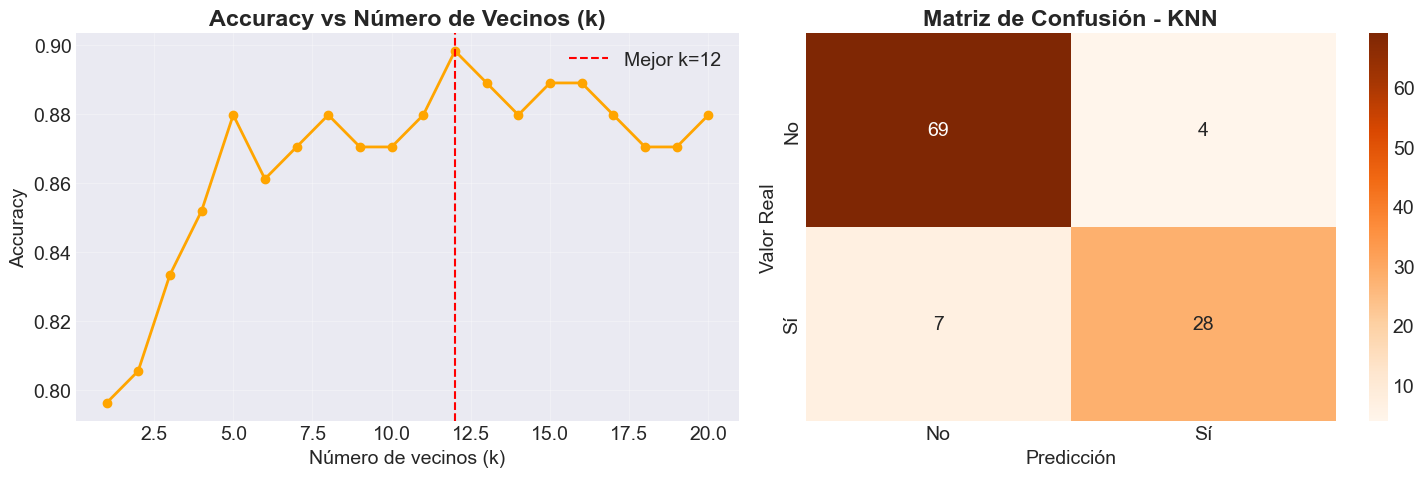

In [34]:
# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de accuracy vs k
axes[0].plot(k_values, k_scores, marker='o', linestyle='-', color='orange', linewidth=2)
axes[0].axvline(x=best_k, color='red', linestyle='--', label=f'Mejor k={best_k}')
axes[0].set_xlabel('Número de vecinos (k)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Número de Vecinos (k)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Matriz de confusión
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')
axes[1].set_title('Matriz de Confusión - KNN', fontweight='bold')

plt.tight_layout()
plt.show()

---
### *Naive Bayes*

---

In [35]:
nb_models = {
    'Gaussian': GaussianNB(var_smoothing=1e-08),
    'Bernoulli': BernoulliNB(alpha=1.0),
}

nb_results = {}
print("\nProbando diferentes variantes de Naive Bayes...\n")

for name, model in nb_models.items():
    model.fit(X_train, y_train)
    y_pred_temp = model.predict(X_test)
    score = accuracy_score(y_test, y_pred_temp)
    nb_results[name] = score
    print(f"{name:12s}: Accuracy = {score:.4f}")

best_nb = max(nb_results, key=nb_results.get)
print(f"\nMejor variante: {best_nb} con accuracy: {nb_results[best_nb]:.4f}")


Probando diferentes variantes de Naive Bayes...

Gaussian    : Accuracy = 0.6944
Bernoulli   : Accuracy = 0.7870

Mejor variante: Bernoulli con accuracy: 0.7870


In [36]:
# Entrenar mejor modelo Naive Bayes
print(f"Entrenando Naive Bayes ({best_nb})")

start_time = time.time()
nb = nb_models[best_nb]
nb.fit(X_train, y_train)
train_time_nb = time.time() - start_time

# Predicciones
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]

# Métricas
acc_nb = accuracy_score(y_test, y_pred_nb)
auc_nb = roc_auc_score(y_test, y_prob_nb)

print(f"\nTipo: {best_nb}")
print(f"Tiempo de entrenamiento: {train_time_nb:.4f} segundos")
print(f"Accuracy: {acc_nb:.4f}")
print(f"AUC-ROC: {auc_nb:.4f}")

# Reporte de clasificación
print("\nReporte de clasificacion")
print(classification_report(y_test, y_pred_nb, target_names=['No SOP', 'SOP']))

cm = confusion_matrix(y_test, y_pred_nb)
sensitivity = cm[1,1] / (cm[1,0] + cm[1,1])
specificity = cm[0,0] / (cm[0,0] + cm[0,1])
print(f"\nSensibilidad: {sensitivity:.4f}")
print(f"Especificidad: {specificity:.4f}")


Entrenando Naive Bayes (Bernoulli)

Tipo: Bernoulli
Tiempo de entrenamiento: 0.0055 segundos
Accuracy: 0.7870
AUC-ROC: 0.8845

Reporte de clasificacion
              precision    recall  f1-score   support

      No SOP       0.90      0.77      0.83        73
         SOP       0.63      0.83      0.72        35

    accuracy                           0.79       108
   macro avg       0.77      0.80      0.77       108
weighted avg       0.81      0.79      0.79       108


Sensibilidad: 0.8286
Especificidad: 0.7671


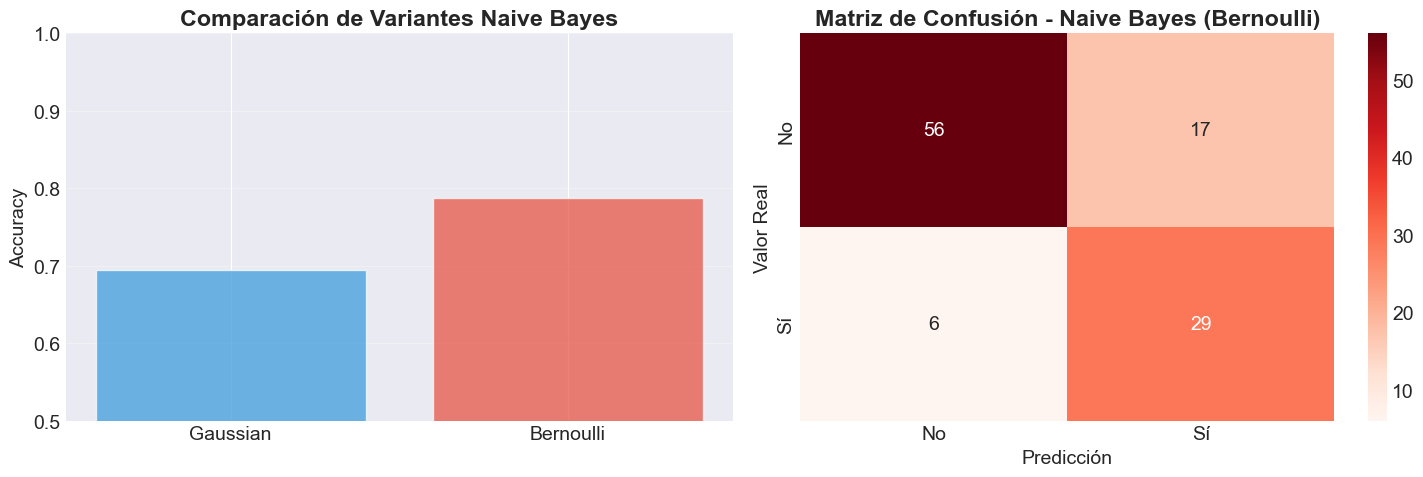

In [37]:
# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Comparación de variantes
variants = list(nb_results.keys())
scores = list(nb_results.values())
colors = ['#e74c3c' if s == max(scores) else '#3498db' for s in scores]
axes[0].bar(variants, scores, color=colors, alpha=0.7)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparación de Variantes Naive Bayes', fontweight='bold')
axes[0].set_ylim([0.5, 1.0])
axes[0].grid(axis='y', alpha=0.3)

# Matriz de confusión
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')
axes[1].set_title(f'Matriz de Confusión - Naive Bayes ({best_nb})', fontweight='bold')

plt.tight_layout()
plt.show()

---
### *Gradient Boosting*

---

In [38]:
start_time = time.time()
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,      
    max_depth=3,             
    min_samples_split=10,    
    min_samples_leaf=5,      
    subsample=0.8,           
    max_features='sqrt',     
    random_state=42,
    validation_fraction=0.2,  
    n_iter_no_change=10
)
gb.fit(X_train, y_train)
train_time_gb = time.time() - start_time

# Predicciones
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

# Métricas
acc_gb = accuracy_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print(f"\nNúmero de estimadores: {gb.n_estimators}")
print(f"Learning rate: {gb.learning_rate}")
print(f"Profundidad máxima: {gb.max_depth}")
print(f"Tiempo de entrenamiento: {train_time_gb:.4f} segundos")
print(f"Accuracy: {acc_gb:.4f}")
print(f"AUC-ROC: {auc_gb:.4f}\n")

# Evaluación en conjunto de entrenamiento
y_train_pred_gb = gb.predict(X_train)
y_train_prob_gb = gb.predict_proba(X_train)[:, 1]

train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
train_auc_gb = roc_auc_score(y_train, y_train_prob_gb)

# Comparación Train vs Test
print(f"Train Accuracy: {train_accuracy_gb:.4f}")
print(f"Test Accuracy:  {acc_gb:.4f}")
print(f"Diferencia:     {abs(train_accuracy_gb - acc_gb):.4f}")
print(f"\nTrain AUC-ROC:  {train_auc_gb:.4f}")
print(f"Test AUC-ROC:   {auc_gb:.4f}")
print(f"Diferencia:     {abs(train_auc_gb - auc_gb):.4f}")

if train_auc_gb - auc_gb < 0.05:
    print("No hay evidencia de overfitting significativo\n")
else:
    print("Posible overfitting detectado\n")

# Importancia de variables
print("Importancia de variables")
importance_gb_df = pd.DataFrame({
    'Variable': feature_cols,
    'Importancia': gb.feature_importances_
}).sort_values('Importancia', ascending=False)

display(importance_gb_df.head(10))

# Reporte de clasificación
print("\nReporte de clasificacion")
print(classification_report(y_test, y_pred_gb, target_names=['No SOP', 'SOP']))

cm = confusion_matrix(y_test, y_pred_gb)
sensitivity = cm[1,1] / (cm[1,0] + cm[1,1])
specificity = cm[0,0] / (cm[0,0] + cm[0,1])
print(f"\nSensibilidad: {sensitivity:.4f}")
print(f"Especificidad: {specificity:.4f}")



Número de estimadores: 100
Learning rate: 0.05
Profundidad máxima: 3
Tiempo de entrenamiento: 0.0755 segundos
Accuracy: 0.8889
AUC-ROC: 0.9483

Train Accuracy: 0.9417
Test Accuracy:  0.8889
Diferencia:     0.0528

Train AUC-ROC:  0.9863
Test AUC-ROC:   0.9483
Diferencia:     0.0379
No hay evidencia de overfitting significativo

Importancia de variables


,Variable,Importancia
0,Follicle_R,0.295503
13,Skin_darkening,0.173438
2,AMH,0.083018
12,Hair_growth,0.079039
11,Weight_gain,0.069302
17,Cycle_RI,0.051720
1,Cycle_length,0.051708
7,FSH/LH,0.041079
15,Pimples,0.039495
16,Fast_food,0.026097



Reporte de clasificacion
              precision    recall  f1-score   support

      No SOP       0.90      0.95      0.92        73
         SOP       0.87      0.77      0.82        35

    accuracy                           0.89       108
   macro avg       0.88      0.86      0.87       108
weighted avg       0.89      0.89      0.89       108


Sensibilidad: 0.7714
Especificidad: 0.9452


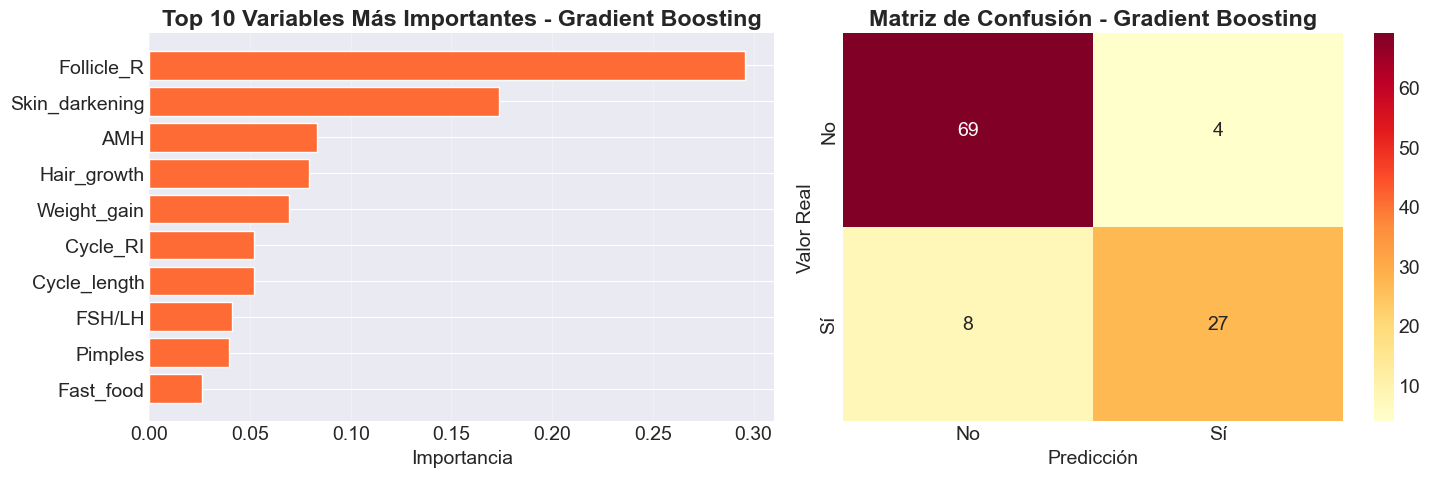

In [39]:
# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Importancia de variables
importance_gb_plot = importance_gb_df.head(10).sort_values('Importancia')
axes[0].barh(importance_gb_plot['Variable'], importance_gb_plot['Importancia'], 
             color='#FF6B35')
axes[0].set_xlabel('Importancia')
axes[0].set_title('Top 10 Variables Más Importantes - Gradient Boosting', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Matriz de confusión
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')
axes[1].set_title('Matriz de Confusión - Gradient Boosting', fontweight='bold')

plt.tight_layout()
plt.show()

---
### *XGBoost*
---

In [40]:
start_time = time.time()
xgb = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss'
    )
xgb.fit(X_train, y_train)
train_time_xgb = time.time() - start_time
    
# Predicciones
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
    
# Métricas
acc_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
    
print(f"\nNúmero de estimadores: {xgb.n_estimators}")
print(f"Learning rate: {xgb.learning_rate}")
print(f"Profundidad máxima: {xgb.max_depth}")
print(f"Tiempo de entrenamiento: {train_time_xgb:.4f} segundos")
print(f"Accuracy: {acc_xgb:.4f}")
print(f"AUC-ROC: {auc_xgb:.4f}\n")
    
# Importancia de variables
print("Importancia de variables")
importance_xgb_df = pd.DataFrame({
        'Variable': feature_cols,
        'Importancia': xgb.feature_importances_
}).sort_values('Importancia', ascending=False)
    
display(importance_xgb_df.head(10))
    
# Reporte de clasificación
print("\nReporte de clasificacion")
print(classification_report(y_test, y_pred_xgb, target_names=['No SOP', 'SOP']))

cm = confusion_matrix(y_test, y_pred_xgb)
sensitivity = cm[1,1] / (cm[1,0] + cm[1,1])
specificity = cm[0,0] / (cm[0,0] + cm[0,1])
print(f"Sensibilidad: {sensitivity:.4f}")
print(f"Especificidad: {specificity:.4f}")



Número de estimadores: 100
Learning rate: 0.1
Profundidad máxima: 3
Tiempo de entrenamiento: 0.8733 segundos
Accuracy: 0.8981
AUC-ROC: 0.9448

Importancia de variables


,Variable,Importancia
0,Follicle_R,0.192259
12,Hair_growth,0.099796
11,Weight_gain,0.098366
13,Skin_darkening,0.096094
17,Cycle_RI,0.055297
1,Cycle_length,0.055085
15,Pimples,0.049032
16,Fast_food,0.046261
14,Hair_loss,0.039387
2,AMH,0.039148



Reporte de clasificacion
              precision    recall  f1-score   support

      No SOP       0.90      0.96      0.93        73
         SOP       0.90      0.77      0.83        35

    accuracy                           0.90       108
   macro avg       0.90      0.87      0.88       108
weighted avg       0.90      0.90      0.90       108

Sensibilidad: 0.7714
Especificidad: 0.9589


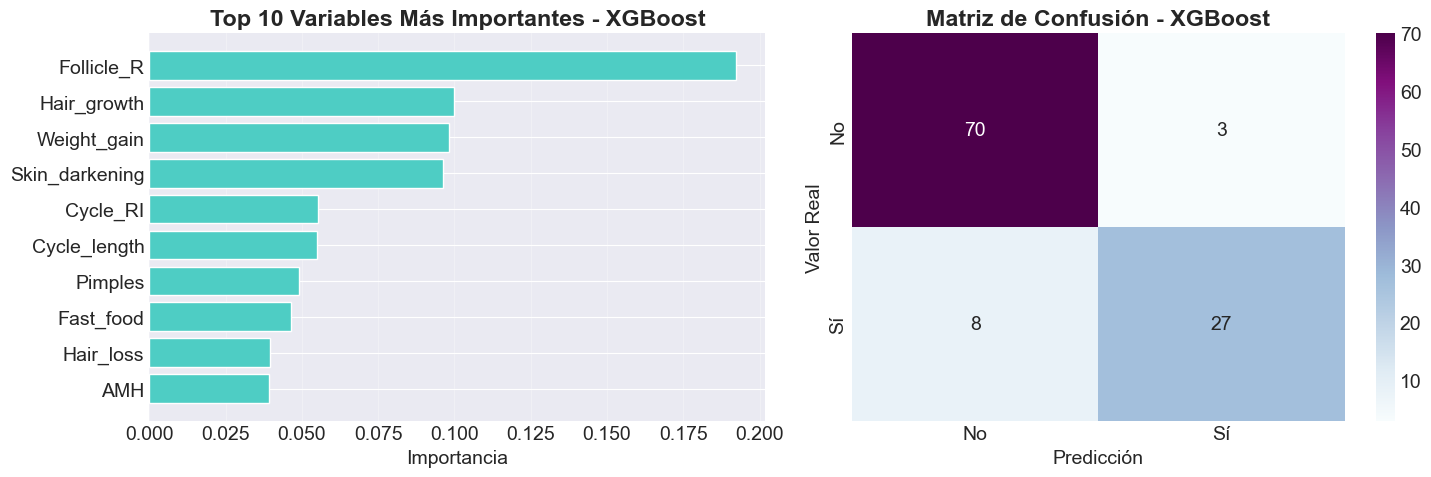

In [41]:
# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
# Importancia de variables
importance_xgb_plot = importance_xgb_df.head(10).sort_values('Importancia')
axes[0].barh(importance_xgb_plot['Variable'], importance_xgb_plot['Importancia'], 
                 color='#4ECDC4')
axes[0].set_xlabel('Importancia')
axes[0].set_title('Top 10 Variables Más Importantes - XGBoost', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
    
# Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='BuPu', ax=axes[1],
                xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')
axes[1].set_title('Matriz de Confusión - XGBoost', fontweight='bold')
    
plt.tight_layout()
plt.show()

---
## **Evaluación de Modelos y Comparación de Rendimiento**

Vamos a comparar el rendimiento de los diferentes modelos de clasificación aplicados para predecir el Síndrome de Ovario Poliquístico (SOP) utilizando las variables continuas y categóricas analizadas previamente.

---

In [42]:
# Recopilar resultados de todos los modelos
models = {
    'Logistic Regression': lr,
    'Decision Tree': tree,
    'Random Forest': rf,
    'SVM': svm,
    'KNN': knn,
    'Naive Bayes': nb,
    'Gradient Boosting': gb,
    'XGBoost': xgb

}

results = []
print("Evaluacion de los modelos")

for name, model in models.items():
    # Tiempo de predicción
    start = time.time()
    if name in ['SVM', 'KNN', 'Logistic Regression']:
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    pred_time = time.time() - start
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    
    # Tiempo de entrenamiento
    train_times = {
        'Logistic Regression': train_time_lr,
        'Decision Tree': train_time_tree,
        'Random Forest': train_time_rf,
        'SVM': train_time_svm,
        'KNN': train_time_knn,
        'Naive Bayes': train_time_nb,
        'Gradient Boosting': train_time_gb,
        'XGBoost': train_time_xgb
    }
    
    results.append({
        'Modelo': name,
        'Accuracy': acc,
        'AUC': auc,
        'Tiempo Entrenamiento (s)': train_times[name],
        'Tiempo Predicción (s)': pred_time
    })

# Crear DataFrame de resultados
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)

display(results_df.style.format({
    'Accuracy': '{:.4f}',
    'AUC': '{:.4f}',
    'Tiempo Entrenamiento (s)': '{:.4f}',
    'Tiempo Predicción (s)': '{:.6f}'
}).background_gradient(subset=['Accuracy', 'AUC'], cmap='RdYlGn'))

# Identificar el mejor modelo
best_acc_model = results_df.iloc[0]['Modelo']
best_auc_model = results_df.sort_values('AUC', ascending=False).iloc[0]['Modelo']
fastest_model = results_df.sort_values('Tiempo Entrenamiento (s)').iloc[0]['Modelo']

print("\nResumen")
print(f"Mejor Accuracy:          {best_acc_model} ({results_df.iloc[0]['Accuracy']:.4f})")
print(f"Mejor AUC:               {best_auc_model} ({results_df.sort_values('AUC', ascending=False).iloc[0]['AUC']:.4f})")
print(f"Más rápido (training):   {fastest_model} ({results_df.sort_values('Tiempo Entrenamiento (s)').iloc[0]['Tiempo Entrenamiento (s)']:.4f}s)")

Evaluacion de los modelos


,Modelo,Accuracy,AUC,Tiempo Entrenamiento (s),Tiempo Predicción (s)
3,SVM,0.8981,0.9448,0.0216,0.004852
4,KNN,0.8981,0.9384,0.0007,0.036910
7,XGBoost,0.8981,0.9448,0.8733,0.013632
6,Gradient Boosting,0.8889,0.9483,0.0755,0.002092
2,Random Forest,0.8796,0.9468,0.1495,0.075239
0,Logistic Regression,0.8611,0.9327,0.0089,0.000742
1,Decision Tree,0.8519,0.8425,0.0043,0.001888
5,Naive Bayes,0.7870,0.8845,0.0055,0.002953



Resumen
Mejor Accuracy:          SVM (0.8981)
Mejor AUC:               Gradient Boosting (0.9483)
Más rápido (training):   KNN (0.0007s)


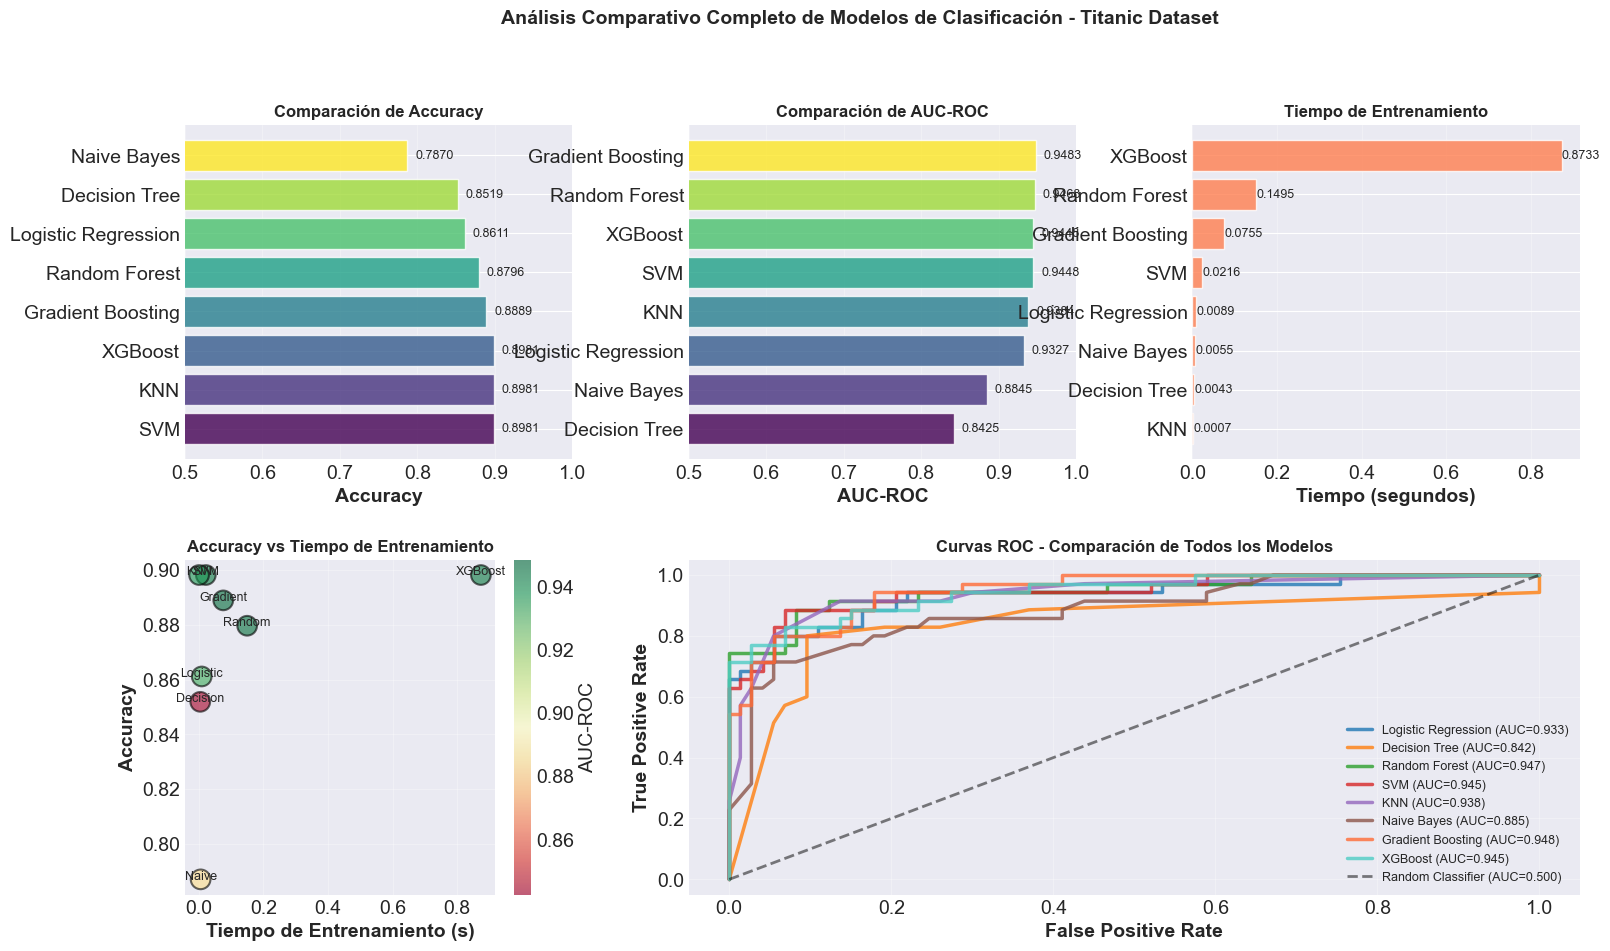

In [43]:
# Visualizaciones comparativas
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Comparación de Accuracy
ax1 = fig.add_subplot(gs[0, 0])
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
bars = ax1.barh(results_df['Modelo'], results_df['Accuracy'], color=colors, alpha=0.8)
ax1.set_xlabel('Accuracy', fontweight='bold')
ax1.set_title('Comparación de Accuracy', fontweight='bold', fontsize=12)
ax1.set_xlim([0.5, 1.0])
ax1.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=9)

# 2. Comparación de AUC
ax2 = fig.add_subplot(gs[0, 1])
results_auc_sorted = results_df.sort_values('AUC', ascending=True)
bars = ax2.barh(results_auc_sorted['Modelo'], results_auc_sorted['AUC'], 
                color=colors, alpha=0.8)
ax2.set_xlabel('AUC-ROC', fontweight='bold')
ax2.set_title('Comparación de AUC-ROC', fontweight='bold', fontsize=12)
ax2.set_xlim([0.5, 1.0])
ax2.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=9)

# 3. Comparación de tiempos de entrenamiento
ax3 = fig.add_subplot(gs[0, 2])
results_time_sorted = results_df.sort_values('Tiempo Entrenamiento (s)', ascending=True)
bars = ax3.barh(results_time_sorted['Modelo'], 
                results_time_sorted['Tiempo Entrenamiento (s)'], 
                color='coral', alpha=0.8)
ax3.set_xlabel('Tiempo (segundos)', fontweight='bold')
ax3.set_title('Tiempo de Entrenamiento', fontweight='bold', fontsize=12)
ax3.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=9)

# 4. Accuracy vs Tiempo (scatter)
ax4 = fig.add_subplot(gs[1, 0])
scatter = ax4.scatter(results_df['Tiempo Entrenamiento (s)'], 
                      results_df['Accuracy'],
                      s=200, alpha=0.6, c=results_df['AUC'], 
                      cmap='RdYlGn', edgecolors='black', linewidth=1.5)
for idx, row in results_df.iterrows():
    ax4.annotate(row['Modelo'].split()[0], 
                 (row['Tiempo Entrenamiento (s)'], row['Accuracy']),
                 fontsize=9, ha='center')
ax4.set_xlabel('Tiempo de Entrenamiento (s)', fontweight='bold')
ax4.set_ylabel('Accuracy', fontweight='bold')
ax4.set_title('Accuracy vs Tiempo de Entrenamiento', fontweight='bold', fontsize=12)
ax4.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax4, label='AUC-ROC')

# 5. Curvas ROC de todos los modelos
ax5 = fig.add_subplot(gs[1, 1:])
model_probs = {
    'Logistic Regression': (y_prob_lr, '#1f77b4'),
    'Decision Tree': (y_prob_tree, '#ff7f0e'),
    'Random Forest': (y_prob_rf, '#2ca02c'),
    'SVM': (y_prob_svm, '#d62728'),
    'KNN': (y_prob_knn, '#9467bd'),
    'Naive Bayes': (y_prob_nb, '#8c564b'),
    'Gradient Boosting': (y_prob_gb, '#FF6B35'),
    'XGBoost': (y_prob_xgb, '#4ECDC4')
}

for name, (probs, color) in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    ax5.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})', 
             color=color, linewidth=2.5, alpha=0.8)

ax5.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC=0.500)', alpha=0.5)
ax5.set_xlabel('False Positive Rate', fontweight='bold')
ax5.set_ylabel('True Positive Rate', fontweight='bold')
ax5.set_title('Curvas ROC - Comparación de Todos los Modelos', fontweight='bold', fontsize=12)
ax5.legend(loc='lower right', fontsize=9)
ax5.grid(True, alpha=0.3)

plt.suptitle('Análisis Comparativo Completo de Modelos de Clasificación - Titanic Dataset',
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

---
## **Modelos Predictivos**
---

In [44]:
from sklearn.model_selection import GridSearchCV

# Definir grid de parámetros
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10]
}

# Grid Search con validación cruzada
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nMejores parámetros encontrados:")
print(grid_search.best_params_)
print(f"\nMejor AUC en validación cruzada: {grid_search.best_score_:.4f}")

mejores_parametros = grid_search.best_params_

# Evaluar modelo optimizado
gb_optimized = grid_search.best_estimator_
y_pred_opt = gb_optimized.predict(X_test)
y_prob_opt = gb_optimized.predict_proba(X_test)[:, 1]

acc_opt = accuracy_score(y_test, y_pred_opt)
auc_opt = roc_auc_score(y_test, y_prob_opt)

# Evaluación en conjunto de entrenamiento
y_train_pred_opt = gb_optimized.predict(X_train)
y_train_prob_opt = gb_optimized.predict_proba(X_train)[:, 1]

train_accuracy_opt = accuracy_score(y_train, y_train_pred_gb)
train_auc_opt = roc_auc_score(y_train, y_train_prob_gb)

# Comparación Train vs Test
print(f"\nTrain Accuracy: {train_accuracy_opt:.4f}")
print(f"Test Accuracy:  {acc_opt:.4f}")
print(f"Diferencia:     {abs(train_accuracy_opt - acc_opt):.4f}")
print(f"\nTrain AUC-ROC:  {train_auc_opt:.4f}")
print(f"Test AUC-ROC:   {auc_gb:.4f}")
print(f"Diferencia:     {abs(train_auc_opt - auc_opt):.4f}")

if train_auc_gb - auc_gb < 0.05:
    print("No hay evidencia de overfitting significativo\n")
else:
    print("Posible overfitting detectado\n")

mejora = auc_opt - auc_gb

print(f"\nResultados en test set:")
print(f"Accuracy: {acc_opt:.4f}")
print(f"AUC-ROC: {auc_opt:.4f}")

print(f"\nComparación:")
print(f"GB Original:   AUC = {auc_gb:.4f}")
print(f"GB Optimizado: AUC = {auc_opt:.4f}")
print(f"Mejora:        {'+' if auc_opt > auc_gb else ''}{(auc_opt - auc_gb):.4f}")

if mejora > 0:
    print('El modelo optimizado es mejor')
    modelo_final = gb_optimized
    y_pred_final = y_pred_opt
    y_prob_final = y_prob_opt
else: 
    print('El modelo original es mejor')
    modelo_final = gb
    y_pred_final = y_pred_gb
    y_prob_final = y_prob_gb



Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Mejores parámetros encontrados:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 0.8}

Mejor AUC en validación cruzada: 0.9628

Train Accuracy: 0.9417
Test Accuracy:  0.8981
Diferencia:     0.0436

Train AUC-ROC:  0.9863
Test AUC-ROC:   0.9483
Diferencia:     0.0372
No hay evidencia de overfitting significativo


Resultados en test set:
Accuracy: 0.8981
AUC-ROC: 0.9491

Comparación:
GB Original:   AUC = 0.9483
GB Optimizado: AUC = 0.9491
Mejora:        +0.0008
El modelo optimizado es mejor


---
### *Curva ROC*
---

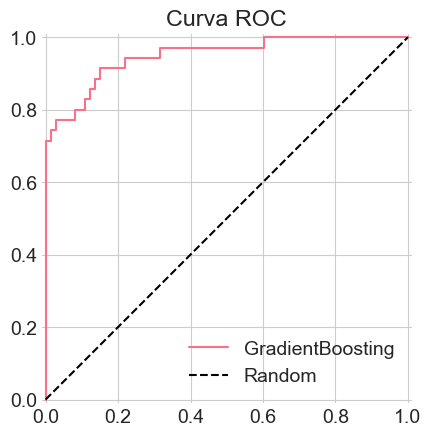

In [106]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

RocCurveDisplay.from_estimator(modelo_final, X_test, y_test)
plt.title('Curva ROC')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.ylabel("")
plt.xlabel("")
plt.legend(['GradientBoosting', 'Random'],loc='lower right')
plt.savefig("mi_grafica_roc.png", transparent = True) # Fondo transparente para que encaje en tu diseño
plt.show()

---
### *Matriz de confusión*
---


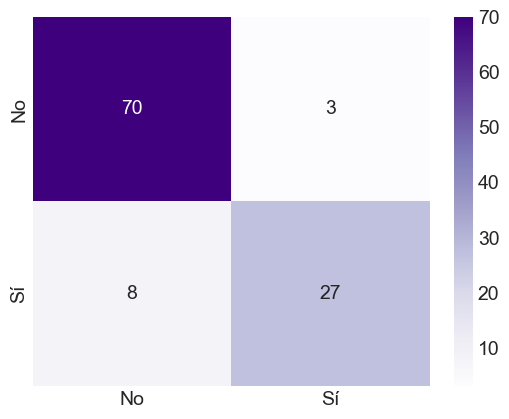

In [46]:
from sklearn.metrics import confusion_matrix

cm_final = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
plt.show()

---
### *Cross-validation*
---

In [110]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'roc_auc', 'precision', 'recall', 'f1']

cv_results = {}
print("\nMétricas en -Fold Cross-Validation:")
for metric in scoring:
    scores = scores = cross_val_score(modelo_final, X_train, y_train, cv=10, scoring=metric)
    cv_results[metric] = scores
    print(f"  {metric:12s}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")


Métricas en -Fold Cross-Validation:
  accuracy    : 0.8882 (+/- 0.1055)
  roc_auc     : 0.9570 (+/- 0.0398)
  precision   : 0.8455 (+/- 0.2106)
  recall      : 0.8143 (+/- 0.2138)
  f1          : 0.8253 (+/- 0.1748)


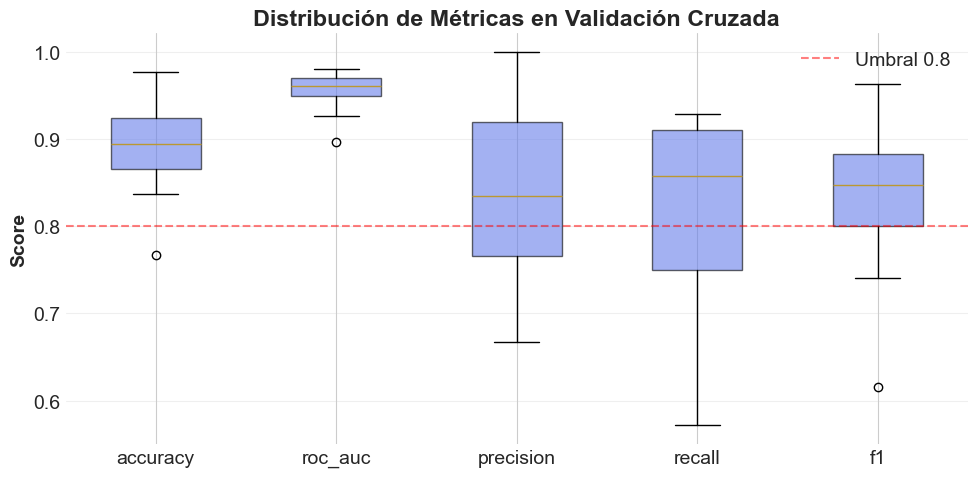

In [48]:
fig, axes = plt.subplots(figsize=(10, 5))

# Gráfica 1: Box plot de métricas
metrics_data = [cv_results[m] for m in scoring]
bp = plt.boxplot(metrics_data, labels=scoring, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#667eea')
    patch.set_alpha(0.6)

plt.ylabel('Score', fontweight='bold')
plt.title('Distribución de Métricas en Validación Cruzada', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='Umbral 0.8')
plt.legend()

plt.tight_layout()
plt.show()

---
### *Shap*
---

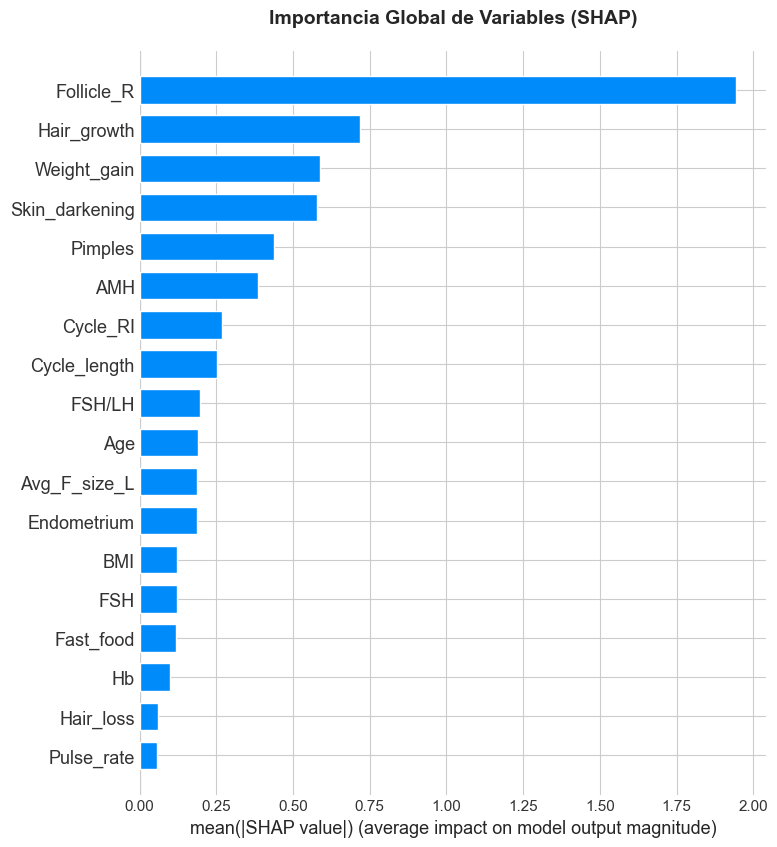

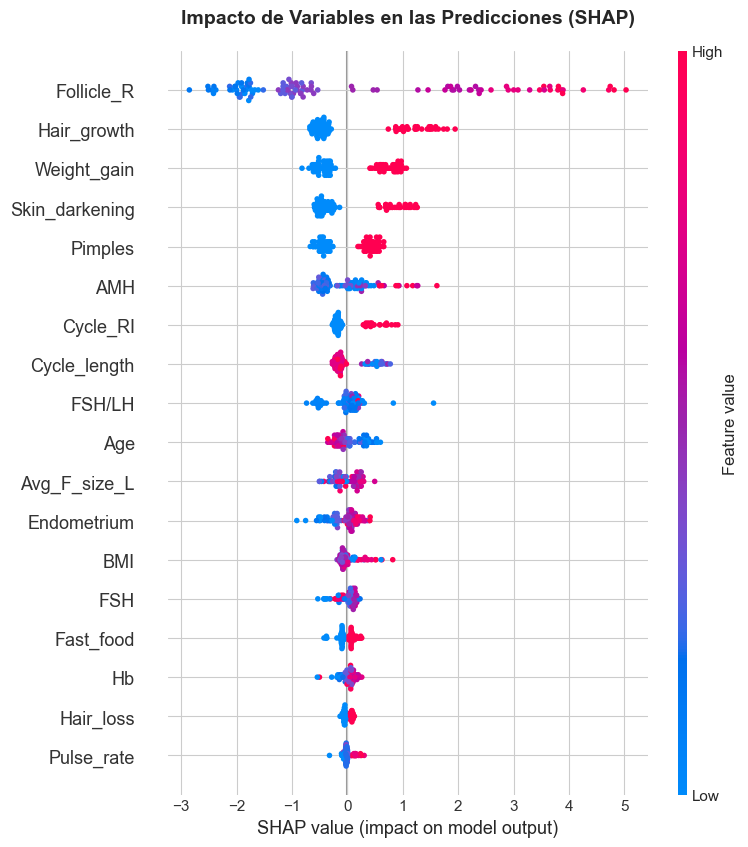

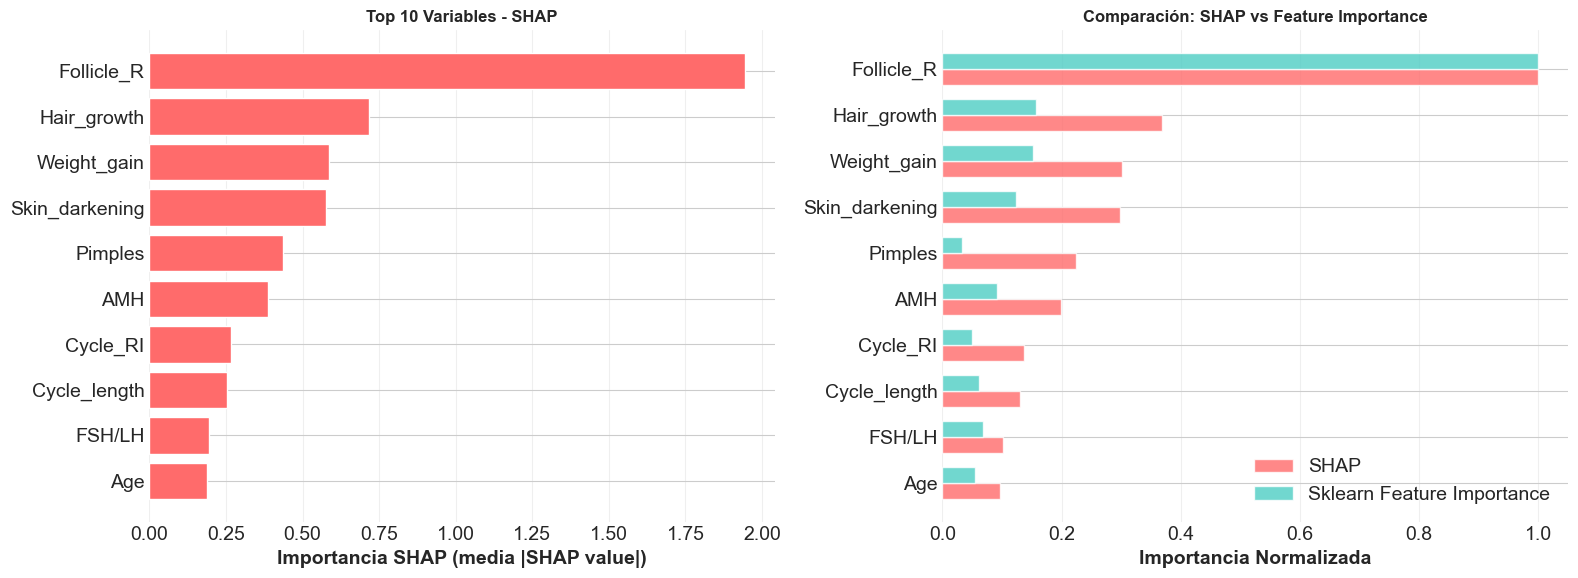


CASO 1: Paciente CORRECTAMENTE identificado con SOP
Índice: 398
Predicción: SOP | Real: SOP 


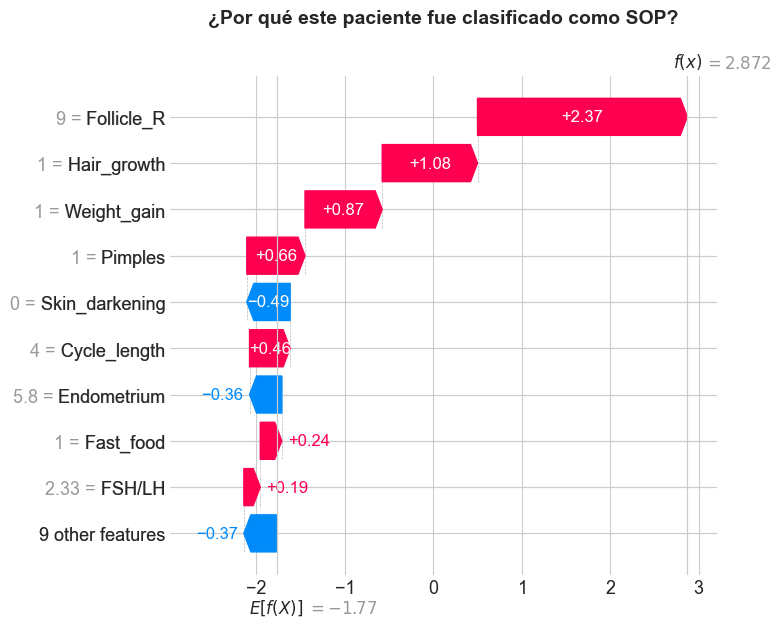


CASO 2: Paciente con SOP que NO fue detectado (Falso Negativo)
Índice: 227
Predicción: No SOP | Real: SOP


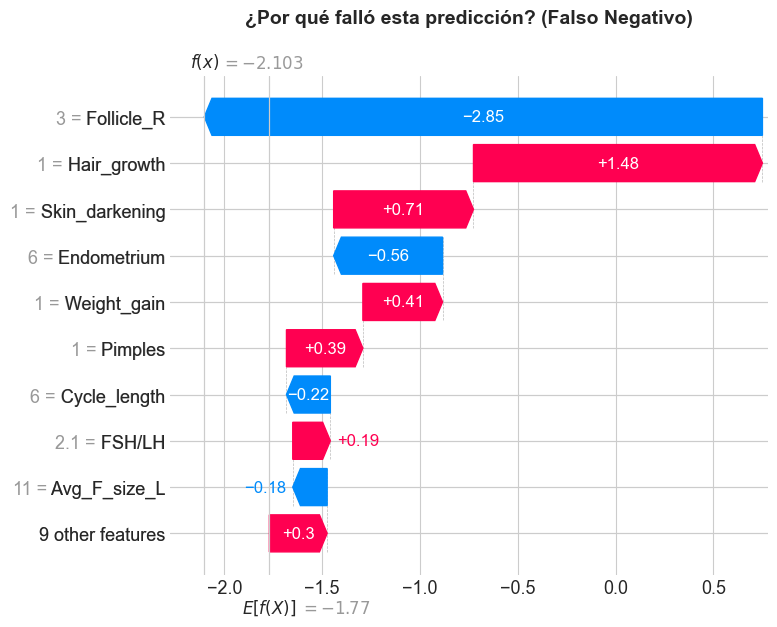


CASO 3: Falsa alarma (Falso Positivo)
Índice: 322
Predicción: SOP | Real: No SOP


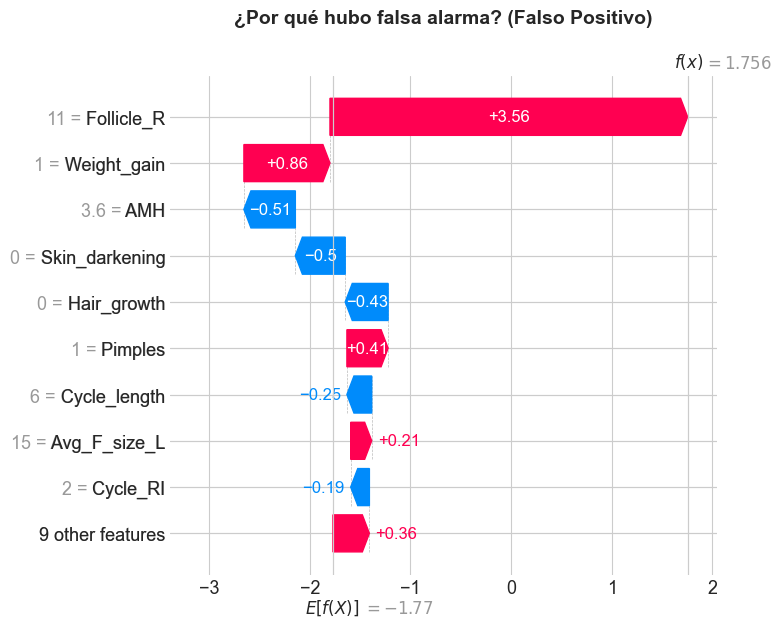

In [109]:

import shap
import matplotlib.pyplot as plt

# Crear explicador SHAP
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(X_test)
#Grafica 1
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('Importancia Global de Variables (SHAP)', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

#Grafica 2
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('Impacto de Variables en las Predicciones (SHAP)', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()



# Calcular importancia SHAP promedio
shap_importance_df = pd.DataFrame({
    'Variable': X_test.columns,
    'SHAP_Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

# Feature importance de sklearn
sklearn_importance_df = pd.DataFrame({
    'Variable': feature_cols,
    'Sklearn_Importance': modelo_final.feature_importances_
}).sort_values('Sklearn_Importance', ascending=False)

# Merge
comparison_df = shap_importance_df.merge(sklearn_importance_df, on='Variable')

# Normalizar para comparar
comparison_df['SHAP_Norm'] = comparison_df['SHAP_Importance'] / comparison_df['SHAP_Importance'].max()
comparison_df['Sklearn_Norm'] = comparison_df['Sklearn_Importance'] / comparison_df['Sklearn_Importance'].max()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 SHAP
top10_shap = shap_importance_df.head(10).sort_values('SHAP_Importance')
axes[0].barh(top10_shap['Variable'], top10_shap['SHAP_Importance'], color='#FF6B6B')
axes[0].set_xlabel('Importancia SHAP (media |SHAP value|)', fontweight='bold')
axes[0].set_title('Top 10 Variables - SHAP', fontweight='bold', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# Comparación Top 10
top10_comparison = comparison_df.head(10).sort_values('SHAP_Norm')
x = np.arange(len(top10_comparison))
width = 0.35

axes[1].barh(x - width/2, top10_comparison['SHAP_Norm'], width, 
             label='SHAP', color='#FF6B6B', alpha=0.8)
axes[1].barh(x + width/2, top10_comparison['Sklearn_Norm'], width, 
             label='Sklearn Feature Importance', color='#4ECDC4', alpha=0.8)

axes[1].set_yticks(x)
axes[1].set_yticklabels(top10_comparison['Variable'])
axes[1].set_xlabel('Importancia Normalizada', fontweight='bold')
axes[1].set_title('Comparación: SHAP vs Feature Importance', fontweight='bold', fontsize=12)
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# Encontrar casos interesantes
y_pred_gb = modelo_final.predict(X_test)

# Caso 1: Verdadero Positivo con alta confianza
tp_mask = (y_test == 1) & (y_pred_gb == 1)
if tp_mask.sum() > 0:
    tp_idx = X_test[tp_mask].index[0]
    tp_case = X_test.loc[tp_idx]
    
    print("\nCASO 1: Paciente CORRECTAMENTE identificado con SOP")
    print(f"Índice: {tp_idx}")
    print(f"Predicción: SOP | Real: SOP ")
    
    # Waterfall plot
    shap.initjs()
    tp_shap_idx = X_test.index.get_loc(tp_idx)
    
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[tp_shap_idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[tp_shap_idx].values,
            feature_names=X_test.columns.tolist()
        ),
        show=False
    )
    plt.title('¿Por qué este paciente fue clasificado como SOP?', 
              fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# Caso 2: Falso Negativo
fn_mask = (y_test == 1) & (y_pred_gb == 0)
if fn_mask.sum() > 0:
    fn_idx = X_test[fn_mask].index[0]
    fn_case = X_test.loc[fn_idx]
    
    print("\nCASO 2: Paciente con SOP que NO fue detectado (Falso Negativo)")
    print(f"Índice: {fn_idx}")
    print(f"Predicción: No SOP | Real: SOP")
    
    fn_shap_idx = X_test.index.get_loc(fn_idx)
    
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[fn_shap_idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[fn_shap_idx].values,
            feature_names=X_test.columns.tolist()
        ),
        show=False
    )
    plt.title('¿Por qué falló esta predicción? (Falso Negativo)', 
              fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("\n¡Excelente! No hay falsos negativos en el test set")

# Caso 3: Falso Positivo
fp_mask = (y_test == 0) & (y_pred_gb == 1)
if fp_mask.sum() > 0:
    fp_idx = X_test[fp_mask].index[0]
    fp_case = X_test.loc[fp_idx]
    
    print("\nCASO 3: Falsa alarma (Falso Positivo)")
    print(f"Índice: {fp_idx}")
    print(f"Predicción: SOP | Real: No SOP")
    
    fp_shap_idx = X_test.index.get_loc(fp_idx)
    
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[fp_shap_idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[fp_shap_idx].values,
            feature_names=X_test.columns.tolist()
        ),
        show=False
    )
    plt.title('¿Por qué hubo falsa alarma? (Falso Positivo)', 
              fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()


---
### *Analisis de Errores*
---

In [ ]:
# Identificar errores
y_pred_opt = modelo_final.predict(X_test)
y_prob_opt = modelo_final.predict_proba(X_test)[:, 1]

# Clasificar predicciones
df_errors = X_test.copy()
df_errors['Real'] = y_test.values
df_errors['Predicción'] = y_pred_opt
df_errors['Probabilidad'] = y_prob_opt
df_errors['Error_Tipo'] = 'Correcto'

# Identificar tipos de error
df_errors.loc[(df_errors['Real'] == 1) & (df_errors['Predicción'] == 0), 'Error_Tipo'] = 'Falso Negativo'
df_errors.loc[(df_errors['Real'] == 0) & (df_errors['Predicción'] == 1), 'Error_Tipo'] = 'Falso Positivo'

# Análisis de confianza
df_errors['Confianza'] = df_errors.apply(
    lambda x: x['Probabilidad'] if x['Predicción'] == 1 else 1 - x['Probabilidad'], 
    axis=1
)

print(f"\nDistribución de predicciones:")
print(df_errors['Error_Tipo'].value_counts())

#Analizando falsos negativos
falsos_negativos = df_errors[df_errors['Error_Tipo'] == 'Falso Negativo']
if len(falsos_negativos) > 0:
    print(f"Total: {len(falsos_negativos)}")
    print(f"Confianza promedio: {falsos_negativos['Confianza'].mean():.4f}")
    print("\nCaracterísticas promedio de casos no detectados:")
    print(falsos_negativos[feature_cols].mean().sort_values(ascending=False).head(10))
else:
    print("¡Excelente! No hay falsos negativos")


falsos_positivos = df_errors[df_errors['Error_Tipo'] == 'Falso Positivo']
if len(falsos_positivos) > 0:
    print(f"Total: {len(falsos_positivos)}")
    print(f"Confianza promedio: {falsos_positivos['Confianza'].mean():.4f}")
    print("\nCaracterísticas promedio de falsas alarmas:")
    print(falsos_positivos[feature_cols].mean().sort_values(ascending=False).head(10))




Distribución de predicciones:
Error_Tipo
Correcto          96
Falso Negativo     8
Falso Positivo     4
Name: count, dtype: int64
Total: 8
Confianza promedio: 0.7184

Características promedio de casos no detectados:
Pulse_rate      74.00000
Age             29.87500
BMI             25.45000
Avg_F_size_L    15.31250
Hb              11.23750
Endometrium      7.91875
Follicle_R       5.62500
AMH              5.27625
Cycle_length     5.00000
FSH              4.37000
dtype: float64
Total: 4
Confianza promedio: 0.6822

Características promedio de falsas alarmas:
Pulse_rate      72.500
Age             34.000
BMI             25.700
Avg_F_size_L    14.750
Hb              11.300
AMH             11.150
Endometrium      8.750
FSH              5.695
Follicle_R       4.000
Cycle_RI         3.500
dtype: float64


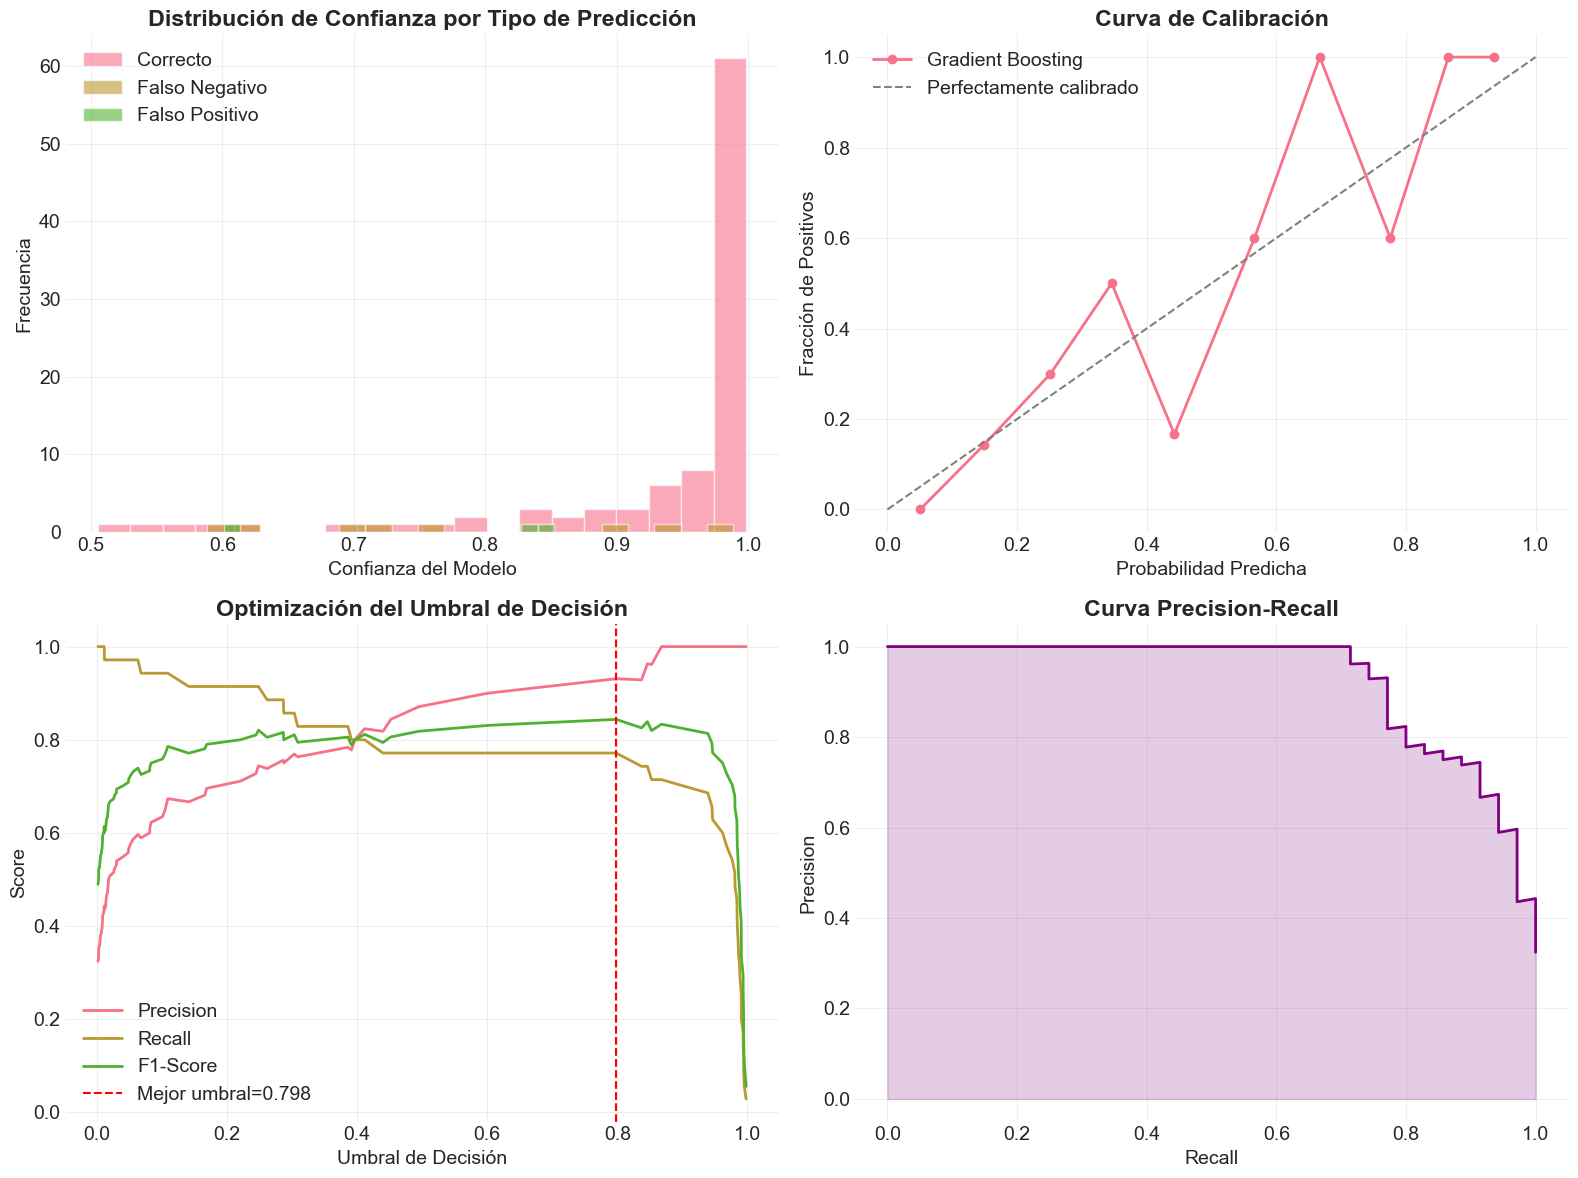

In [51]:
# Visualización de errores
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de confianza por tipo
for error_type in ['Correcto', 'Falso Negativo', 'Falso Positivo']:
    data = df_errors[df_errors['Error_Tipo'] == error_type]['Confianza']
    if len(data) > 0:
        axes[0, 0].hist(data, alpha=0.6, label=error_type, bins=20)
axes[0, 0].set_xlabel('Confianza del Modelo')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Confianza por Tipo de Predicción', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Calibración del modelo
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob_gb, n_bins=10)
axes[0, 1].plot(prob_pred, prob_true, marker='o', linewidth=2, label='Gradient Boosting')
axes[0, 1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectamente calibrado')
axes[0, 1].set_xlabel('Probabilidad Predicha')
axes[0, 1].set_ylabel('Fracción de Positivos')
axes[0, 1].set_title('Curva de Calibración', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Threshold optimization
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_opt)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]

axes[1, 0].plot(thresholds, precision[:-1], label='Precision', linewidth=2)
axes[1, 0].plot(thresholds, recall[:-1], label='Recall', linewidth=2)
axes[1, 0].plot(thresholds, f1_scores[:-1], label='F1-Score', linewidth=2)
axes[1, 0].axvline(x=best_threshold, color='red', linestyle='--', 
                   label=f'Mejor umbral={best_threshold:.3f}')
axes[1, 0].set_xlabel('Umbral de Decisión')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Optimización del Umbral de Decisión', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Precision-Recall curve
axes[1, 1].plot(recall, precision, linewidth=2, color='purple')
axes[1, 1].fill_between(recall, precision, alpha=0.2, color='purple')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
### *Guardar modelo*
---
    



In [108]:
#Guardar modelo
import joblib
from datetime import datetime

#Crear carpeta para modelos
import os
model_dir = 'modelos_pcos'
os.makedirs(model_dir, exist_ok=True)

# Información del modelo
model_info = {
    'fecha_entrenamiento': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'modelo': 'GradientBoostingClassifier',
    'accuracy': acc_opt,
    'auc_roc': auc_opt,
    'features': feature_cols,
    'umbral_optimo': best_threshold,
    'n_train': len(X_train),
    'n_test': len(X_test),
    'hiperparametros': modelo_final.get_params()
}

#Guardar modelo y metadatos
joblib.dump(modelo_final, f'{model_dir}/modelo_gb_pcos.pkl')
joblib.dump(scaler, f'{model_dir}/scaler_pcos.pkl')
joblib.dump(model_info, f'{model_dir}/model_info.pkl')

print(f"Modelo guardado en: {model_dir}/")
print(f"Accuracy: {acc_gb:.4f}")
print(f"AUC-ROC: {auc_gb:.4f}")

Modelo guardado en: modelos_pcos/
Accuracy: 0.8889
AUC-ROC: 0.9483


---
### *Learning Curve*
---

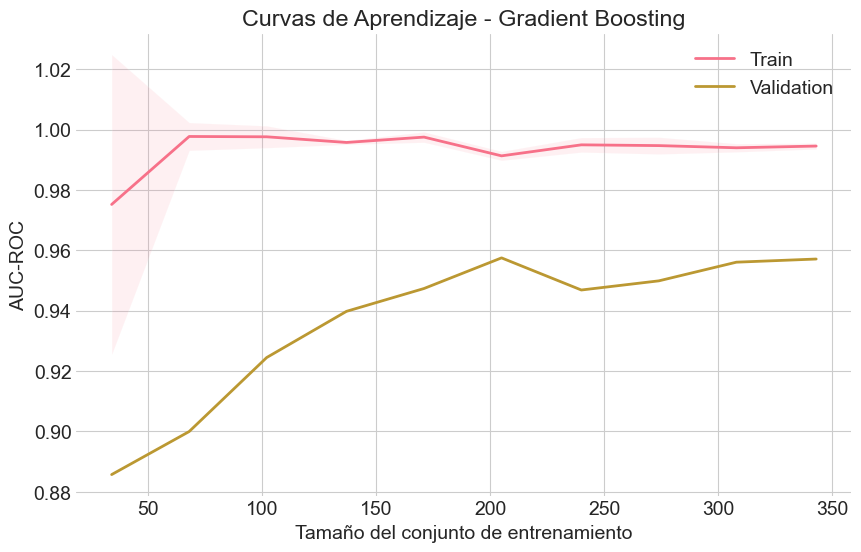

In [53]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    gb, X_train, y_train, cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train', linewidth=2)
plt.plot(train_sizes, test_scores.mean(axis=1), label='Validation', linewidth=2)
plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('AUC-ROC')
plt.title('Curvas de Aprendizaje - Gradient Boosting')
plt.legend()
plt.grid(True)
plt.show()

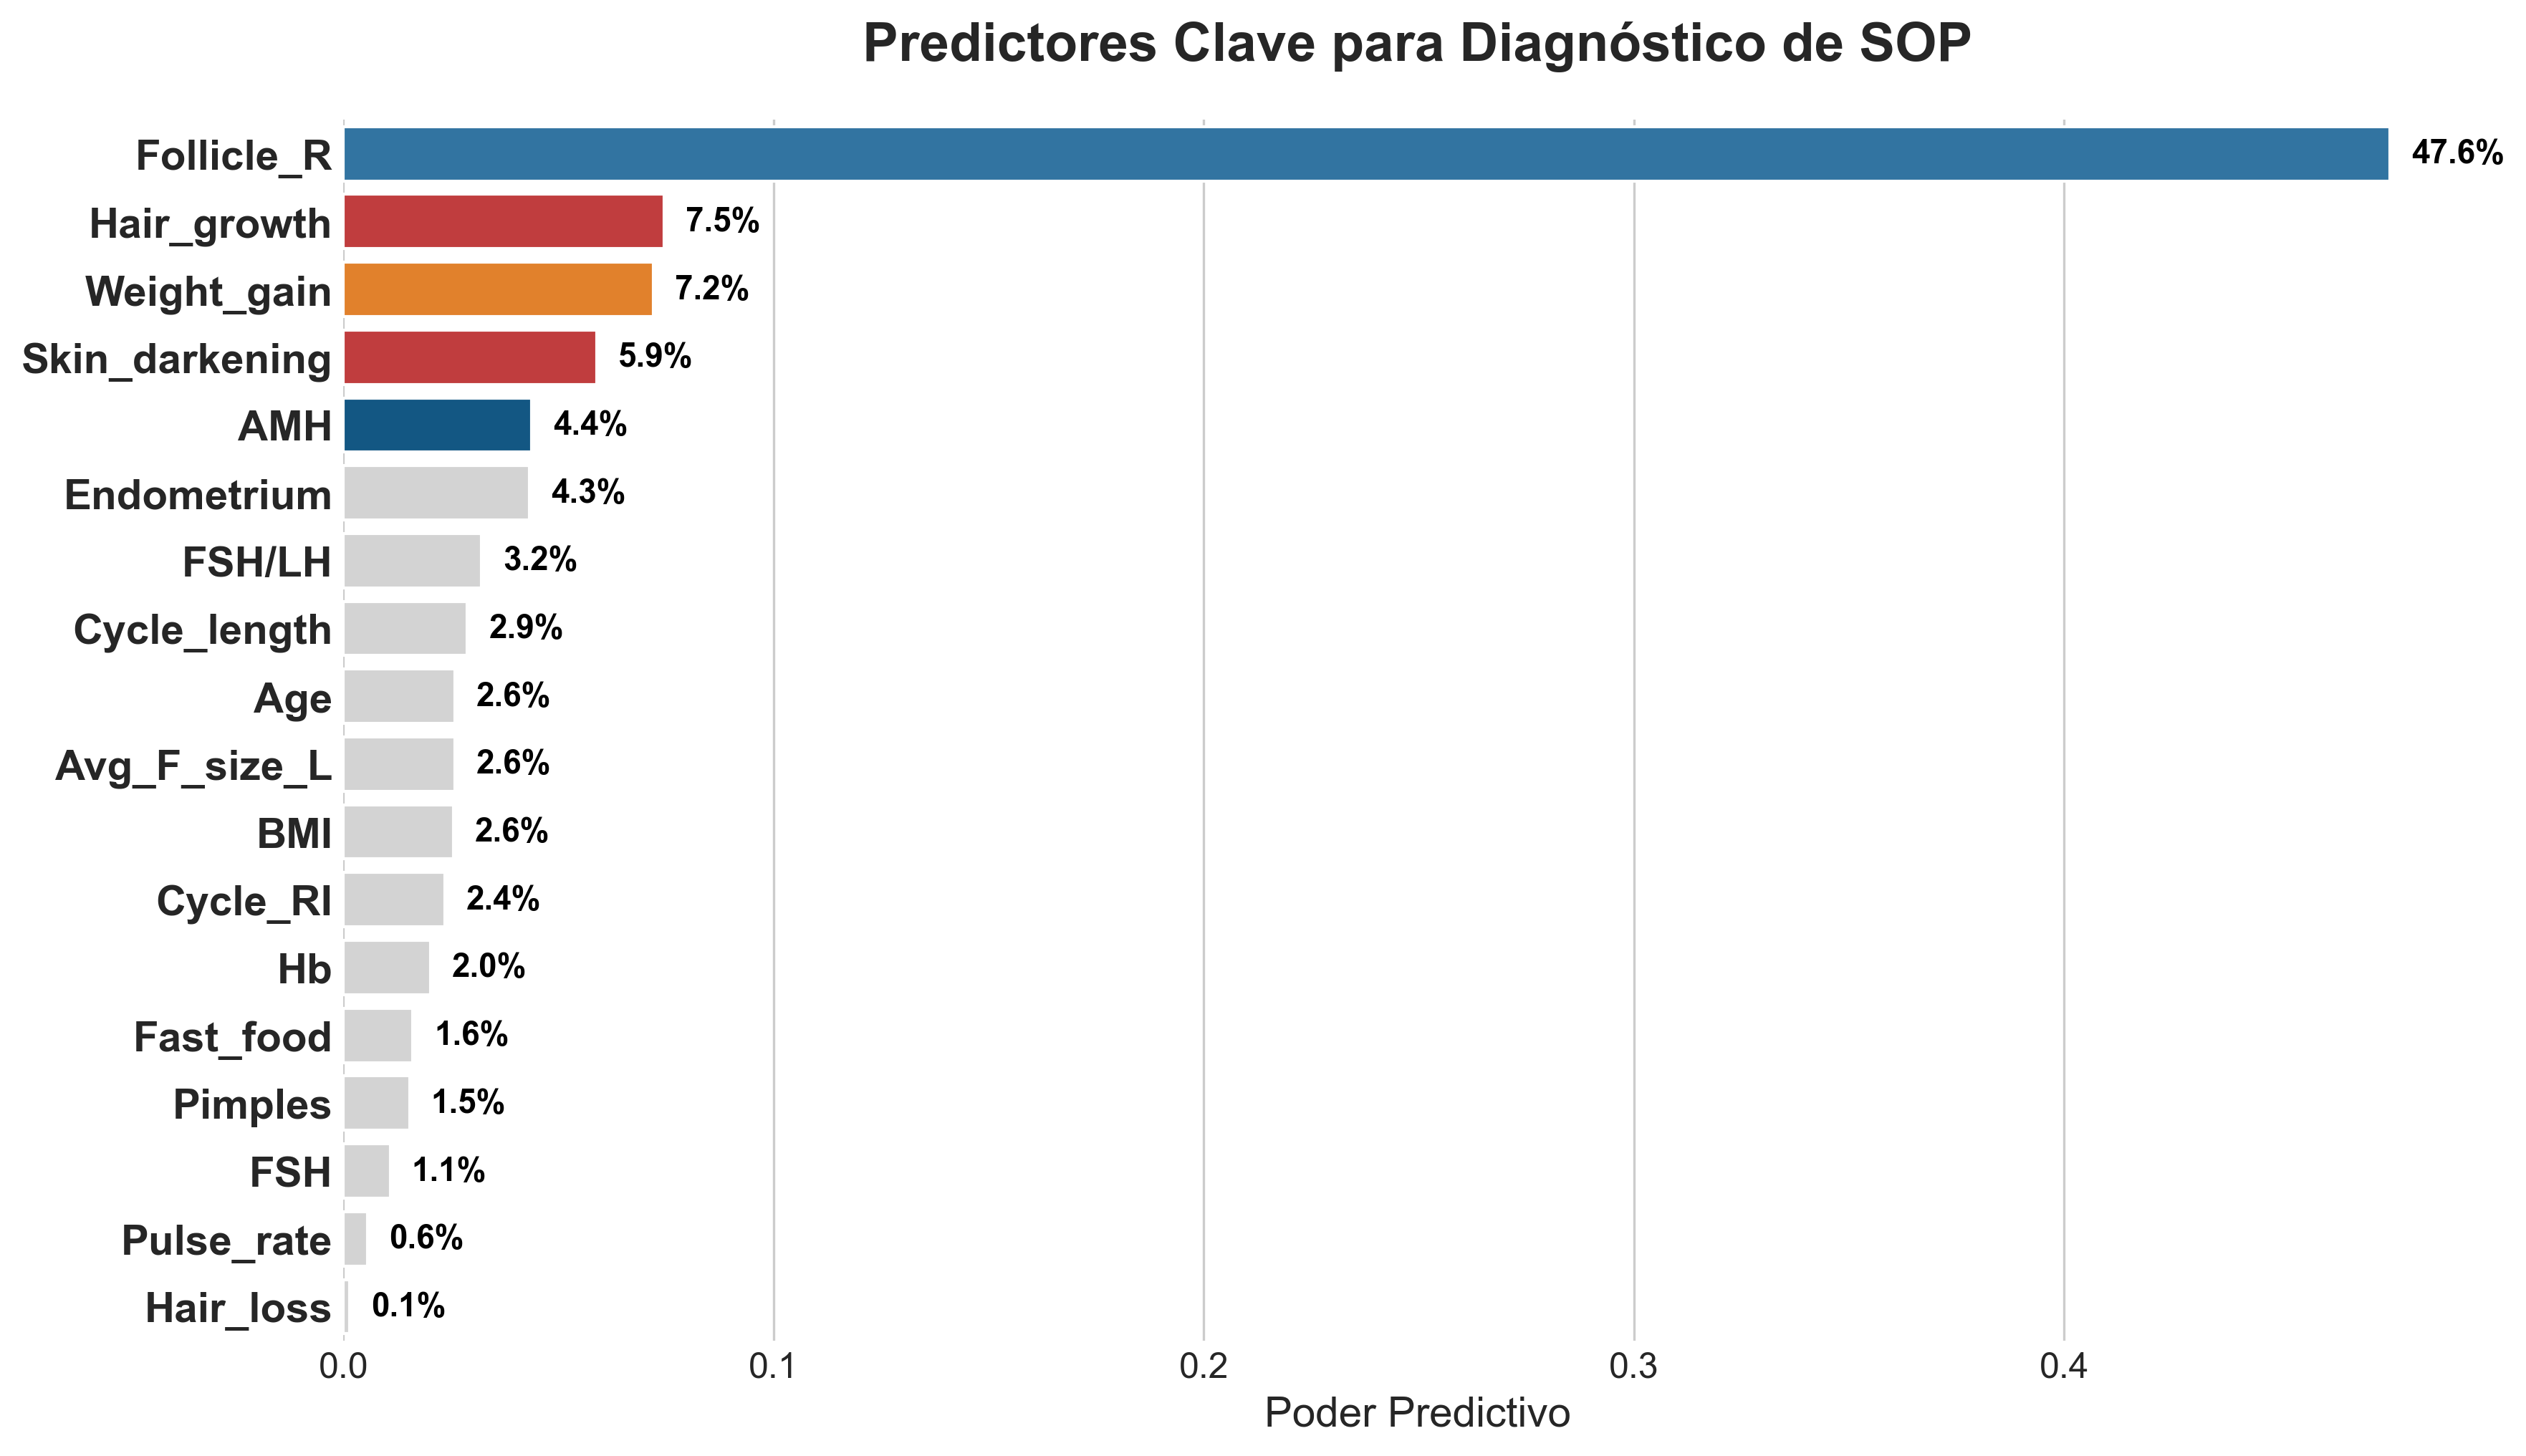

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- PASO 1: OBTENER DATOS ---
# Asumo que tu modelo entrenado se llama 'gb' y tus datos de entrenamiento 'X_train'
# Si tu modelo tiene otro nombre (ej. model_gb), cámbialo aquí abajo

feature_importance = modelo_final.feature_importances_
feature_names = X_train.columns

# Crear DataFrame y ordenar
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
df_imp = df_imp.sort_values(by='Importance', ascending=False) # Solo el Top 10

# --- PASO 2: DEFINIR COLORES ESTRATÉGICOS ---
# Esto ayuda a tu narrativa visual
colores = []
for feature in df_imp['Feature']:
    if 'Follicle' in feature:
        colores.append('#1f77b4')  # Azul (Clínico / Estándar)
    elif 'AMH' in feature:
        colores.append('#005b96')  # Azul Oscuro (Sangre / Confirmación)
    elif 'Skin' in feature or 'darkening' in feature:
        colores.append('#d62728')  # ROJO (¡Tu Hallazgo Visual!)
    elif 'Weight' in feature:
        colores.append('#ff7f0e')  # Naranja (Metabólico)
    elif 'Hair' in feature and 'growth' in feature:
        colores.append('#d62728')
    else:
        colores.append('lightgray') # Gris (Otros)

# --- PASO 3: GRAFICAR ---
plt.figure(figsize=(12, 7), dpi=300) # Alta resolución
sns.set_style("whitegrid")

# Crear gráfico de barras
ax = sns.barplot(x='Importance', y='Feature', data=df_imp, palette=colores)

# --- PASO 4: MAQUILLAJE PARA PRESENTACIÓN ---
# Títulos grandes y claros
plt.title('Predictores Clave para Diagnóstico de SOP', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Poder Predictivo', fontsize=14)
plt.ylabel('') # Quitamos la etiqueta "Feature" para limpiar
plt.xticks(fontsize=12)
plt.yticks(fontsize=14, fontweight='bold') # Nombres de variables en negrita

# Poner el valor numérico al final de cada barra
for i, v in enumerate(df_imp['Importance']):
    ax.text(v + 0.005, i, f'{v:.1%}', color='black', va='center', fontweight='bold', fontsize=11)

# Eliminar bordes feos
sns.despine(left=True, bottom=True)

# Guardar imagen transparente para poner sobre cualquier fondo en Canva
plt.tight_layout()
plt.savefig('top_features_SOP.png', transparent=True)
plt.show()